In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define paths
path_potential = r'c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\1_Potential_Models'
path_ln = r'c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm'

# Models to include from 1_Potential_Models (No LN)
# We check if these strings are in the folder name
models_no_ln = [
    'baseline_algo',
    'tcn_model_fine_tune_mb_seqOut',
    'tcn_model_fine_tune_mb_pool',
    'tcn_model_mb_precompute_pool', 
    'tcn_model_mb_precompute_pool_adam'
]

sources = [
    {
        'path': path_potential,
        'filter': lambda f: any(m in f for m in models_no_ln),
        'suffix': '' 
    },
    {
        'path': path_ln,
        'filter': lambda f: True, # Load all from LN folder
        'suffix': ' + LN'
    }
]
datasets = ['Reddit', 'Twitter']

def get_model_info(folder_name, suffix=''):
    """
    Extracts Model Name, Group, and Optimizer from the folder name.
    """
    # Determine Optimizer
    is_adam = 'adam' in folder_name.lower()
    optimizer = 'Adam' if is_adam else 'SGD'
    
    # Determine Model Name and Group
    if 'baseline_algo' in folder_name:
        name = 'Baseline (AL-BTCN)'
        group = 'Baseline'
    else:
        name = 'MentalBERT '
        if 'pool' in folder_name:
            name += 'Pool'
        elif 'seqOut' in folder_name:
            name += 'Seq'
        else:
            name += 'Unknown'
            
        group = 'Fine-Tuning' if 'fine_tune' in folder_name else 'Precomputed'
        name = f"{name} ({group})"
    
    # Append Optimizer only if Adam
    if is_adam:
        name += " - Adam"
        
    # Append Suffix (e.g., + LN)
    name += suffix
    
    return name, group, optimizer

all_data = []

for source in sources:
    base_path = source['path']
    filter_func = source['filter']
    suffix = source['suffix']
    
    for dataset in datasets:
        dataset_path = os.path.join(base_path, dataset)
        if not os.path.exists(dataset_path):
            print(f"Dataset path not found: {dataset_path}")
            continue
            
        # List all folders
        folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
        print(folders)
        
        for folder in folders:
            # Filter for 10S folders (10 seeds)
            if not folder.startswith('10S'):
                continue
                
            # Apply source-specific filter
            if not filter_func(folder):
                continue
                
            # Construct file path to the all_folds excel file
            file_path = os.path.join(dataset_path, folder, f"{folder}_all_folds.xlsx")
            
            if os.path.exists(file_path):
                print(f"Processing {file_path}...")
                try:
                    # Read all sheets (each sheet is a seed)
                    sheets = pd.read_excel(file_path, sheet_name=None)
                    
                    # Concatenate all sheets
                    df = pd.concat(sheets.values(), ignore_index=True)
                    
                    # Get metadata
                    model_name, model_group, optimizer = get_model_info(folder, suffix)
                    
                    df['Model Name'] = model_name
                    df['Model Group'] = model_group
                    df['Optimizer'] = optimizer
                    df['Dataset'] = dataset
                    df['Source Folder'] = folder
                    
                    all_data.append(df)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
            else:
                print(f"File not found: {file_path}")

if all_data:
    full_df = pd.concat(all_data, ignore_index=True)
    print("Data loaded successfully.")
    print(full_df.head())
    print(full_df.groupby(['Dataset', 'Model Name', 'Optimizer']).size())
else:
    print("No data loaded.")

['10SR_baseline_algo', '10SR_tcn_model_fine_tune_mb_pool', '10SR_tcn_model_fine_tune_mb_seqOut', '10SR_tcn_model_mb_precompute_pool', '10SR_tcn_model_mb_precompute_pool_adam', '10SR_tcn_model_mb_precompute_seqOut_adam', 'F5SR_tcn_model_fine_tune_mb_pool', 'F5SR_tcn_model_fine_tune_mb_seqOut', 'L5SR_tcn_model_fine_tune_mb_pool', 'L5SR_tcn_model_fine_tune_mb_seqOut']
Processing c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\1_Potential_Models\Reddit\10SR_baseline_algo\10SR_baseline_algo_all_folds.xlsx...
Processing c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\1_Potential_Models\Reddit\10SR_tcn_model_fine_tune_mb_pool\10SR_tcn_model_fine_tune_mb_pool_all_folds.xlsx...
Processing c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\1_Potential_Models\Reddit\10SR_tcn_model_fine_tune_mb_seqOut\10SR_tcn_model_fine_tune_mb_seqOut_all_folds.xlsx...
Processing c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\1_Potential_Models\Reddit\10SR_tcn_model_mb_precompute_pool\10SR_t

In [2]:
# Define Plotting Functions

def plot_combined_barchart(df, metric, order=None):
    """
    Plots a combined bar chart for both datasets (Side-by-Side).
    """
    if df.empty: return

    # Determine if higher is better
    higher_is_better = 'Time' not in metric and 'Memory' not in metric and 'Epochs' not in metric
    
    # Metrics to exclude from group-wise bolding
    exclude_from_group_bolding = ['Training Time (s)', 'Max GPU Memory (MB)', 'Avg GPU Memory (MB)', 'Epochs Run', 'Avg Time/Epoch (s)']
    use_group_bolding = metric not in exclude_from_group_bolding

    g = sns.catplot(
        data=df,
        kind="bar",
        x="Model Name",
        y=metric,
        col="Dataset",
        col_order=['Twitter', 'Reddit'],
        height=6,
        aspect=1.5,
        order=order,
        errorbar='sd',
        capsize=.1,
        sharey=False # Allow different scales for different datasets
    )
    
    g.fig.suptitle(f'{metric} Comparison (Bar Chart)', y=1.05, fontsize=16)
    g.set_xticklabels(rotation=45, ha='right')
    g.set_axis_labels("Model", metric)
    
    col_order = ['Twitter', 'Reddit']
    
    # Annotate
    for ax, dataset_name in zip(g.axes.flat, col_order):
        dataset_df = df[df['Dataset'] == dataset_name]
        if dataset_df.empty: continue
        
        best_models = []
        
        if use_group_bolding:
            # Find best in 'Precomputed' and 'Fine-Tuning' groups
            if 'Model Group' in dataset_df.columns:
                for group in ['Precomputed', 'Fine-Tuning']:
                    group_df = dataset_df[dataset_df['Model Group'] == group]
                    if group_df.empty: continue
                    
                    means = group_df.groupby('Model Name')[metric].mean()
                    if means.empty: continue
                    
                    if higher_is_better:
                        best_model = means.idxmax()
                    else:
                        best_model = means.idxmin()
                    best_models.append(best_model)
            else:
                 # Fallback if Model Group is missing
                 means = dataset_df.groupby('Model Name')[metric].mean()
                 if not means.empty:
                    if higher_is_better:
                        best_models.append(means.idxmax())
                    else:
                        best_models.append(means.idxmin())
        else:
            # Original logic: global best
            means = dataset_df.groupby('Model Name')[metric].mean()
            if not means.empty:
                if higher_is_better:
                    best_models.append(means.idxmax())
                else:
                    best_models.append(means.idxmin())
        
        # Set Y-Limits
        y_min = dataset_df[metric].min()
        y_max = dataset_df[metric].max()
        y_range = y_max - y_min
        
        lower_ylim = y_min - y_range * 0.2
        if not higher_is_better and 'Accuracy' not in metric and 'F1' not in metric:
             lower_ylim = max(0, lower_ylim)
        if 'Accuracy' in metric or 'F1' in metric:
             lower_ylim = max(0, y_min - 0.05)

        upper_ylim = y_max + y_range * 0.2
        ax.set_ylim(lower_ylim, upper_ylim)

        # Add text and Color
        # Get patches
        patches = ax.patches
        
        if order:
            x_models = order
        else:
            x_models = sorted(dataset_df['Model Name'].unique())
            
        for i, patch in enumerate(patches):
            if i >= len(x_models):
                continue
                
            model_name = x_models[i]
            
            subset = dataset_df[dataset_df['Model Name'] == model_name]
            
            if not subset.empty:
                # Determine Color
                model_group = subset['Model Group'].iloc[0] if 'Model Group' in subset.columns else 'Unknown'
                
                color = '#7f7f7f' # Default grey (Baseline)
                if dataset_name == 'Twitter':
                    if model_group == 'Fine-Tuning': color = '#1f77b4' # Blue
                    elif model_group == 'Precomputed': color = '#aec7e8' # Light Blue
                elif dataset_name == 'Reddit':
                    if model_group == 'Fine-Tuning': color = '#d62728' # Red
                    elif model_group == 'Precomputed': color = '#ff9896' # Light Red
                
                patch.set_facecolor(color)

                mean_val = subset[metric].mean()
                std_val = subset[metric].std()
                
                x = patch.get_x() + patch.get_width() / 2
                y = patch.get_height() # This is the mean value
                
                text = f"{mean_val:.4f}\n±{std_val:.4f}"
                
                is_best = (model_name in best_models)
                font_weight = 'bold' if is_best else 'normal'
                
                # Position text above the error bar (approx)
                text_y = mean_val + std_val + (upper_ylim - lower_ylim)*0.02
                
                ax.text(
                    x, 
                    text_y, 
                    text, 
                    ha='center', 
                    va='bottom', 
                    fontsize=8, 
                    color='black',
                    fontweight=font_weight
                )
                
                if is_best:
                    for label in ax.get_xticklabels():
                        if label.get_text() == model_name:
                            label.set_fontweight('bold')

    plt.show()

def plot_combined_boxplot(df, metric, order=None):
    """
    Plots a combined box plot for both datasets.
    """
    if df.empty: return

    g = sns.catplot(
        data=df, 
        kind="box",
        x="Model Name", 
        y=metric, 
        col="Dataset",
        col_order=['Twitter', 'Reddit'],
        sharey=False,
        order=order,
        height=6,
        aspect=2
    )
    g.fig.suptitle(f'{metric} Distribution (Box Plot)', y=1.05, fontsize=16)
    g.set_xticklabels(rotation=45, ha='right')
    g.set_axis_labels("Model", metric)
    
    col_order = ['Twitter', 'Reddit']
    
    # Apply colors and add points
    for ax, dataset_name in zip(g.axes.flat, col_order):
        dataset_df = df[df['Dataset'] == dataset_name]
        if dataset_df.empty: continue
        
        # Add points
        sns.stripplot(
            data=dataset_df,
            x="Model Name",
            y=metric,
            order=order,
            color='black',
            alpha=0.5,
            jitter=True,
            ax=ax
        )
        
        # Get x-axis labels to ensure correct mapping
        x_models = [label.get_text() for label in ax.get_xticklabels()]
        
        # In seaborn boxplot, the boxes are in ax.artists or ax.patches depending on version
        boxes = ax.artists if ax.artists else ax.patches
        
        for i, box in enumerate(boxes):
            if i >= len(x_models):
                continue
                
            model_name = x_models[i]
            subset = dataset_df[dataset_df['Model Name'] == model_name]
            
            if not subset.empty:
                # Determine Color
                model_group = subset['Model Group'].iloc[0] if 'Model Group' in subset.columns else 'Unknown'
                
                color = '#7f7f7f' # Default grey (Baseline)
                if dataset_name == 'Twitter':
                    if model_group == 'Fine-Tuning': color = '#1f77b4' # Blue
                    elif model_group == 'Precomputed': color = '#aec7e8' # Light Blue
                elif dataset_name == 'Reddit':
                    if model_group == 'Fine-Tuning': color = '#d62728' # Red
                    elif model_group == 'Precomputed': color = '#ff9896' # Light Red
                
                box.set_facecolor(color)
    
    plt.show()

=== Accuracy ===


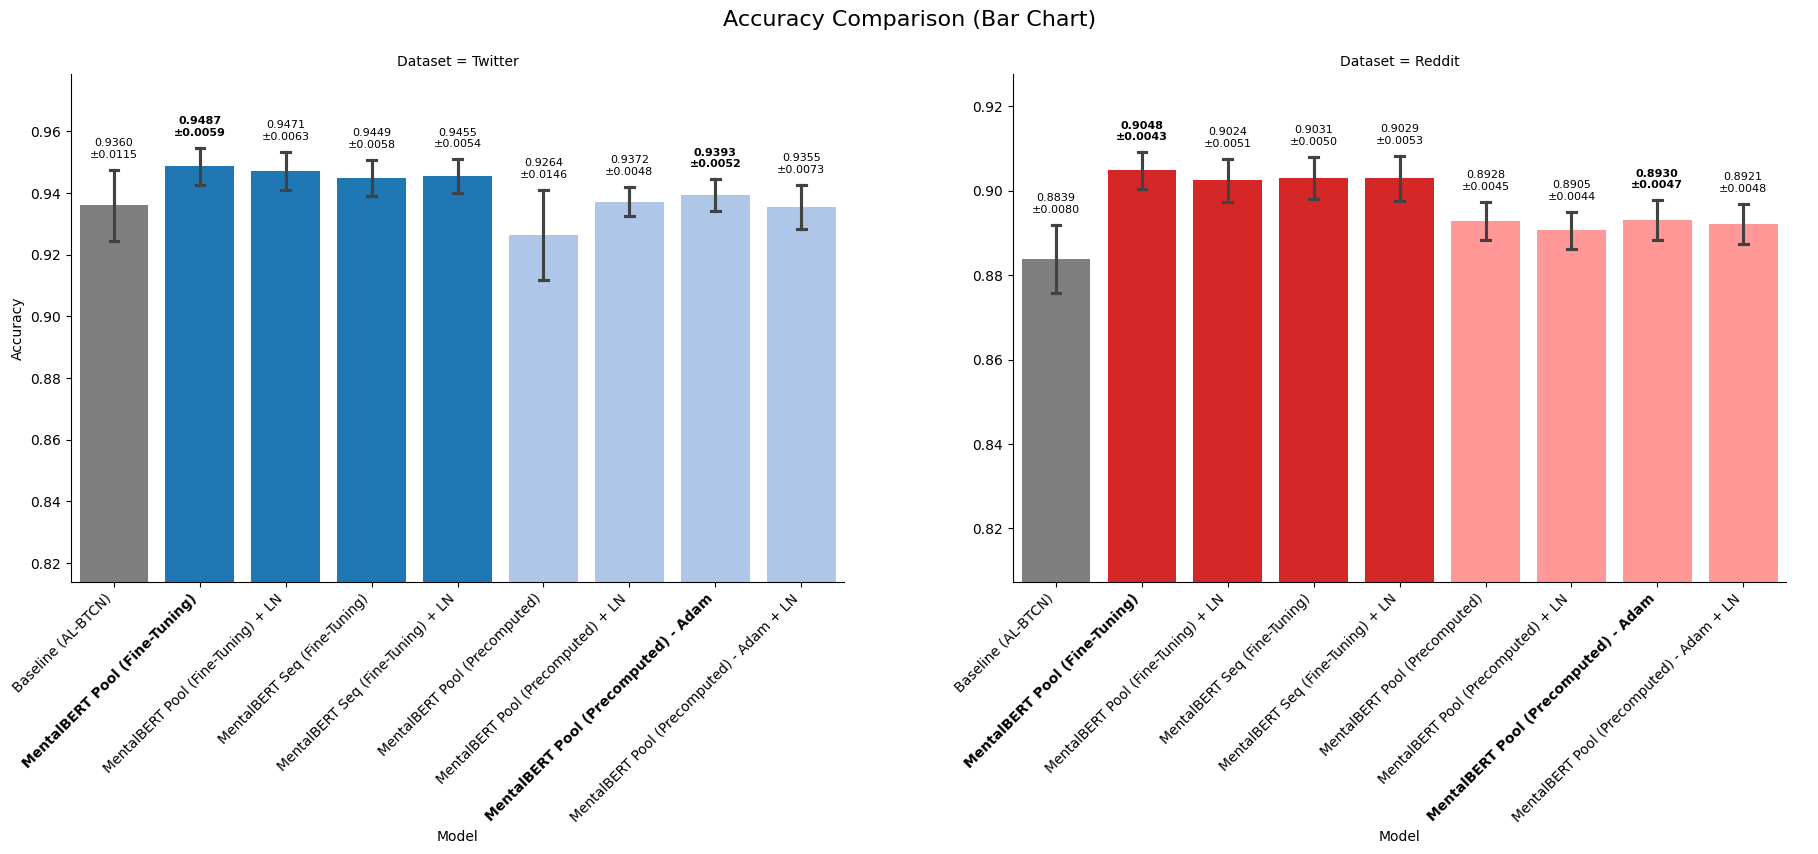

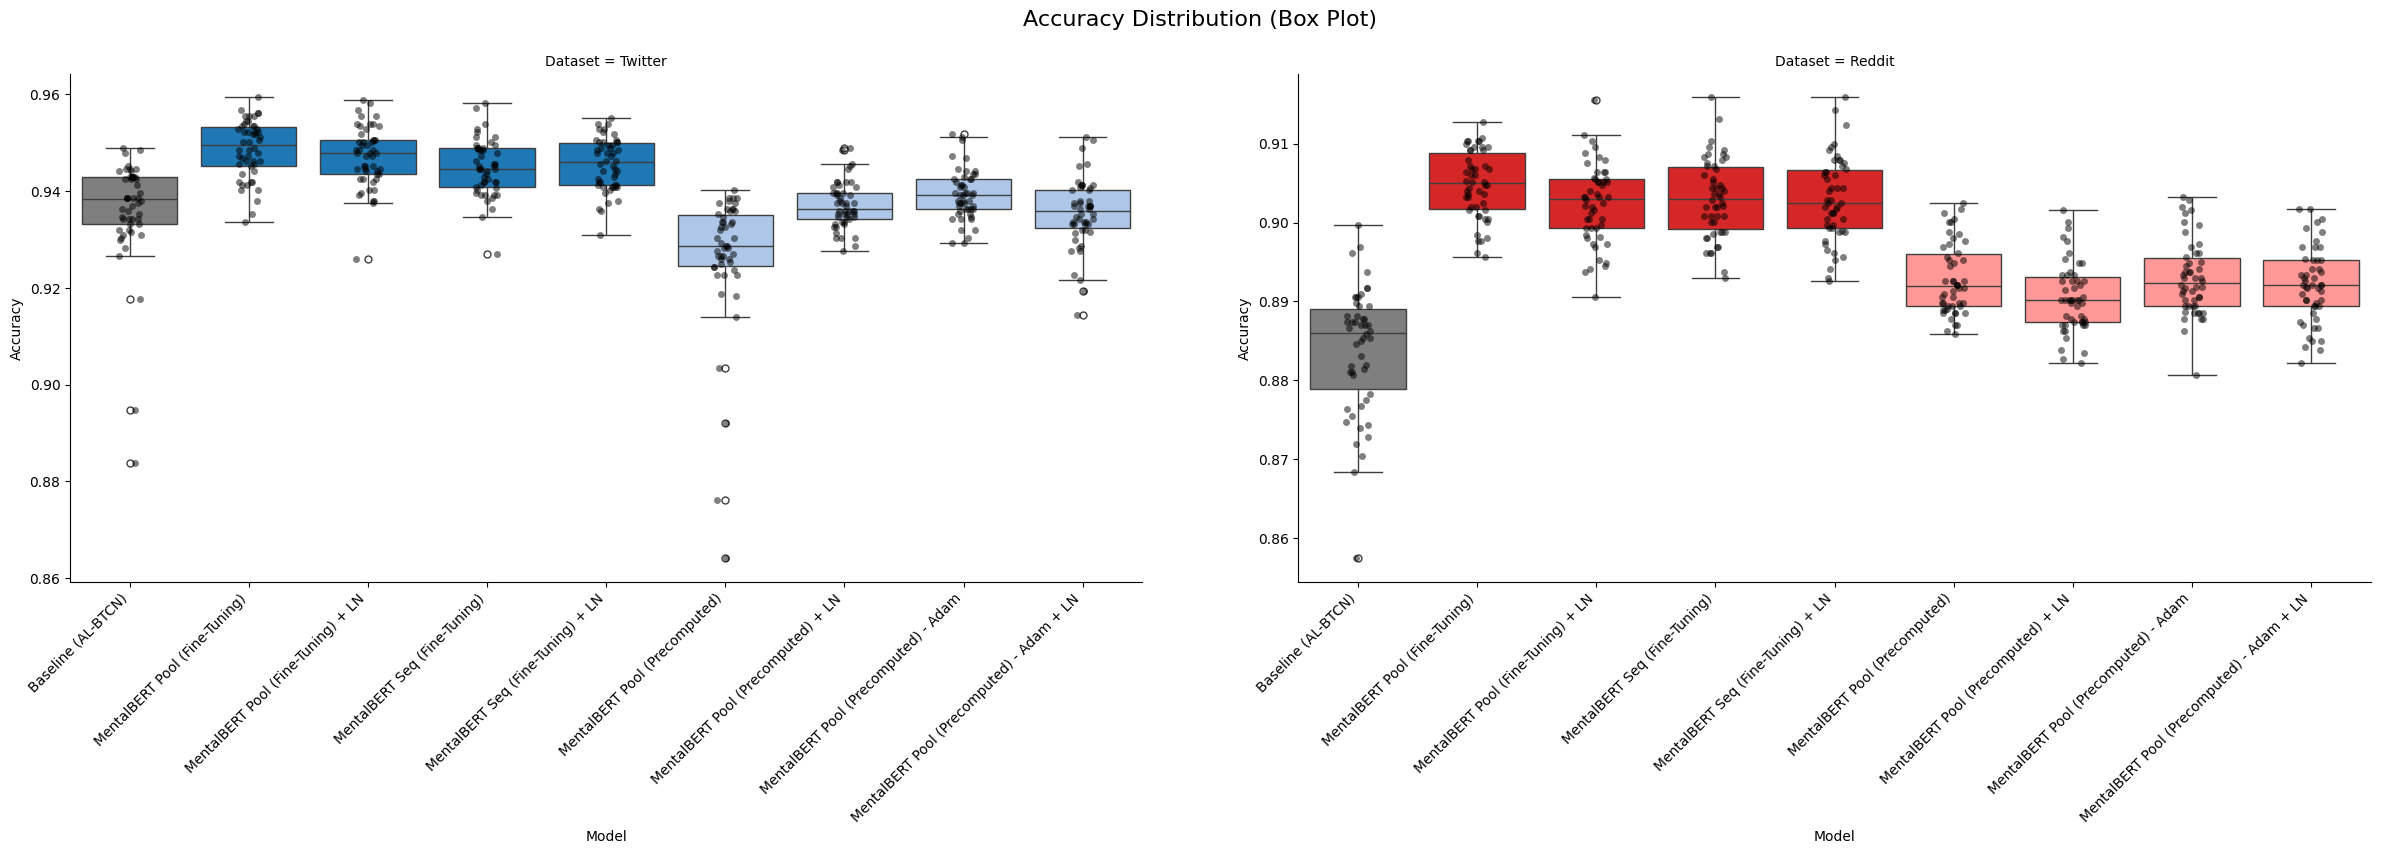

=== Precision ===


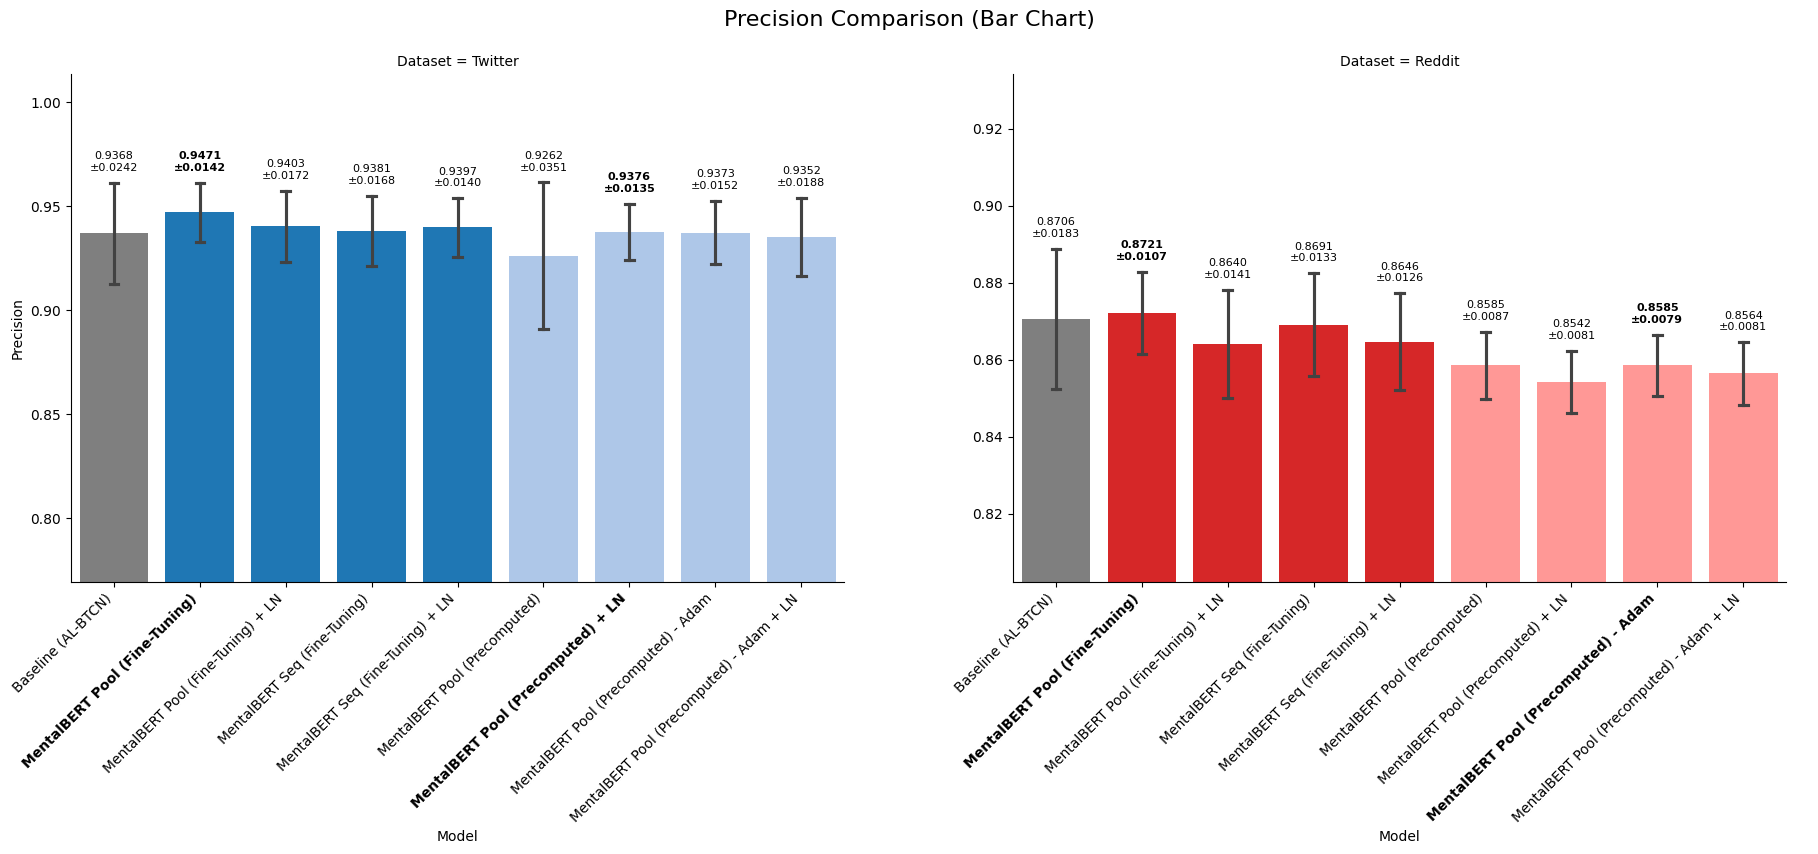

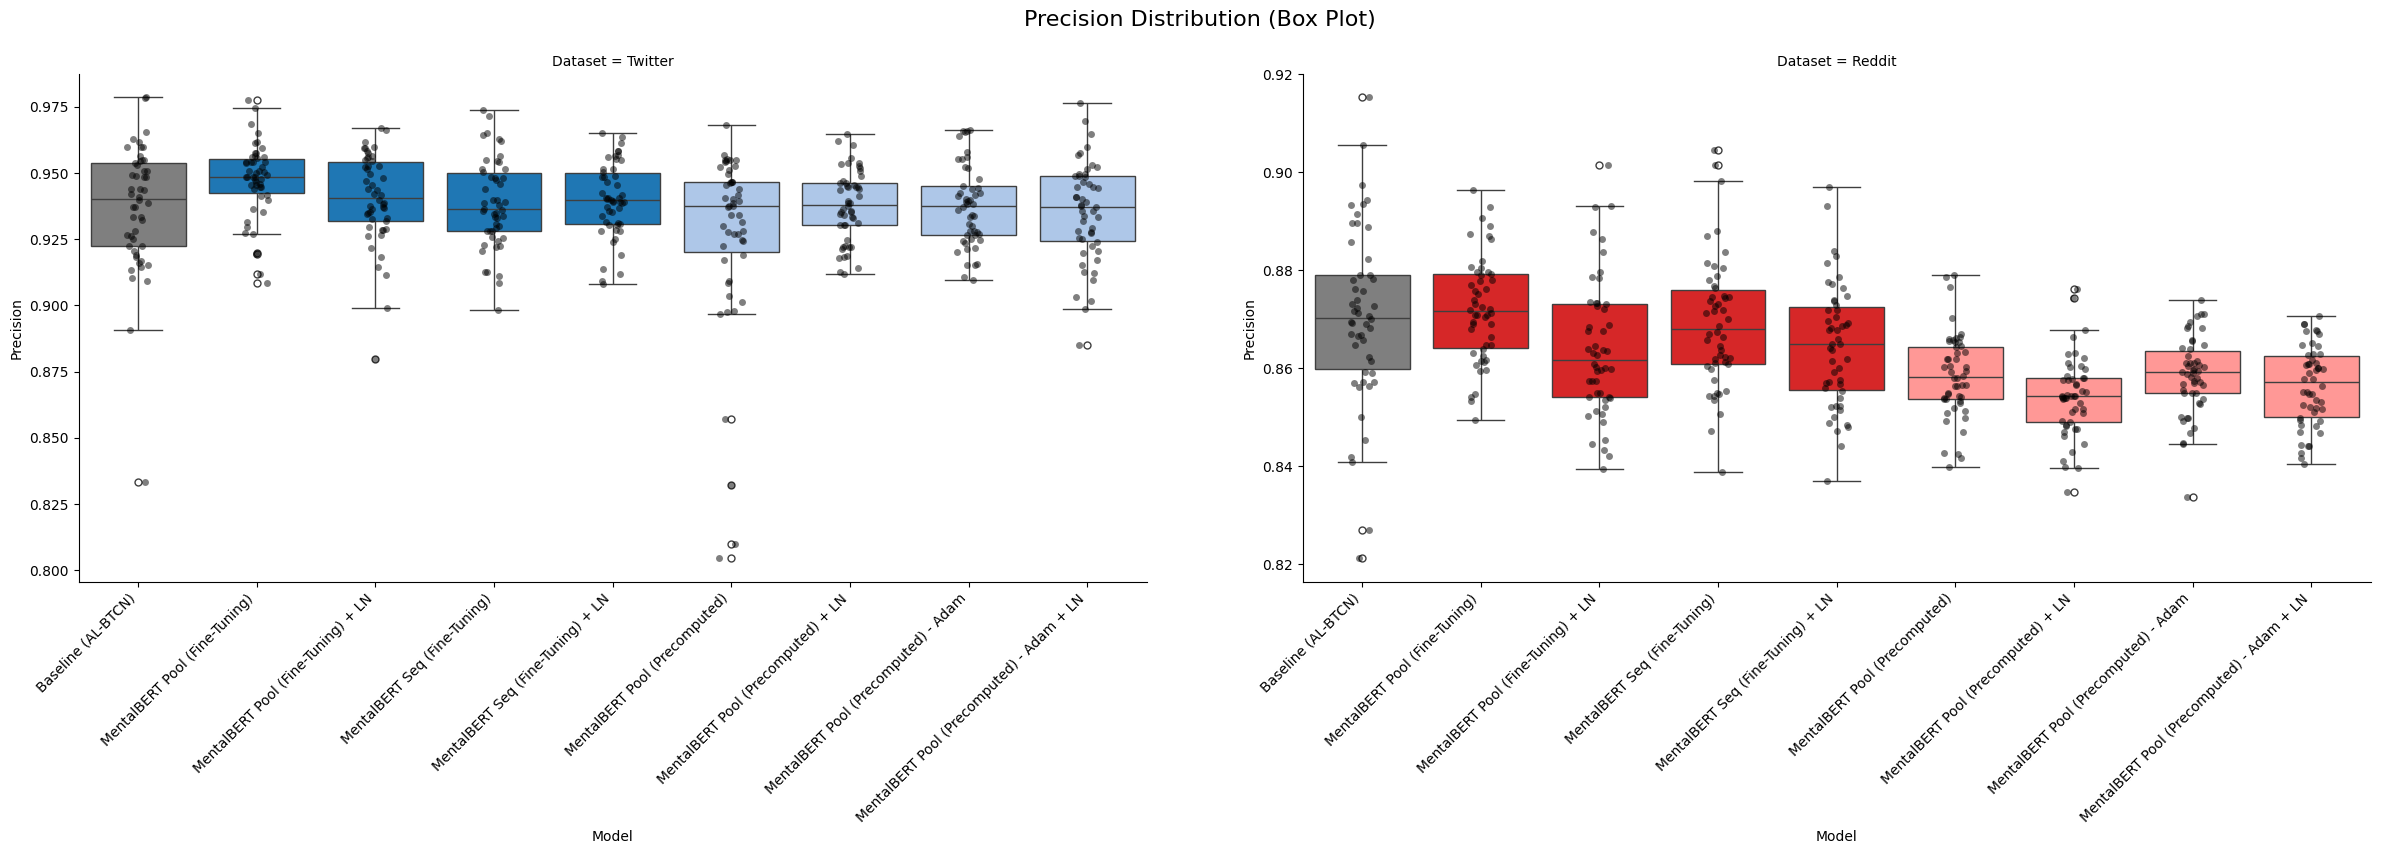

=== Recall ===


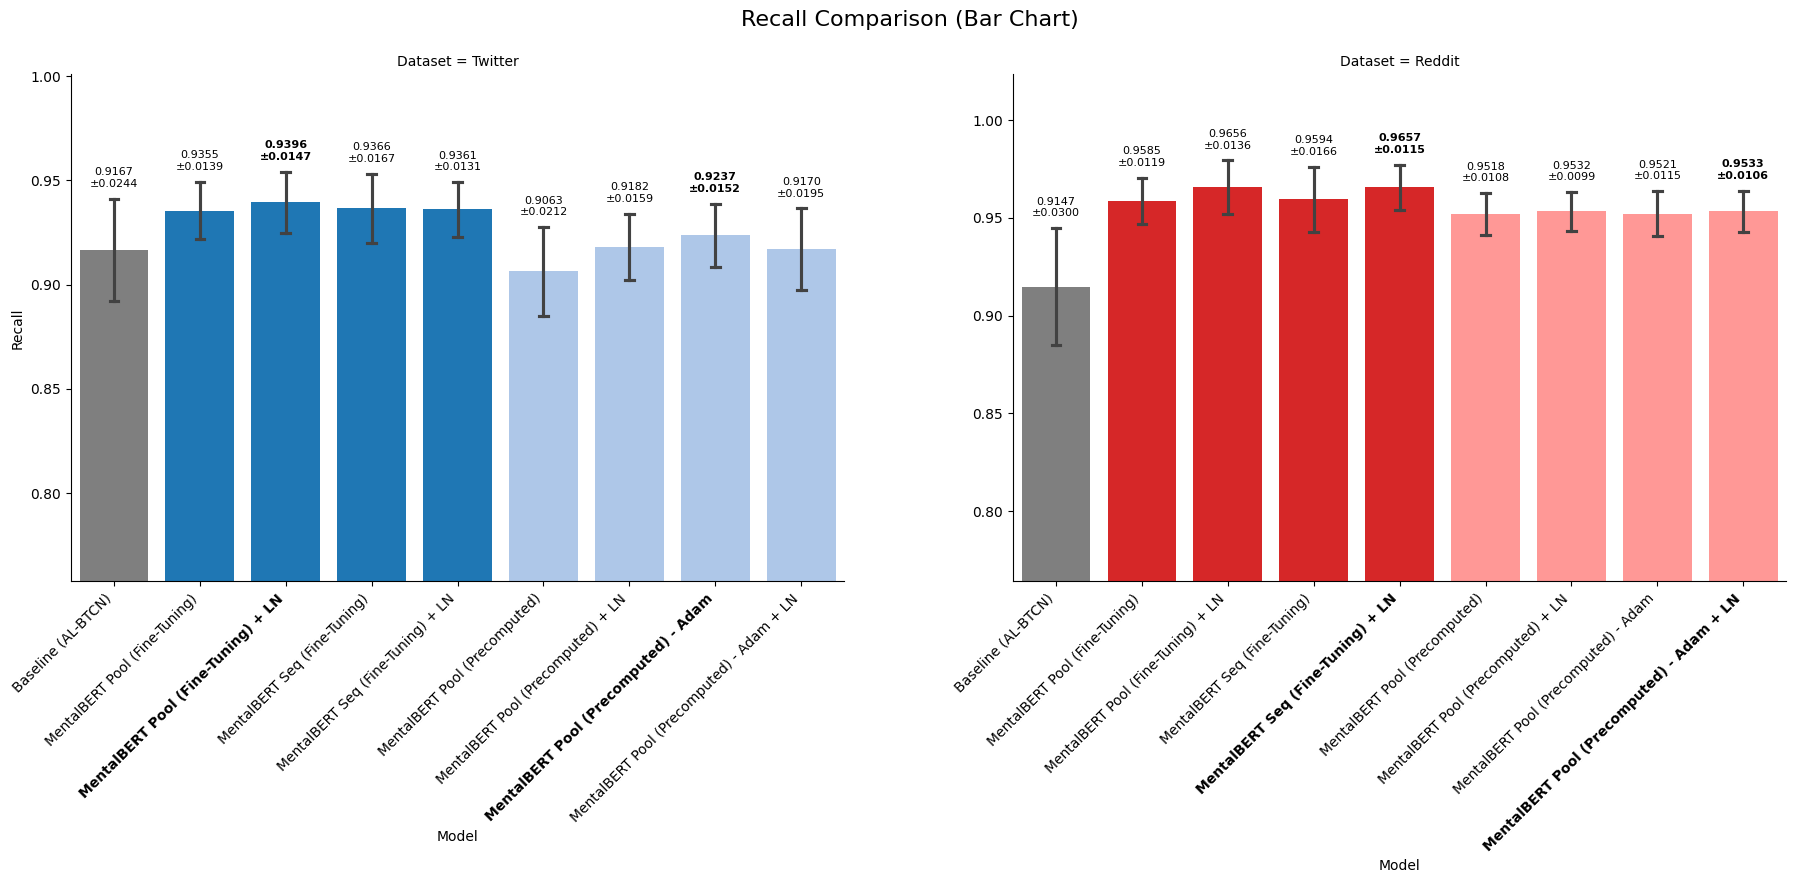

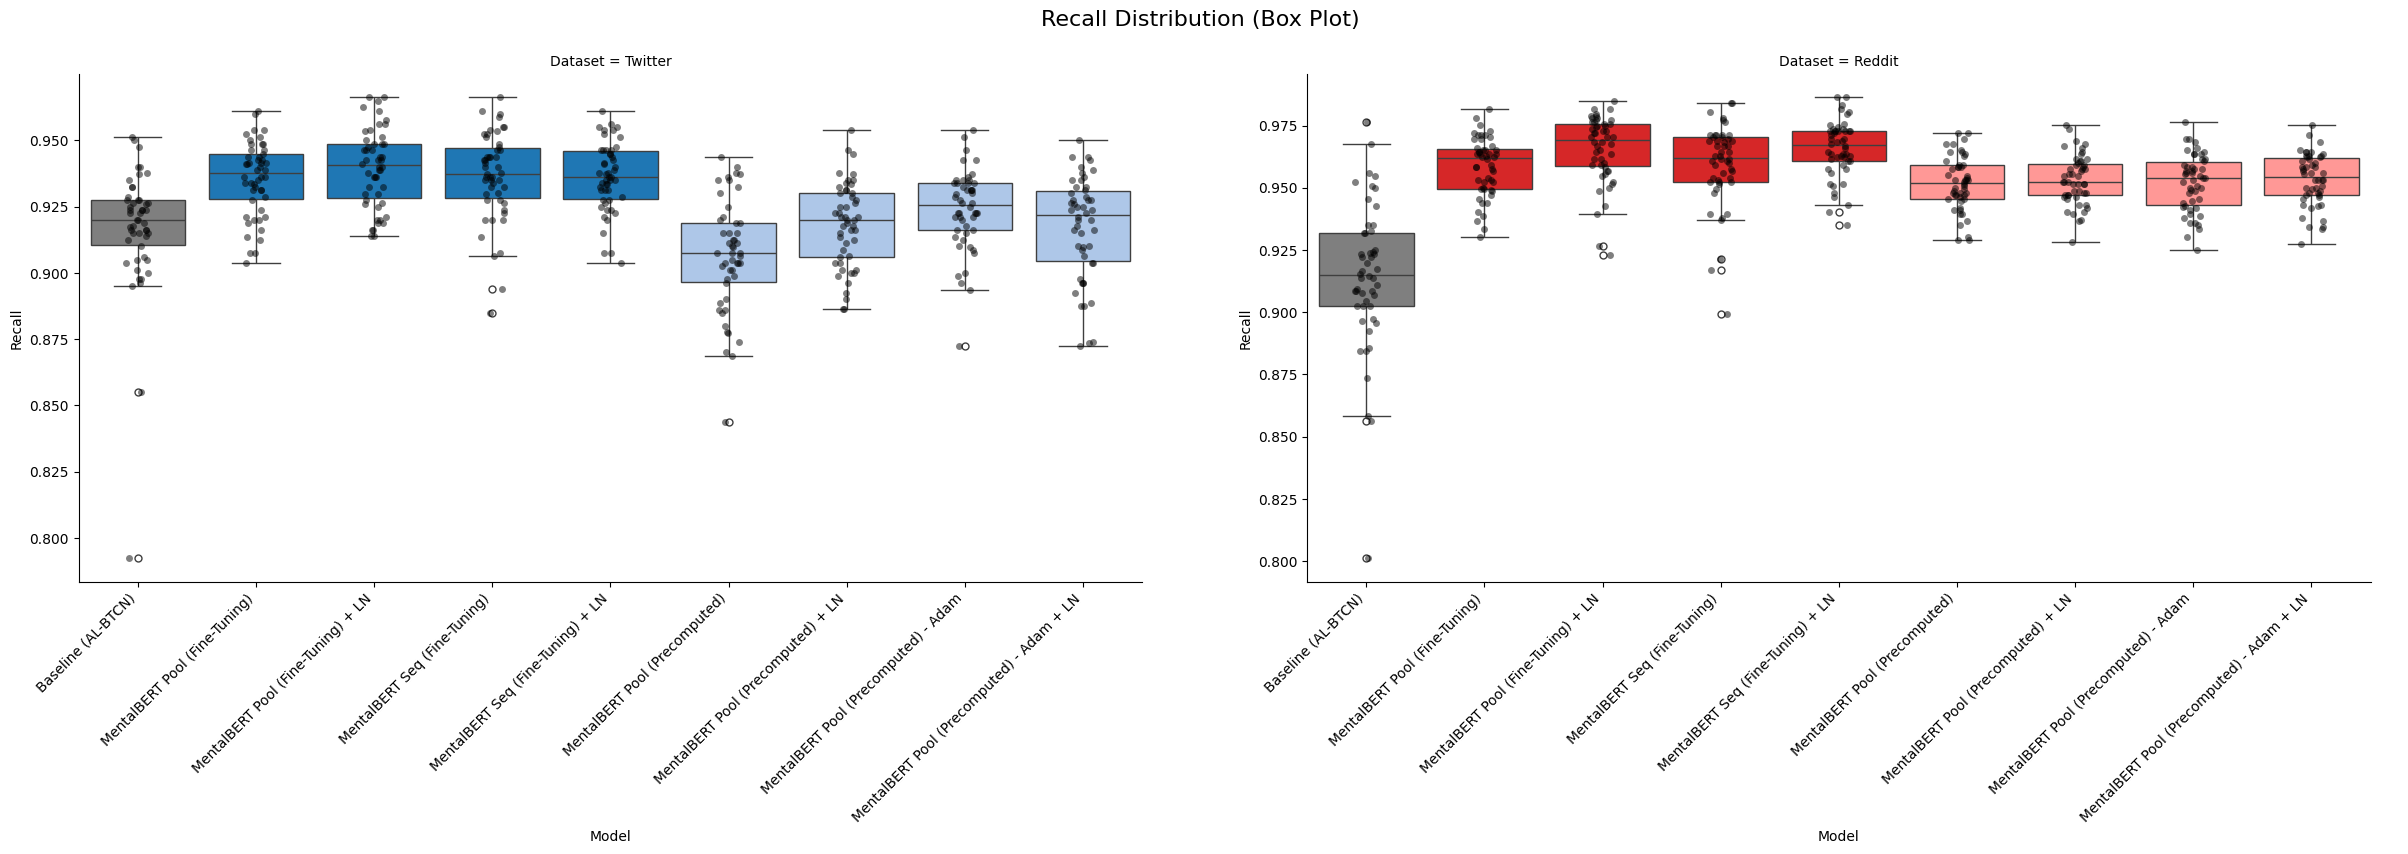

=== F1-Score ===


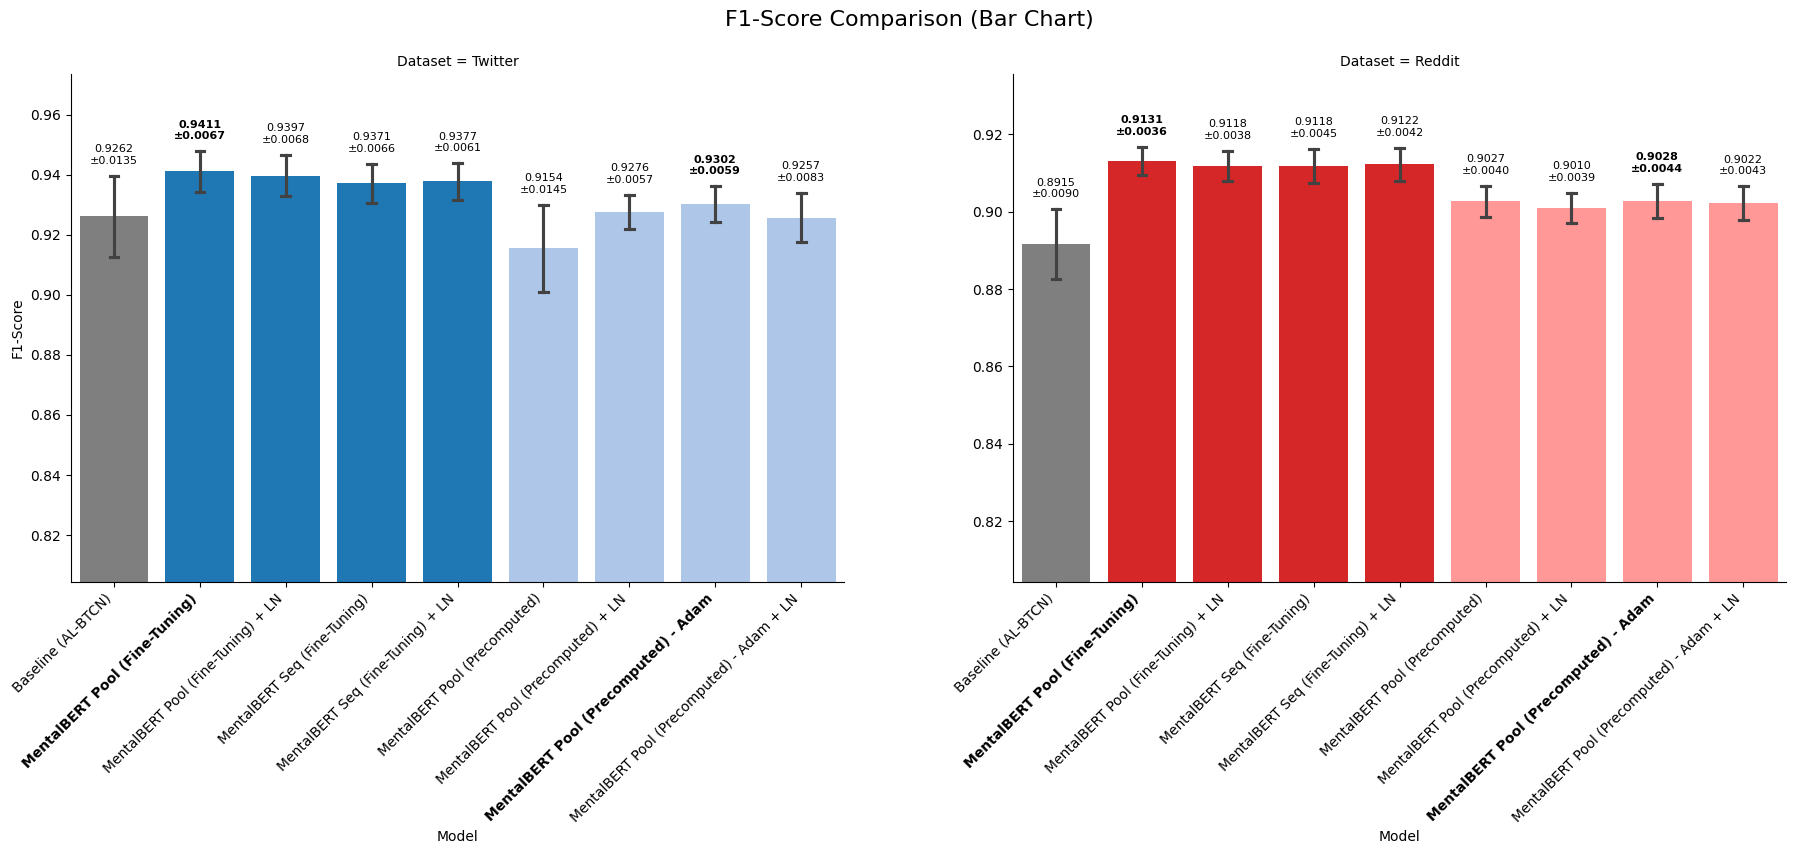

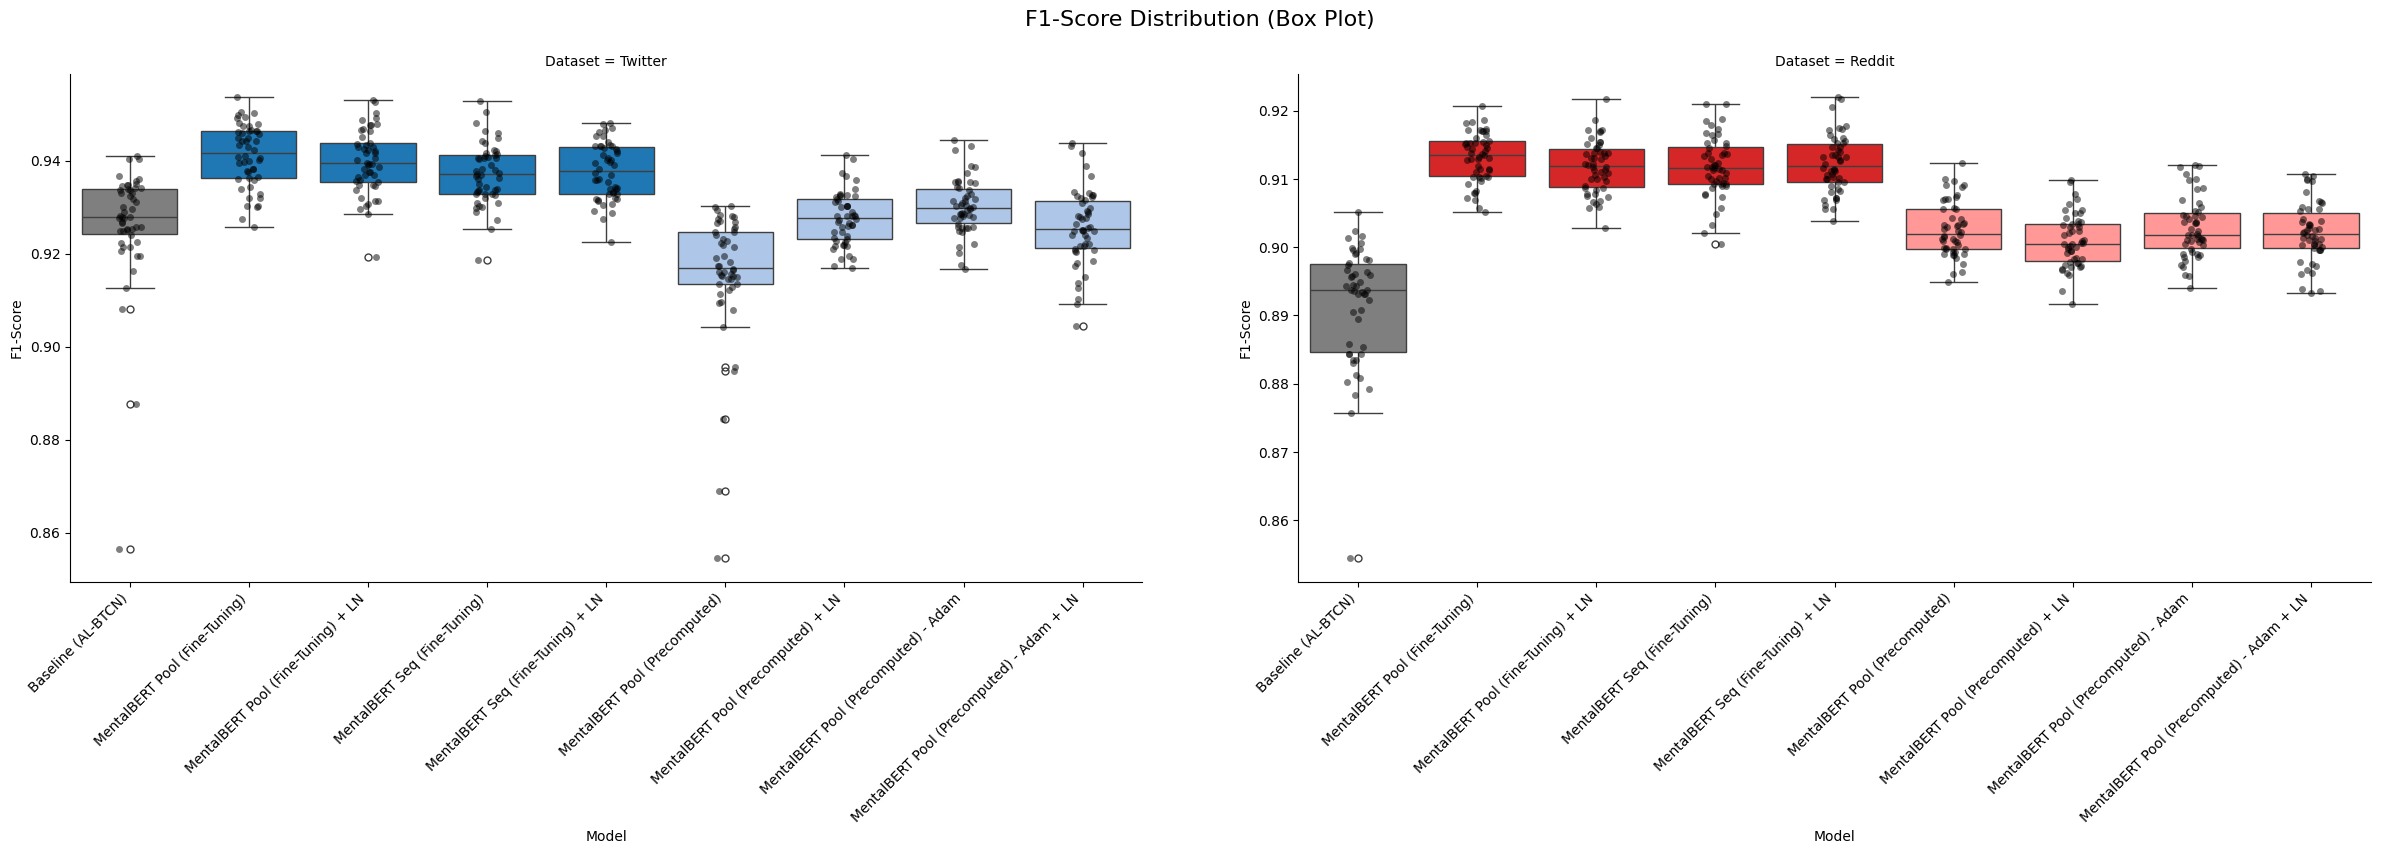

=== Training Time (s) ===


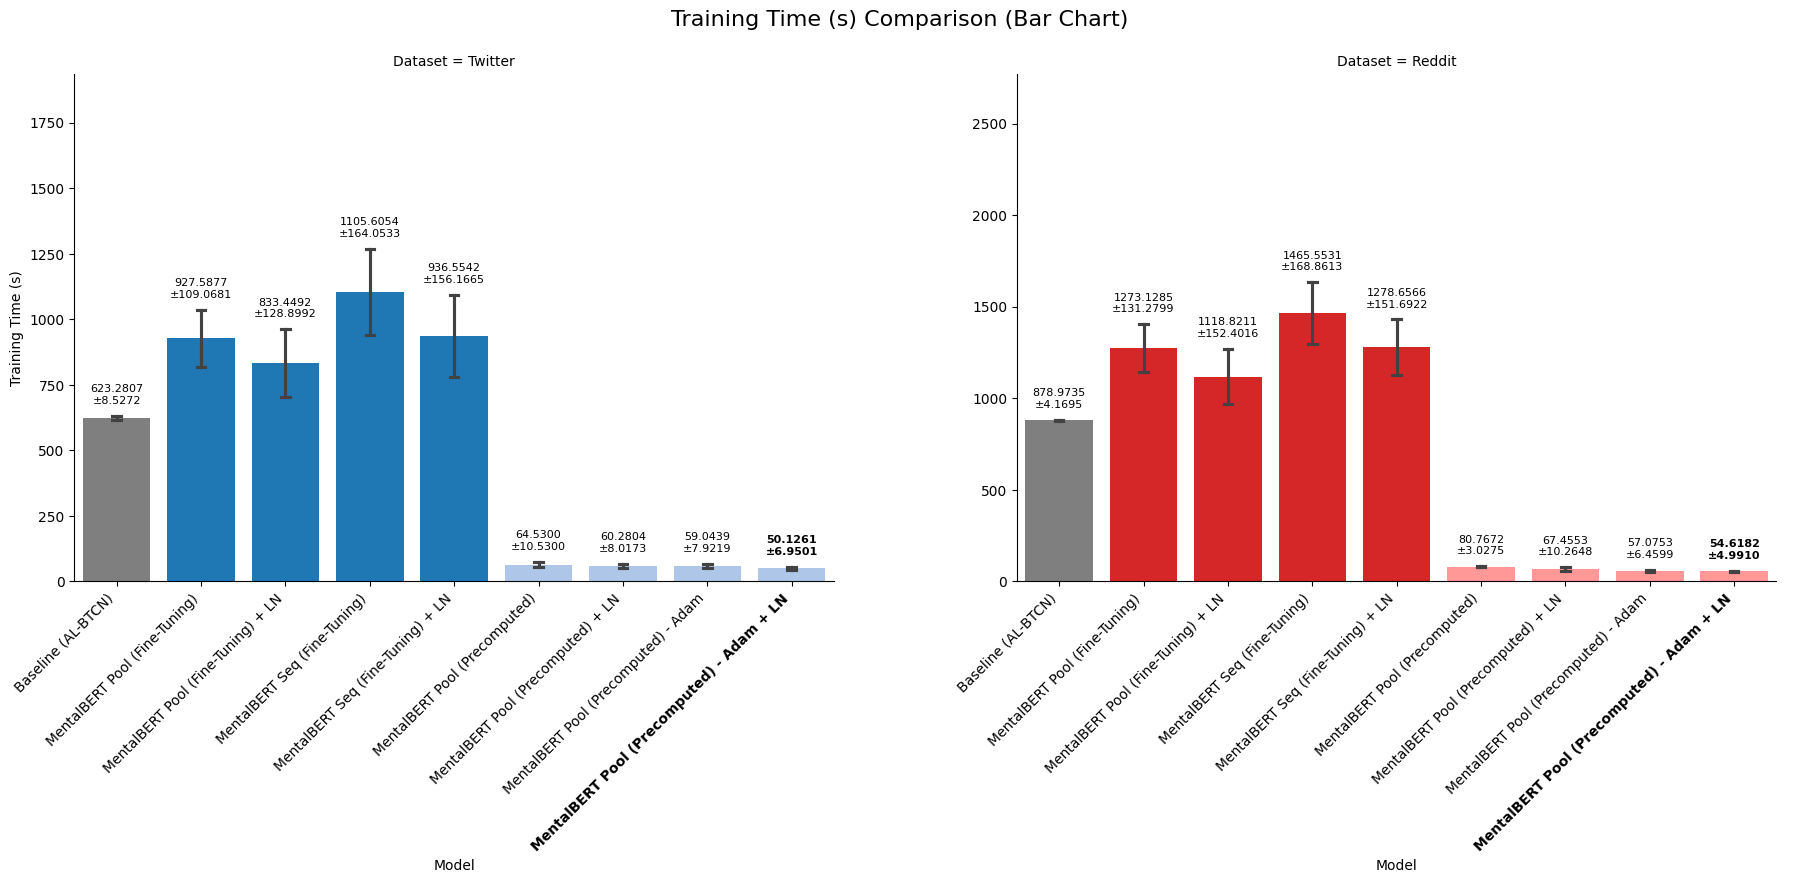

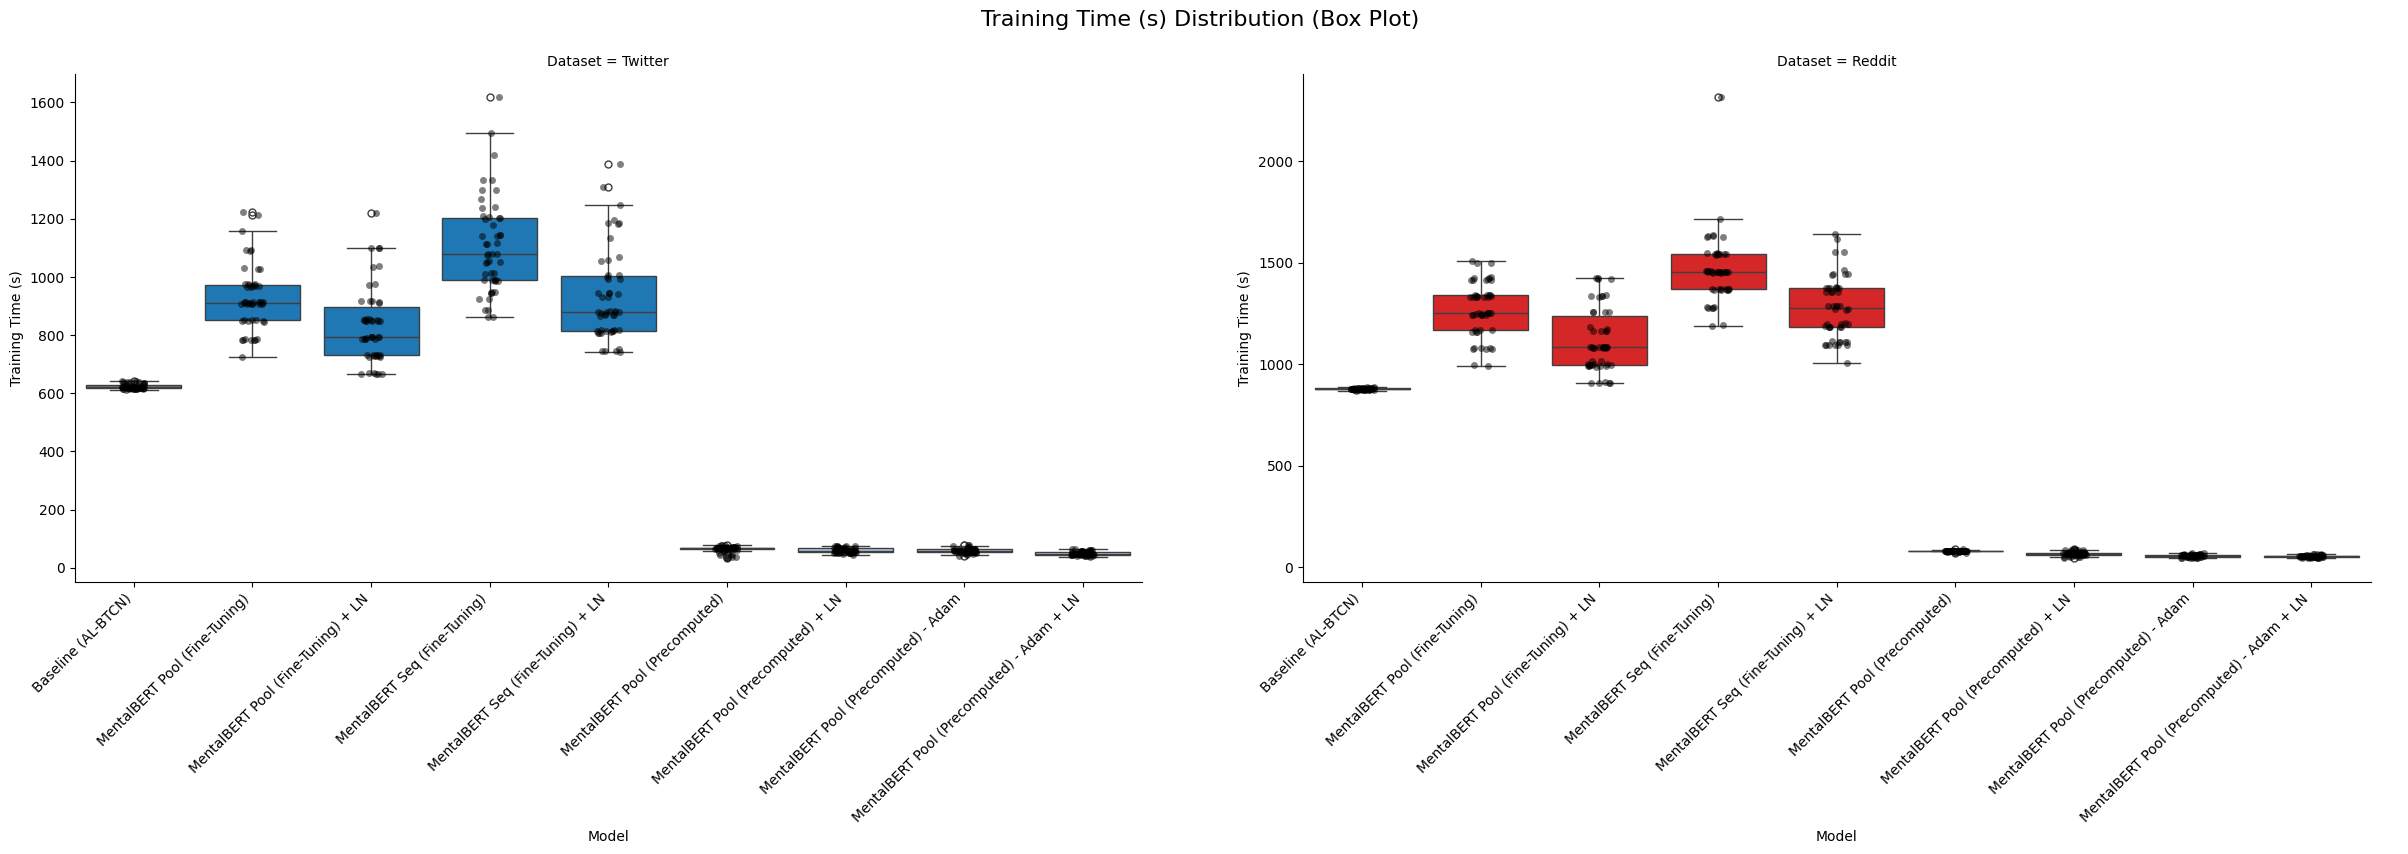

=== Max GPU Memory (MB) ===


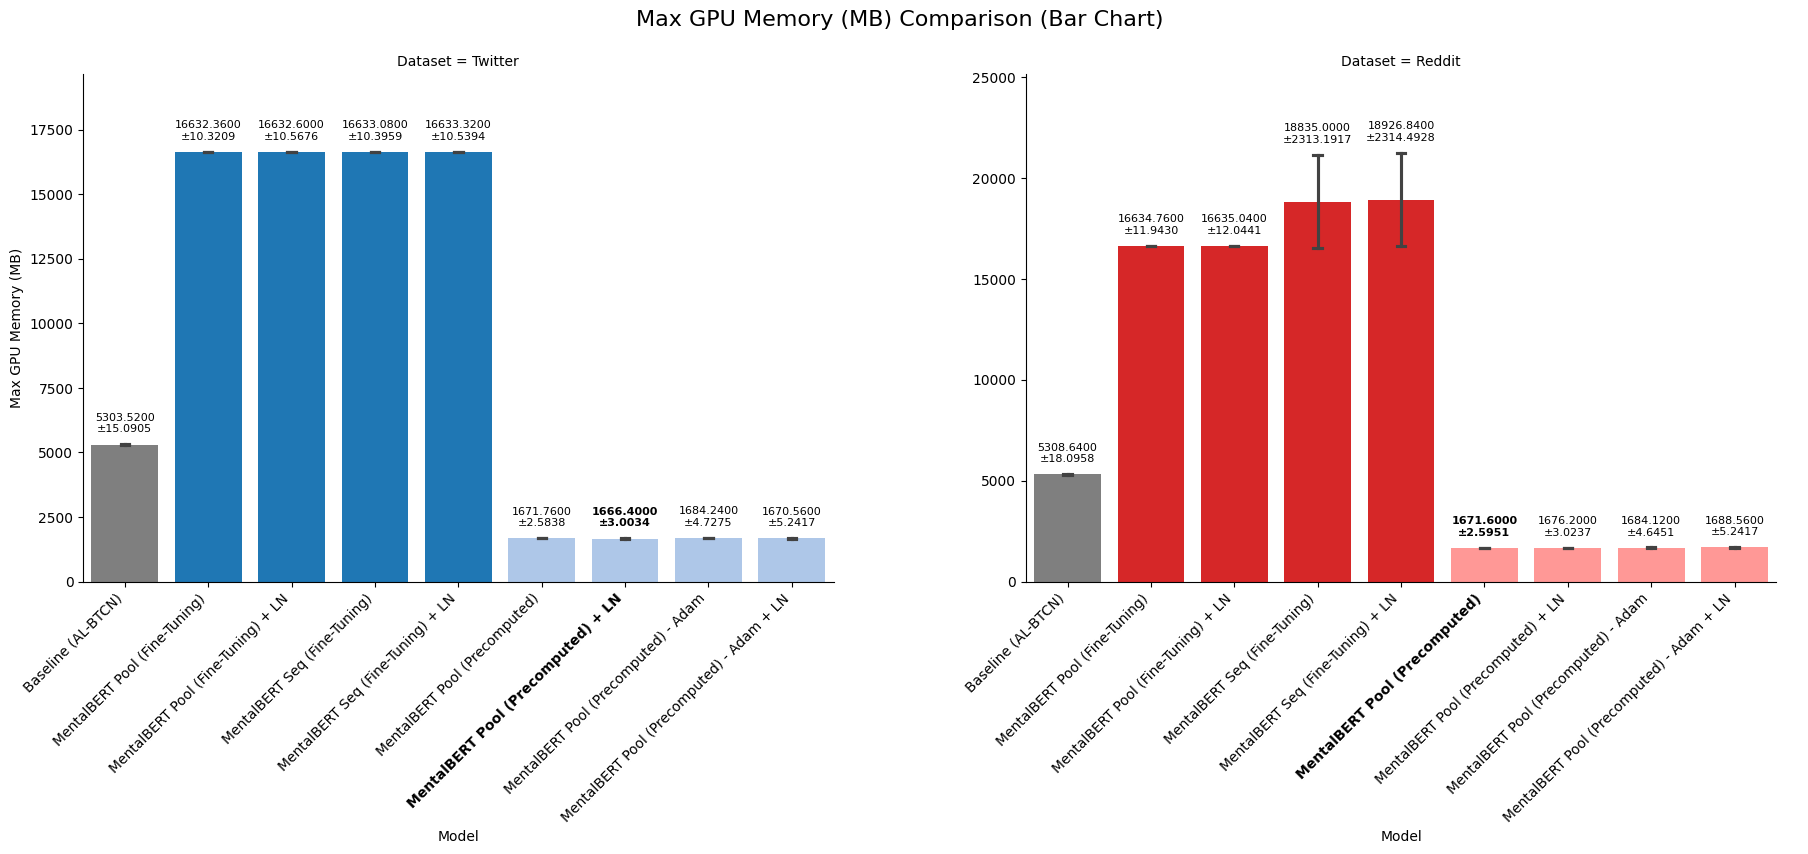

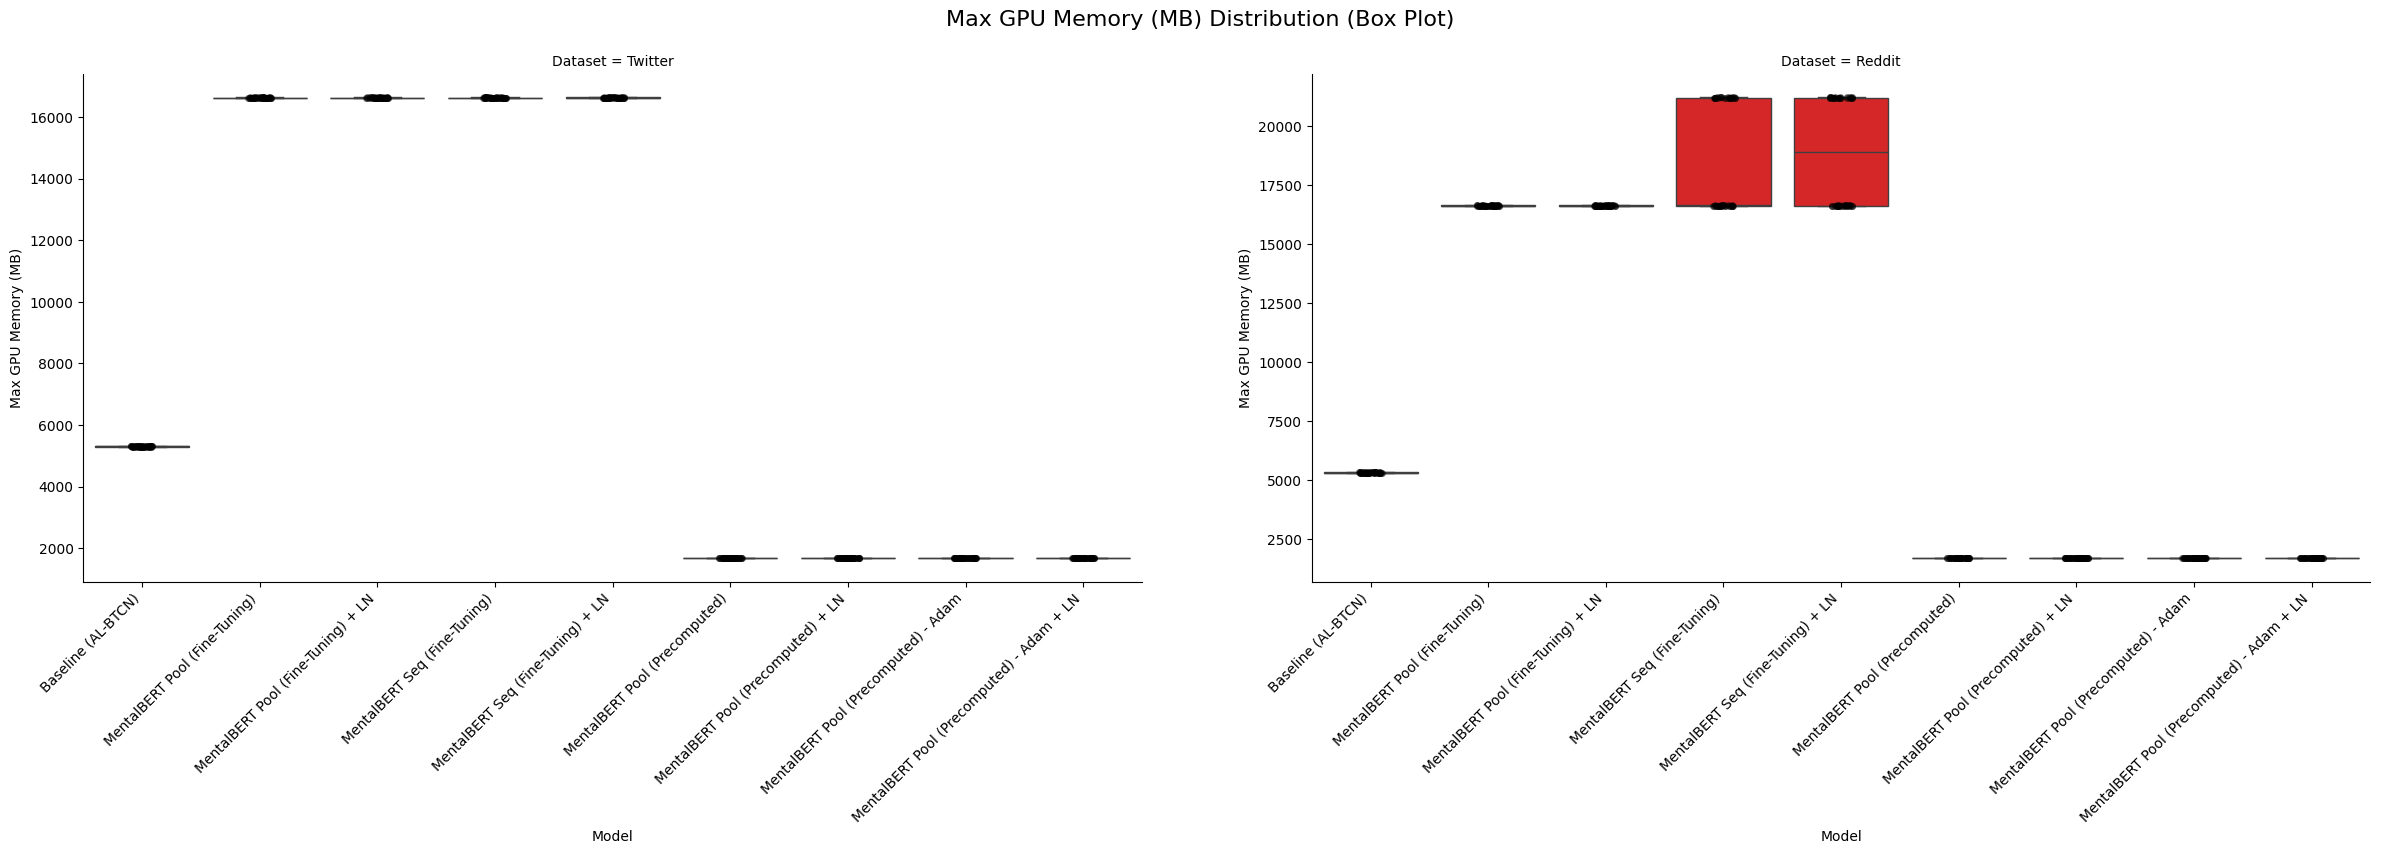

=== Avg GPU Memory (MB) ===


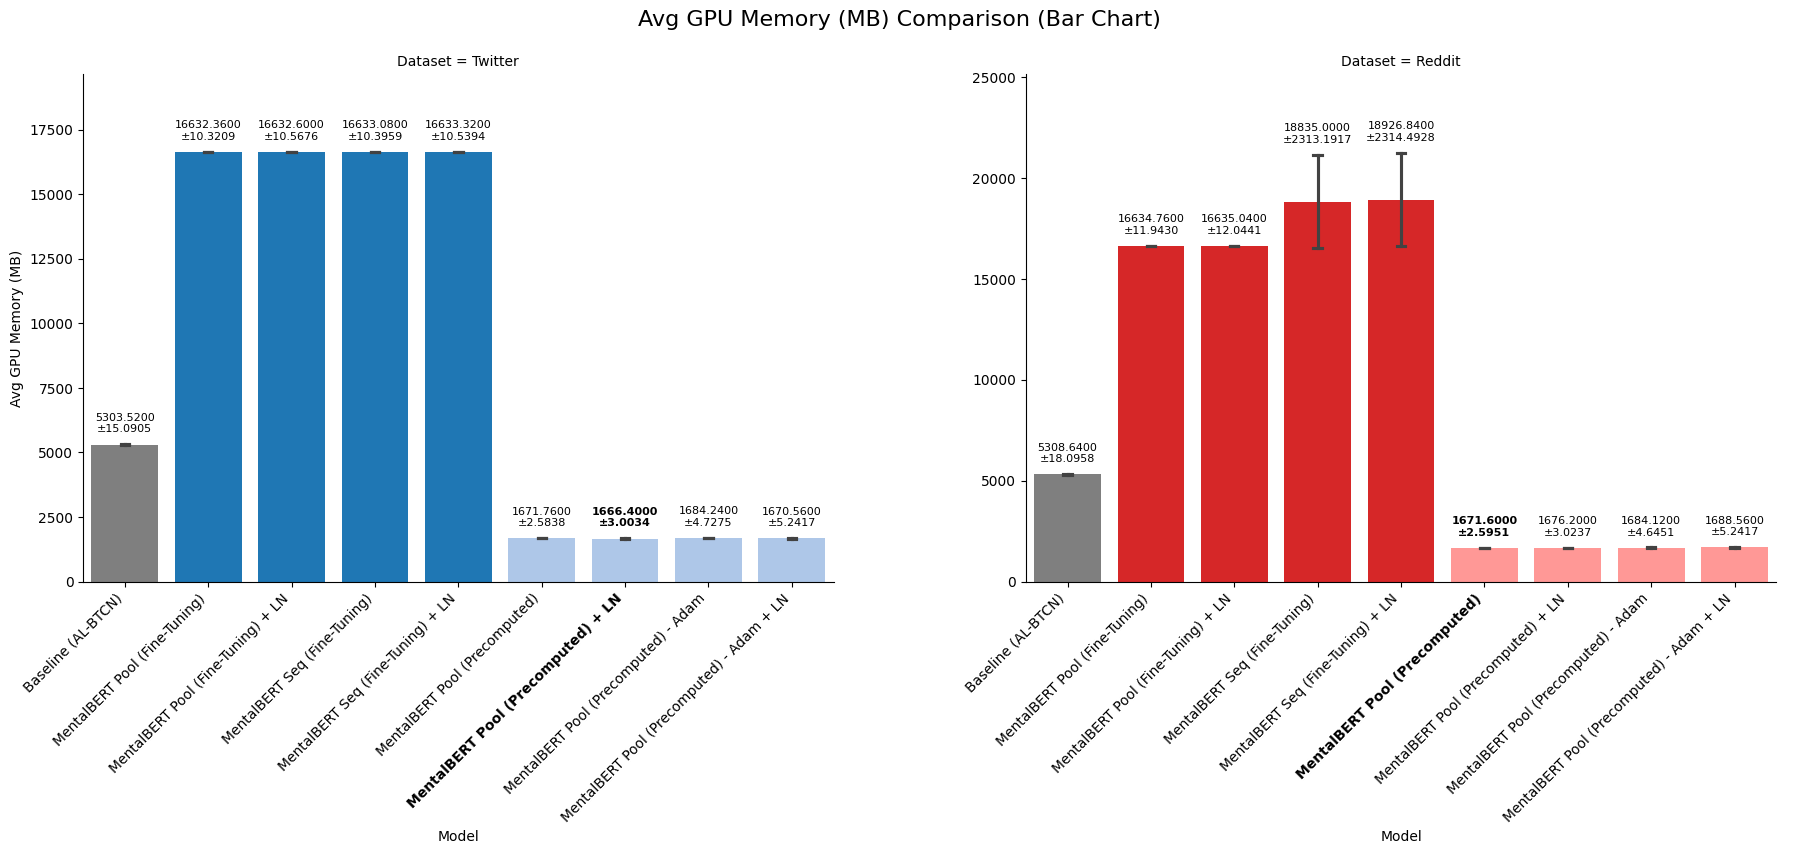

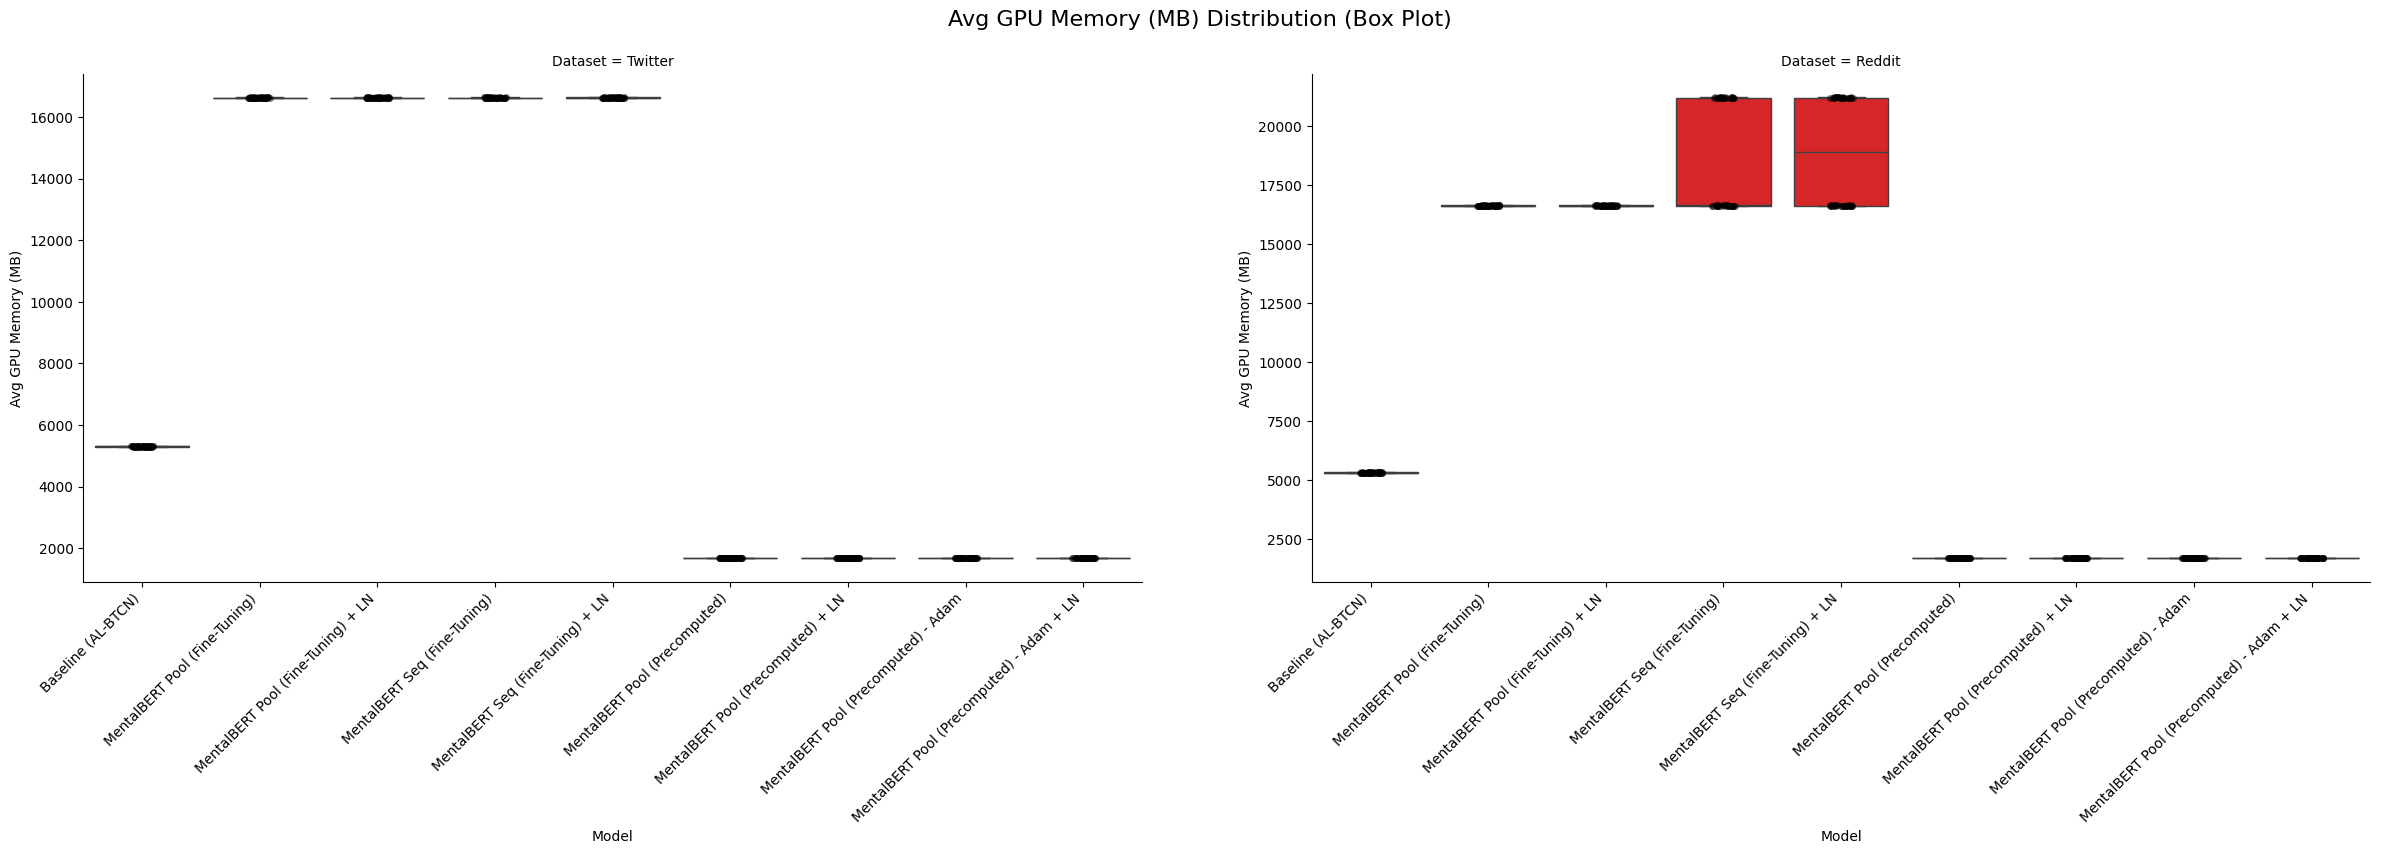

=== Epochs Run ===


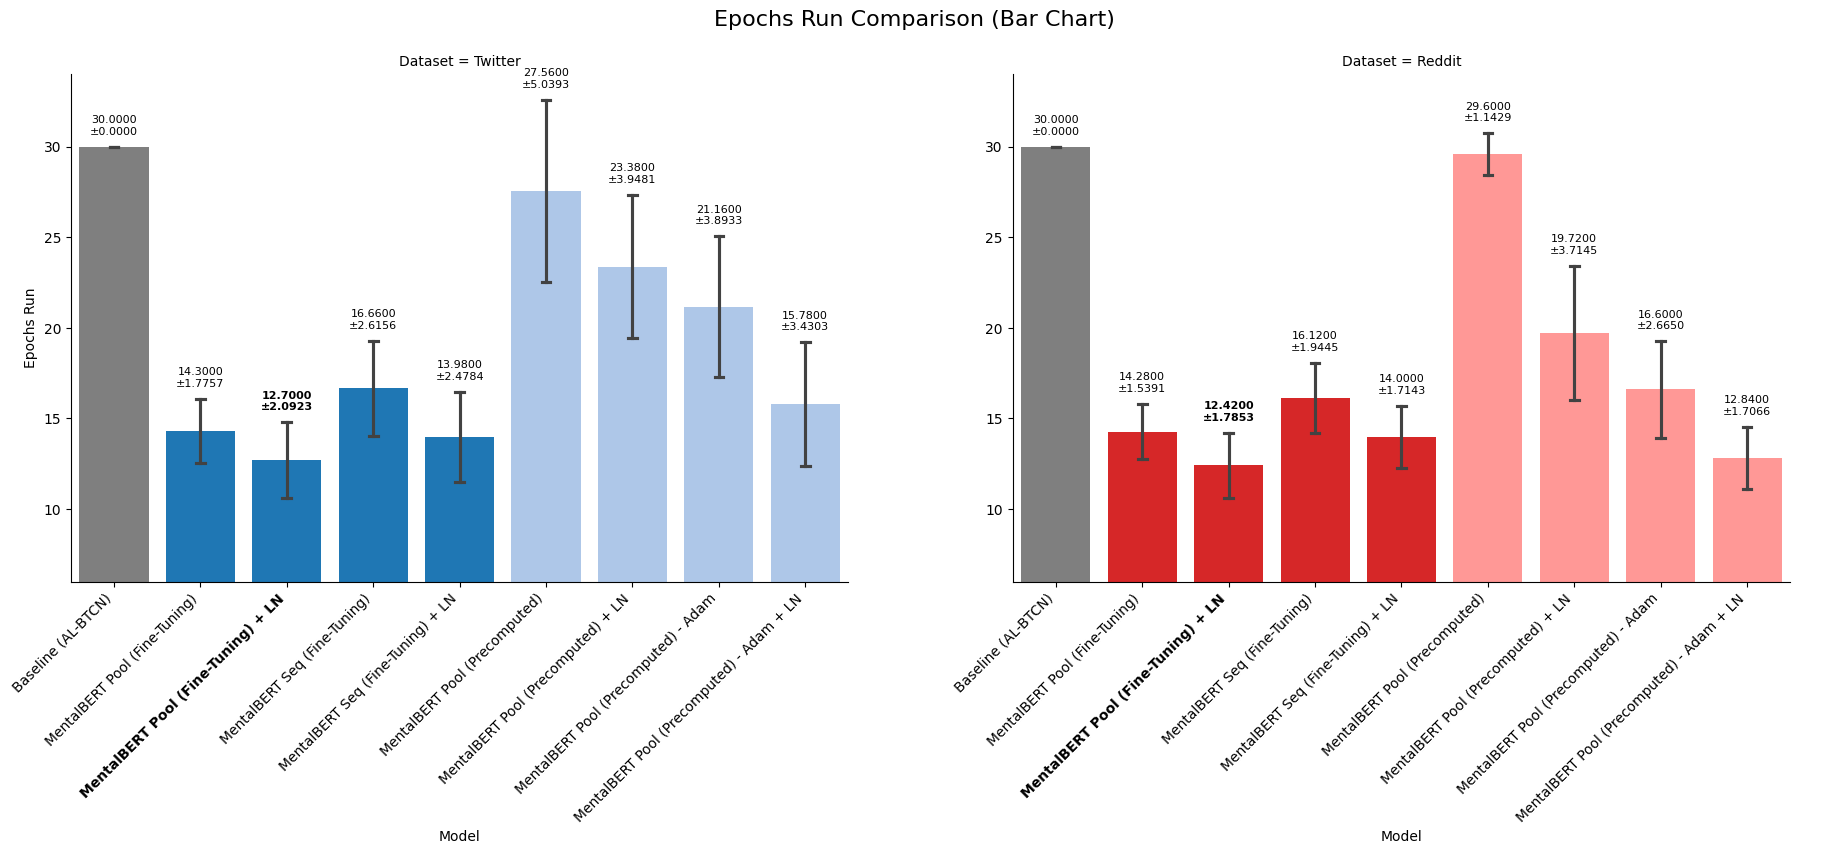

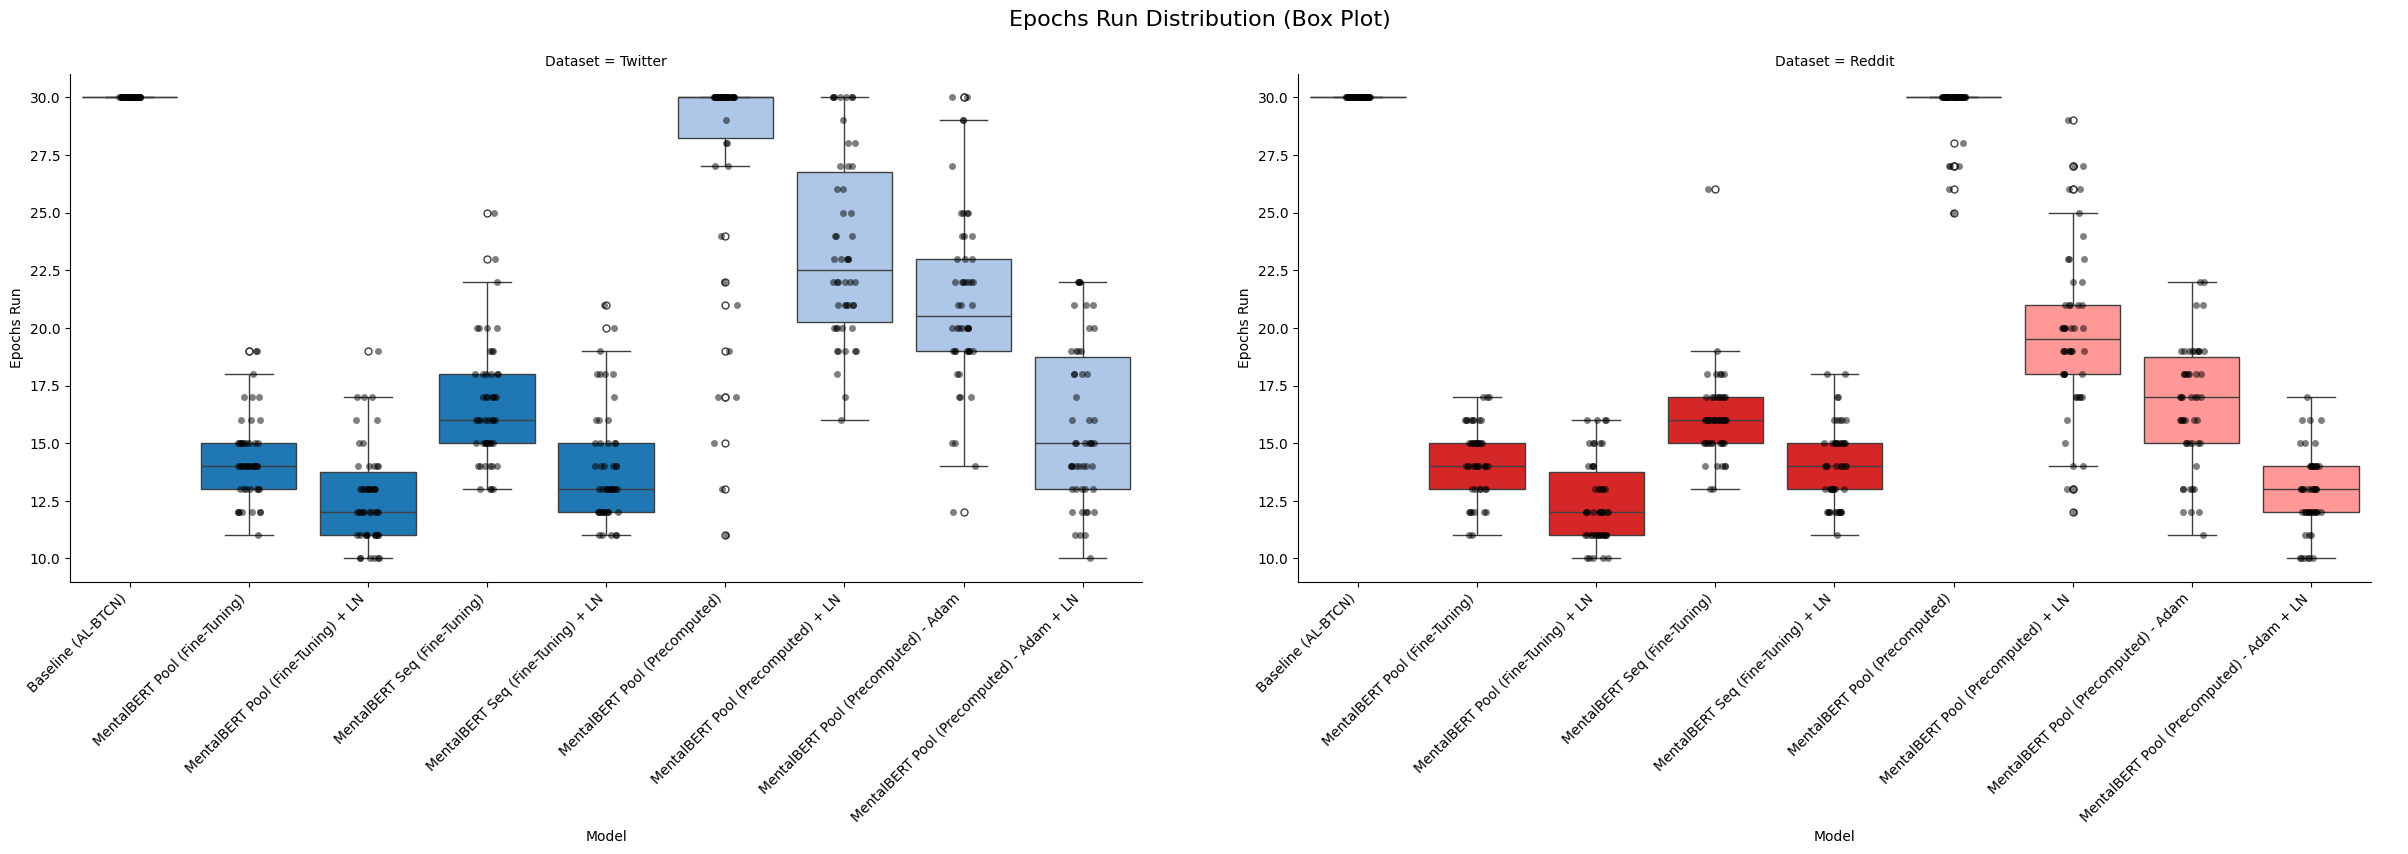

=== Avg Time/Epoch (s) ===


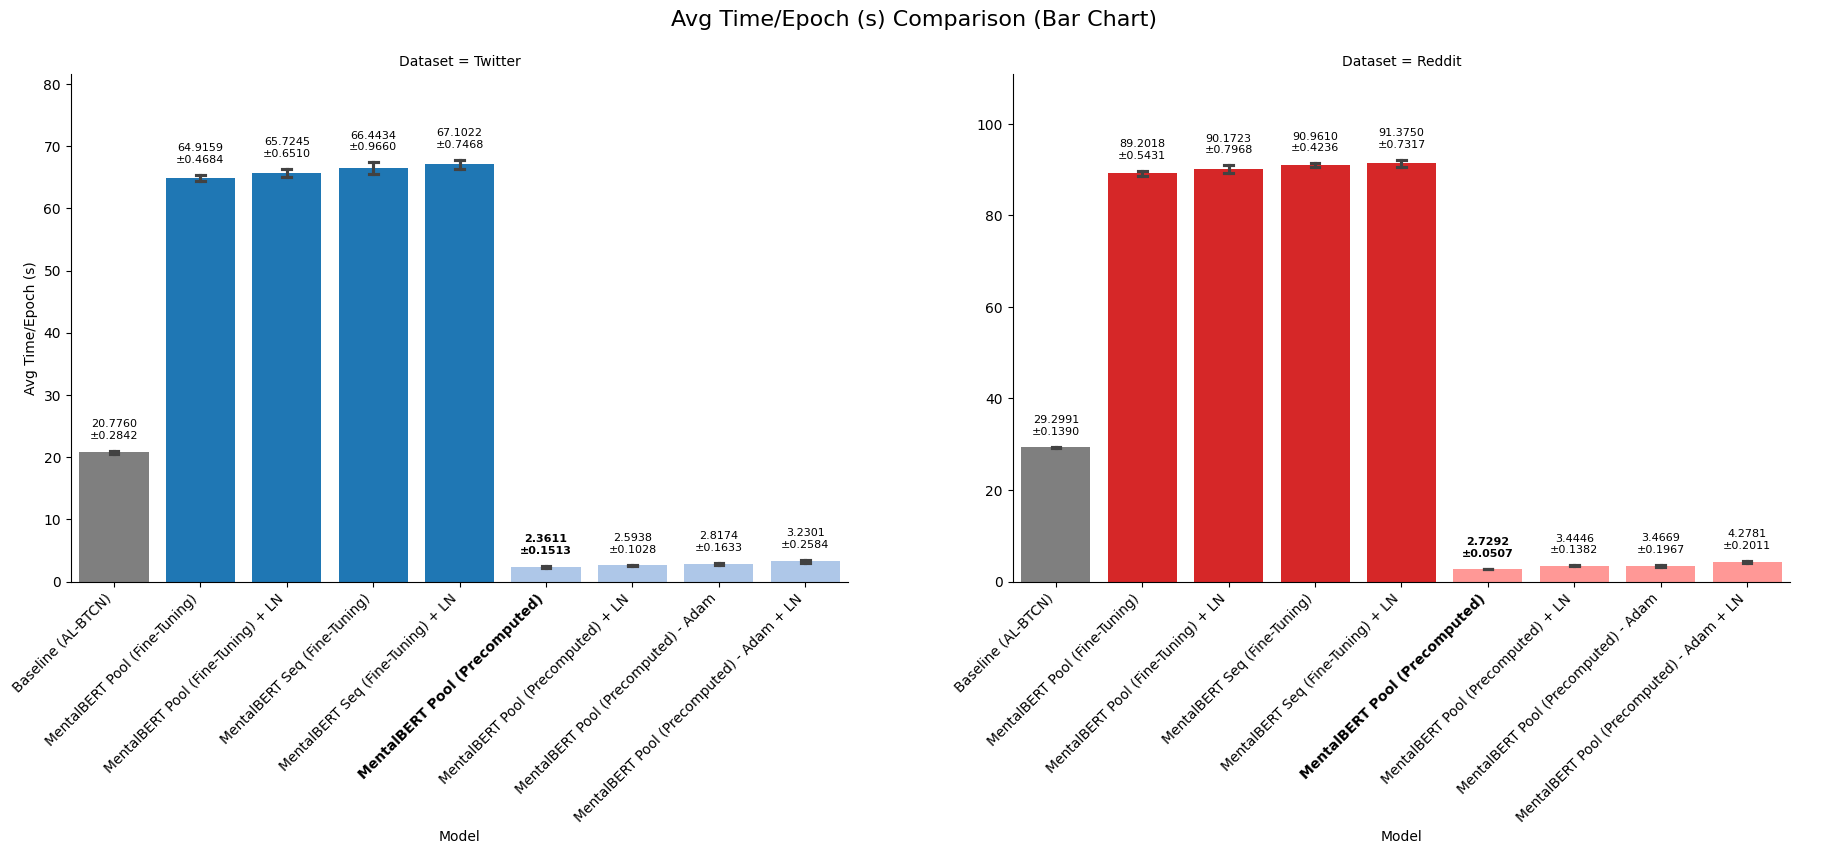

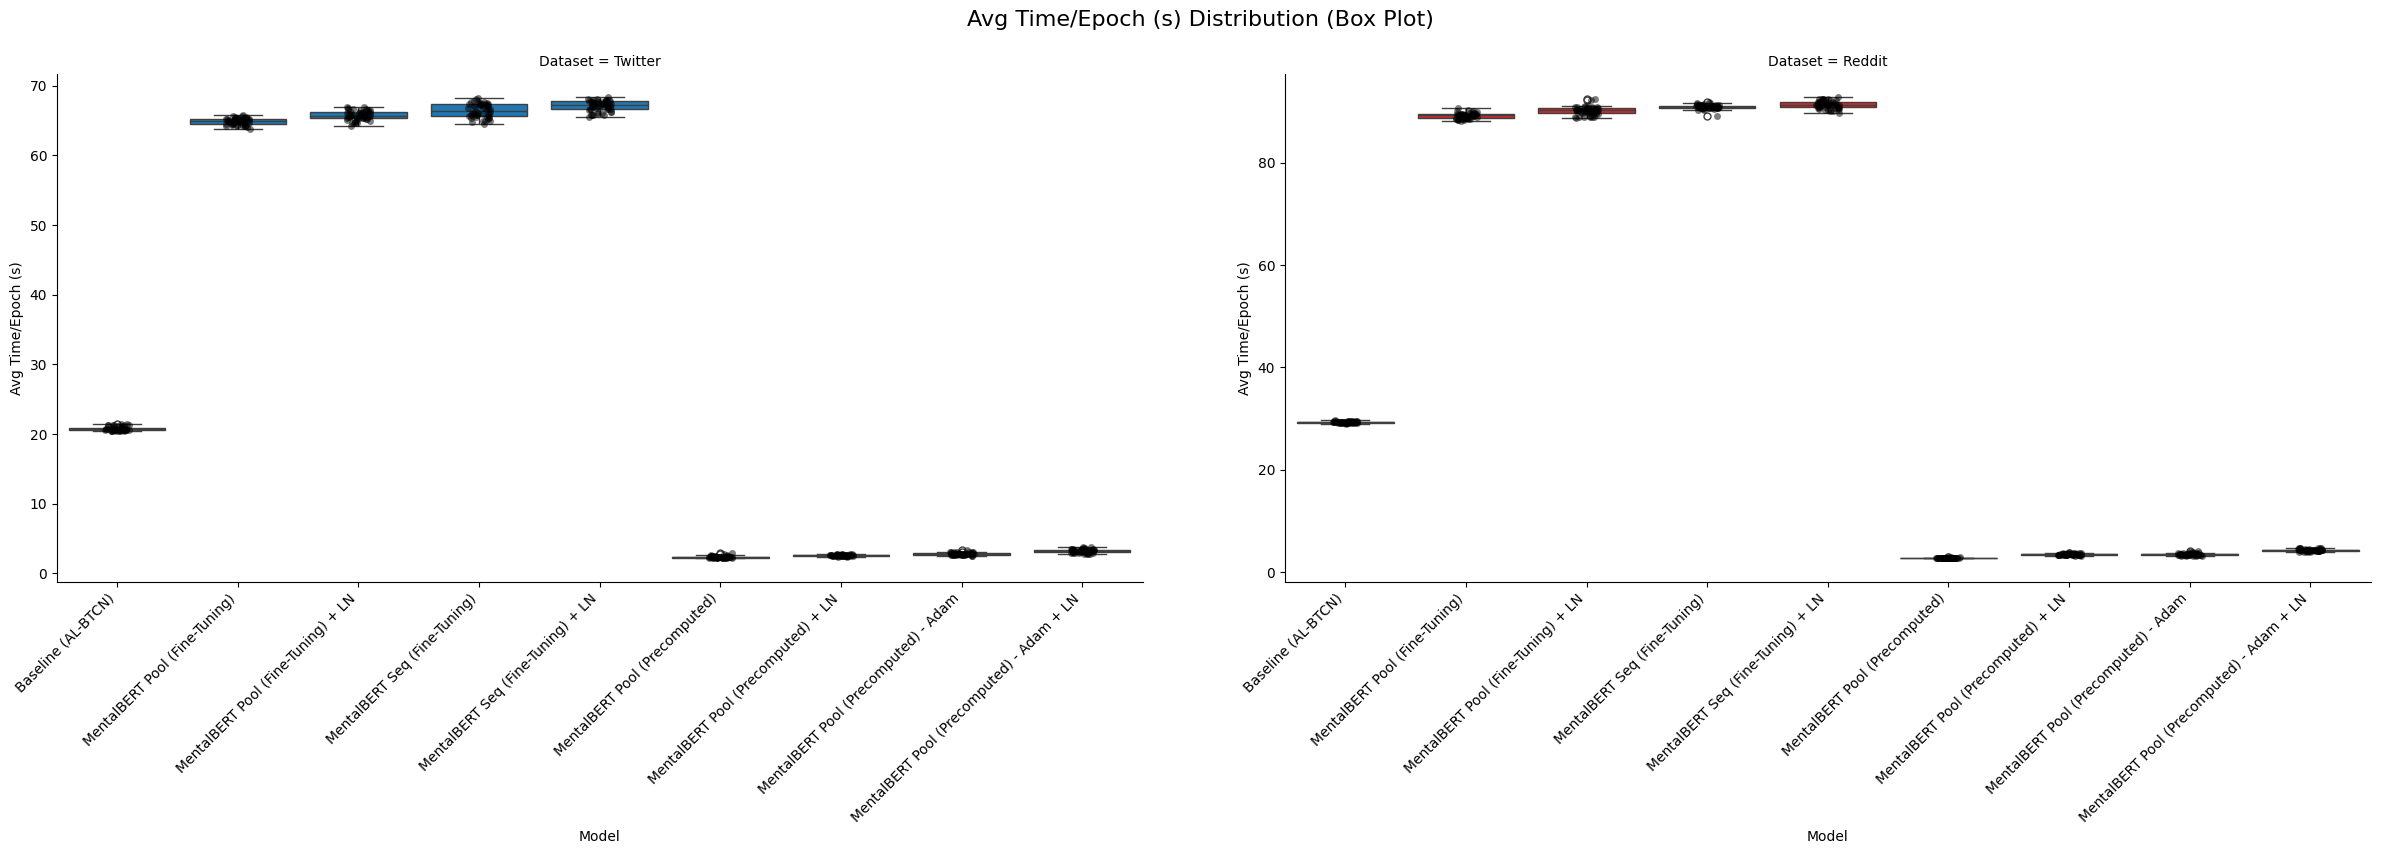

In [3]:
# Define Metrics and Order
metrics_to_plot = [
    'Accuracy', 'Precision', 'Recall', 'F1-Score', 
    'Training Time (s)', 'Max GPU Memory (MB)', 'Avg GPU Memory (MB)', 
    'Epochs Run', 'Avg Time/Epoch (s)'
]

model_order = [
    'Baseline (AL-BTCN)',
    'MentalBERT Pool (Fine-Tuning)',
    'MentalBERT Pool (Fine-Tuning) + LN',
    'MentalBERT Seq (Fine-Tuning)',
    'MentalBERT Seq (Fine-Tuning) + LN',
    'MentalBERT Pool (Precomputed)',
    'MentalBERT Pool (Precomputed) + LN',
    'MentalBERT Pool (Precomputed) - Adam',
    'MentalBERT Pool (Precomputed) - Adam + LN'
]

# Generate Plots
for metric in metrics_to_plot:
    print(f"=== {metric} ===")
    plot_combined_barchart(full_df, metric, order=model_order)
    plot_combined_boxplot(full_df, metric, order=model_order)

In [4]:
# Define Plotting Functions

def plot_barchart_dataset(df, dataset_name, metric, order=None):
    """
    Plots a bar chart for a specific dataset and metric.
    """
    # Determine if higher is better based on metric name
    higher_is_better = 'Time' not in metric and 'Memory' not in metric and 'Epochs' not in metric
    
    # Metrics to exclude from group-wise bolding
    exclude_from_group_bolding = ['Training Time (s)', 'Max GPU Memory (MB)', 'Avg GPU Memory (MB)', 'Epochs Run', 'Avg Time/Epoch (s)']
    use_group_bolding = metric not in exclude_from_group_bolding
    
    # Filter for dataset
    data = df[df['Dataset'] == dataset_name]
    
    if data.empty:
        print(f"No data for {dataset_name}")
        return

    plt.figure(figsize=(11, 7))
    ax = sns.barplot(
        data=data,
        x="Model Name",
        y=metric,
        order=order,
        errorbar='sd', # Show standard deviation
        capsize=.1
    )
    
    # Adjust y-axis limits
    y_min = df[metric].min()
    y_max = df[metric].max()
    y_range = y_max - y_min
    
    lower_ylim = y_min - y_range * 0.2
    if not higher_is_better and 'Accuracy' not in metric and 'F1' not in metric: # For time/memory, start from 0 usually, unless range is small
         lower_ylim = max(0, lower_ylim)
    
    # For accuracy/f1, we might want to zoom in, but let's keep it dynamic
    if 'Accuracy' in metric or 'F1' in metric or 'Precision' in metric or 'Recall' in metric:
         lower_ylim = max(0, y_min - 0.05) # Zoom in a bit for metrics
         
    upper_ylim = y_max + y_range * 0.2
    
    plt.ylim(lower_ylim, upper_ylim)
    
    plt.title(f'{metric} - {dataset_name}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    
    # Add annotations
    
    best_models = []
    
    if use_group_bolding:
        # Find best in 'Precomputed' and 'Fine-Tuning' groups
        if 'Model Group' in data.columns:
            for group in ['Precomputed', 'Fine-Tuning']:
                group_df = data[data['Model Group'] == group]
                if group_df.empty: continue
                
                means = group_df.groupby('Model Name')[metric].mean()
                if means.empty: continue
                
                if higher_is_better:
                    best_model = means.idxmax()
                else:
                    best_model = means.idxmin()
                best_models.append(best_model)
        else:
             # Fallback
             means = data.groupby('Model Name')[metric].mean()
             if not means.empty:
                if higher_is_better:
                    best_models.append(means.idxmax())
                else:
                    best_models.append(means.idxmin())
    else:
        # Original logic: global best
        means = data.groupby('Model Name')[metric].mean()
        if not means.empty:
            if higher_is_better:
                best_models.append(means.idxmax())
            else:
                best_models.append(means.idxmin())

    # Add text to bars
    if order:
        x_models = order
    else:
        x_models = sorted(data['Model Name'].unique())
        
    for i, patch in enumerate(ax.patches):
        if i >= len(x_models):
            continue
            
        model_name = x_models[i]
        
        subset = data[data['Model Name'] == model_name]
        
        if not subset.empty:
            mean_val = subset[metric].mean()
            std_val = subset[metric].std()
            
            x = patch.get_x() + patch.get_width() / 2
            y = patch.get_height()
            
            text = f"{mean_val:.4f}\n±{std_val:.4f}"
            
            is_best = (model_name in best_models)
            font_weight = 'bold' if is_best else 'normal'
            
            # Position text above the error bar
            text_y = y + std_val + (upper_ylim - lower_ylim)*0.02
            
            ax.text(
                x, 
                text_y, 
                text, 
                ha='center', 
                va='bottom', 
                fontsize=9, 
                color='black',
                fontweight=font_weight
            )
            
            if is_best:
                # Bold x-axis label
                xticklabels = ax.get_xticklabels()
                for label in xticklabels:
                    if label.get_text() == model_name:
                        label.set_fontweight('bold')
            
            # Apply Color
            model_group = subset['Model Group'].iloc[0] if 'Model Group' in subset.columns else 'Unknown'
            
            color = '#7f7f7f' # Default grey (Baseline)
            if dataset_name == 'Twitter':
                if model_group == 'Fine-Tuning': color = '#1f77b4' # Blue
                elif model_group == 'Precomputed': color = '#aec7e8' # Light Blue
            elif dataset_name == 'Reddit':
                if model_group == 'Fine-Tuning': color = '#d62728' # Red
                elif model_group == 'Precomputed': color = '#ff9896' # Light Red
            
            patch.set_facecolor(color)

    plt.tight_layout()
    plt.show()

def plot_boxplot_comparison(df, dataset_name, metric, order=None):
    """
    Plots a boxplot comparison for a specific dataset.
    """
    data = df[df['Dataset'] == dataset_name]
    
    if data.empty:
        return

    plt.figure(figsize=(14, 7))
    ax = sns.boxplot(
        data=data,
        x="Model Name",
        y=metric,
        order=order
    )
    
    # Add points
    sns.stripplot(
        data=data,
        x="Model Name",
        y=metric,
        order=order,
        color='black',
        alpha=0.5,
        jitter=True,
        ax=ax
    )
    
    plt.title(f'{metric} Distribution - {dataset_name}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    
    # Apply colors
    x_models = [label.get_text() for label in ax.get_xticklabels()]
    boxes = ax.artists if ax.artists else ax.patches
    
    for i, box in enumerate(boxes):
        if i >= len(x_models):
            continue
            
        model_name = x_models[i]
        subset = data[data['Model Name'] == model_name]
        
        if not subset.empty:
            # Determine Color
            model_group = subset['Model Group'].iloc[0] if 'Model Group' in subset.columns else 'Unknown'
            
            color = '#7f7f7f' # Default grey (Baseline)
            if dataset_name == 'Twitter':
                if model_group == 'Fine-Tuning': color = '#1f77b4' # Blue
                elif model_group == 'Precomputed': color = '#aec7e8' # Light Blue
            elif dataset_name == 'Reddit':
                if model_group == 'Fine-Tuning': color = '#d62728' # Red
                elif model_group == 'Precomputed': color = '#ff9896' # Light Red
            
            box.set_facecolor(color)

    plt.tight_layout()
    plt.show()

In [5]:
# Define Metrics and Order
metrics_to_plot = [
    'Accuracy', 'Precision', 'Recall', 'F1-Score', 
    'Training Time (s)', 'Max GPU Memory (MB)', 'Avg GPU Memory (MB)', 
    'Epochs Run', 'Avg Time/Epoch (s)'
]

# Define a logical order for models
# We have Baseline, Fine-Tuning (Pool, Seq), Precomputed (Pool, Seq)
# And Optimizers: Adam, SGD
# Naming convention: " - Adam" appended only if Adam.

model_order_v2 = [
    'Baseline (AL-BTCN)',
    'MentalBERT Pool (Fine-Tuning)',
    'MentalBERT Pool (Fine-Tuning) + LN',
    'MentalBERT Pool (Precomputed)',
    'MentalBERT Pool (Precomputed) + LN',
    'MentalBERT Pool (Precomputed) - Adam',
    'MentalBERT Pool (Precomputed) - Adam + LN'
]

# Use full_df directly as we updated the loading logic
full_df_v2 = full_df

print("Updated Model Names:", full_df_v2['Model Name'].unique())

Updated Model Names: ['Baseline (AL-BTCN)' 'MentalBERT Pool (Fine-Tuning)'
 'MentalBERT Seq (Fine-Tuning)' 'MentalBERT Pool (Precomputed)'
 'MentalBERT Pool (Precomputed) - Adam'
 'MentalBERT Pool (Fine-Tuning) + LN' 'MentalBERT Seq (Fine-Tuning) + LN'
 'MentalBERT Pool (Precomputed) - Adam + LN'
 'MentalBERT Pool (Precomputed) + LN']


=== Accuracy ===
--- Reddit ---


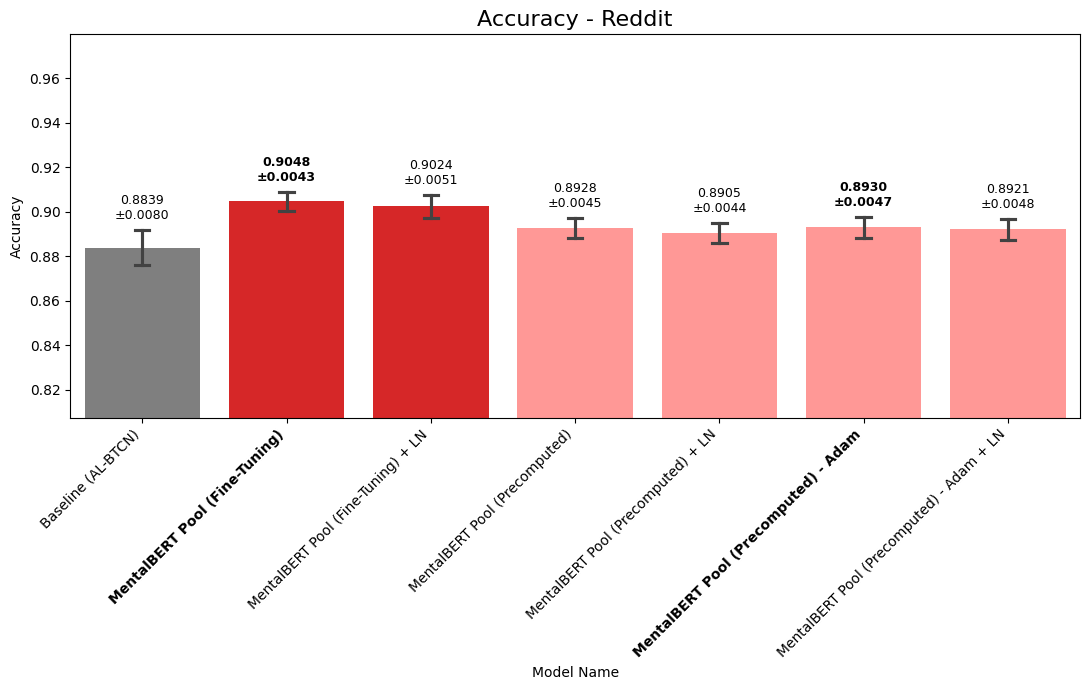

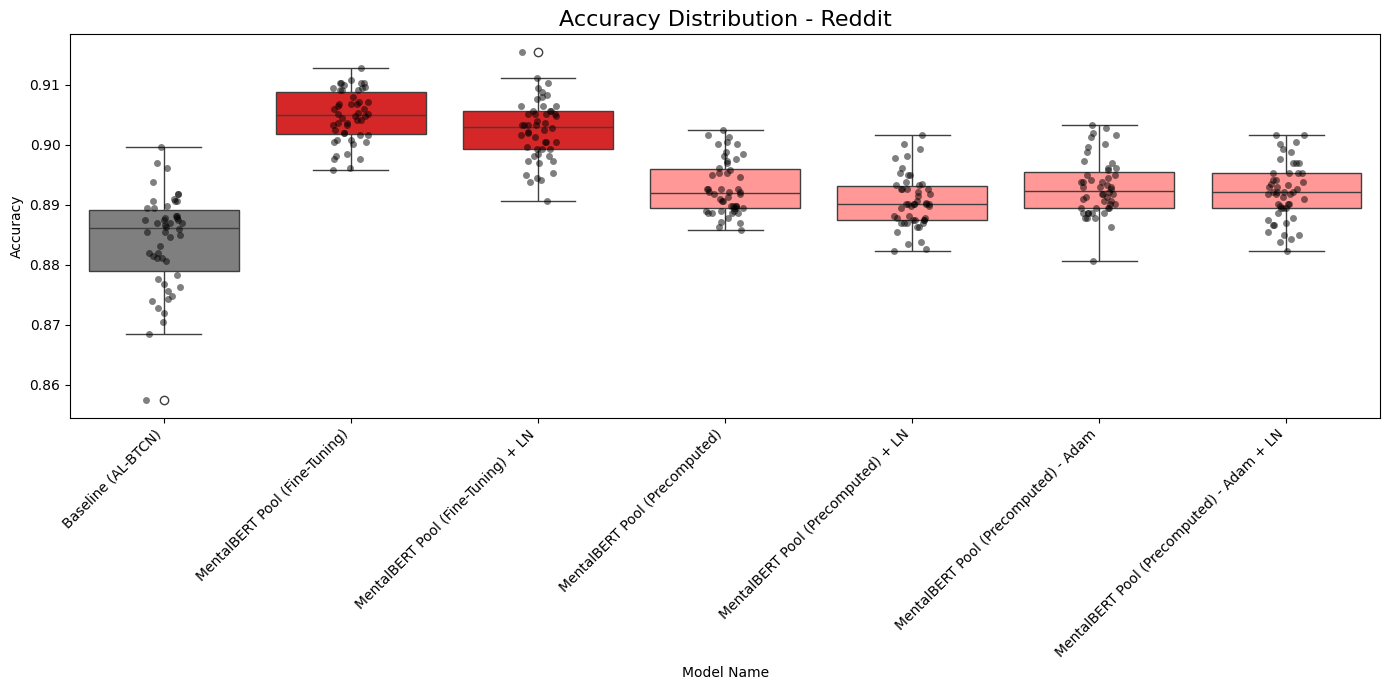

--- Twitter ---


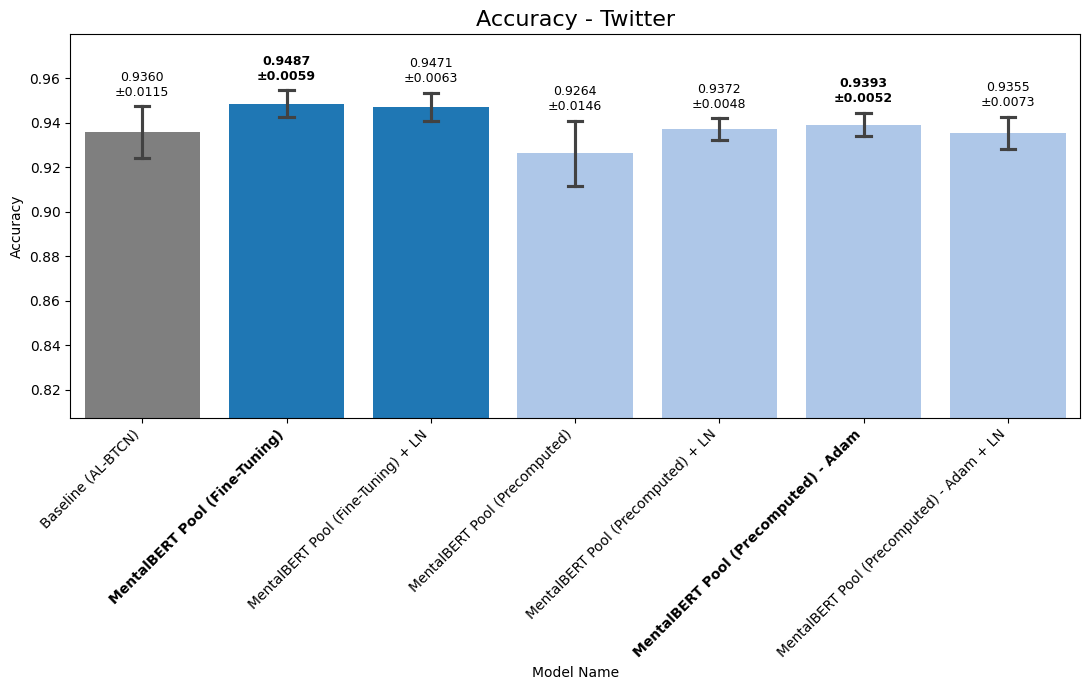

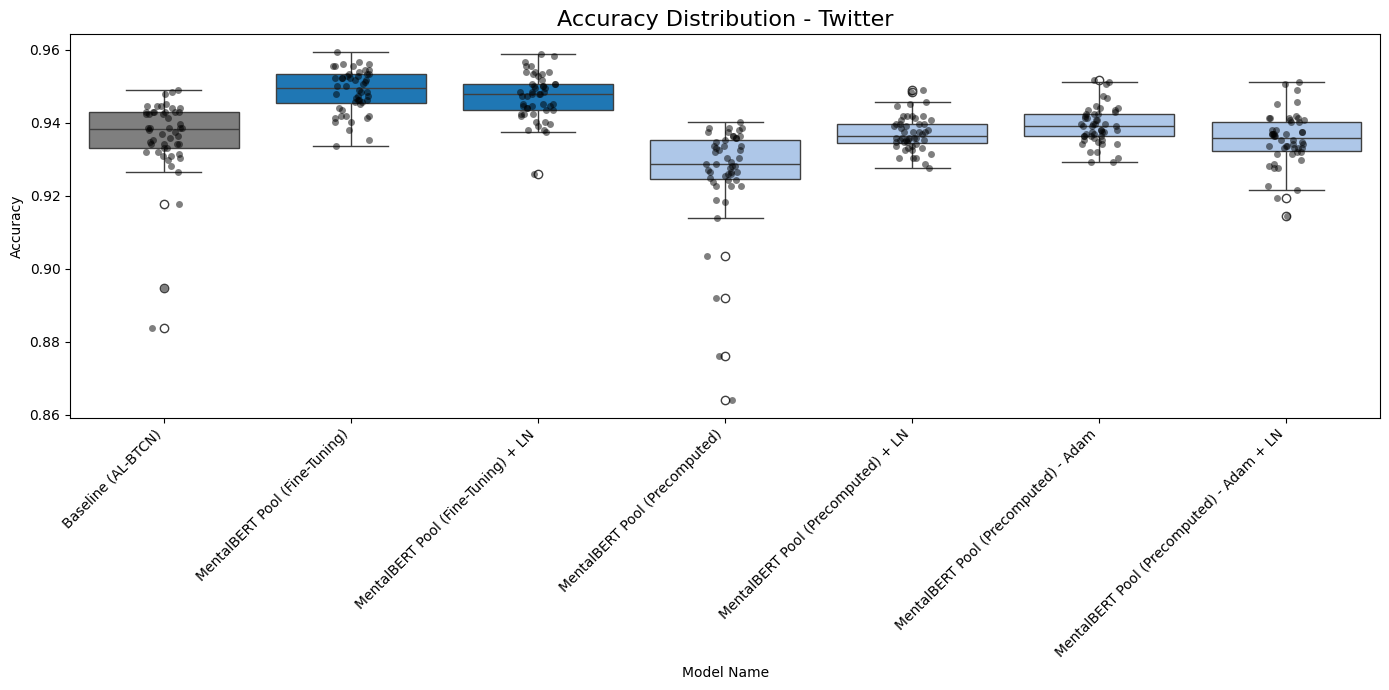

=== Precision ===
--- Reddit ---


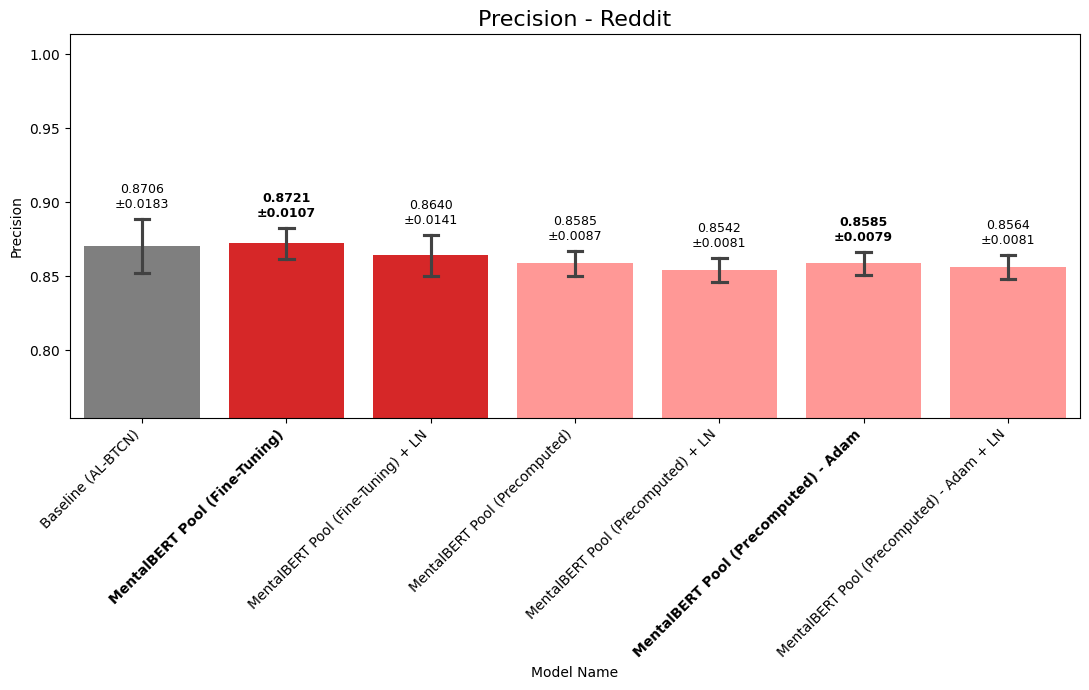

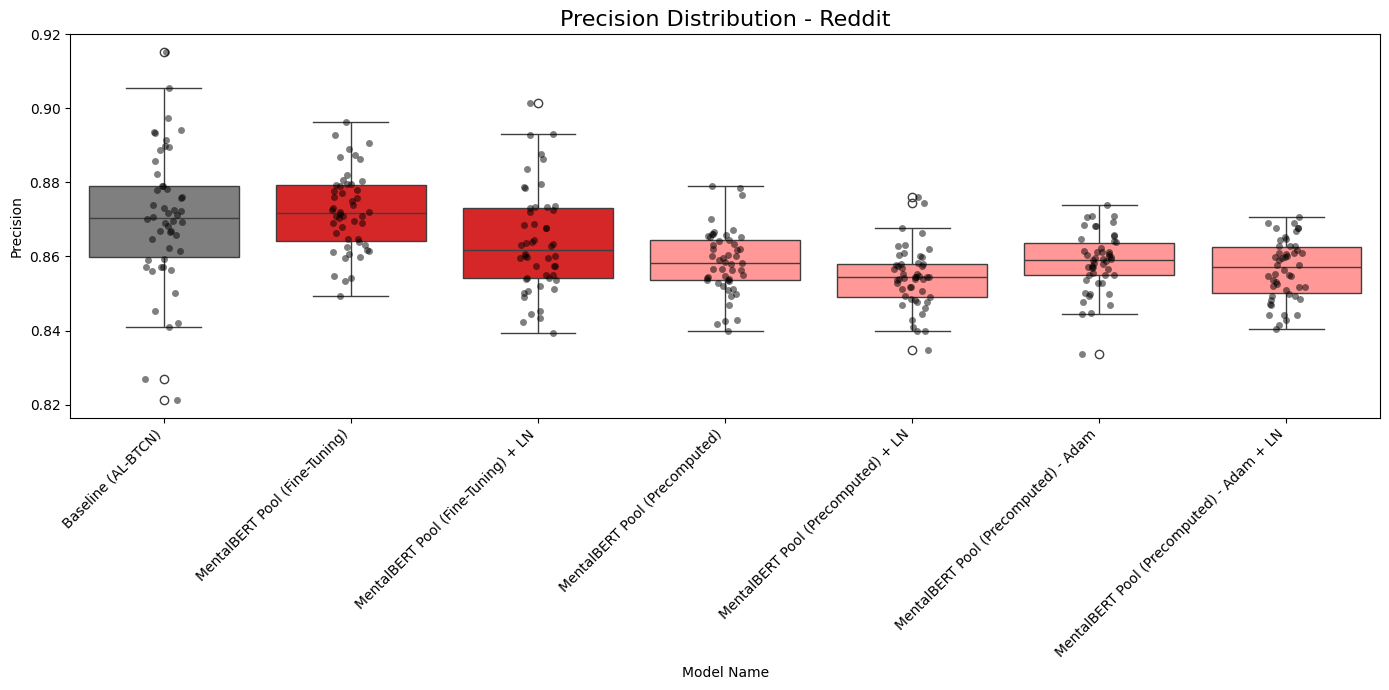

--- Twitter ---


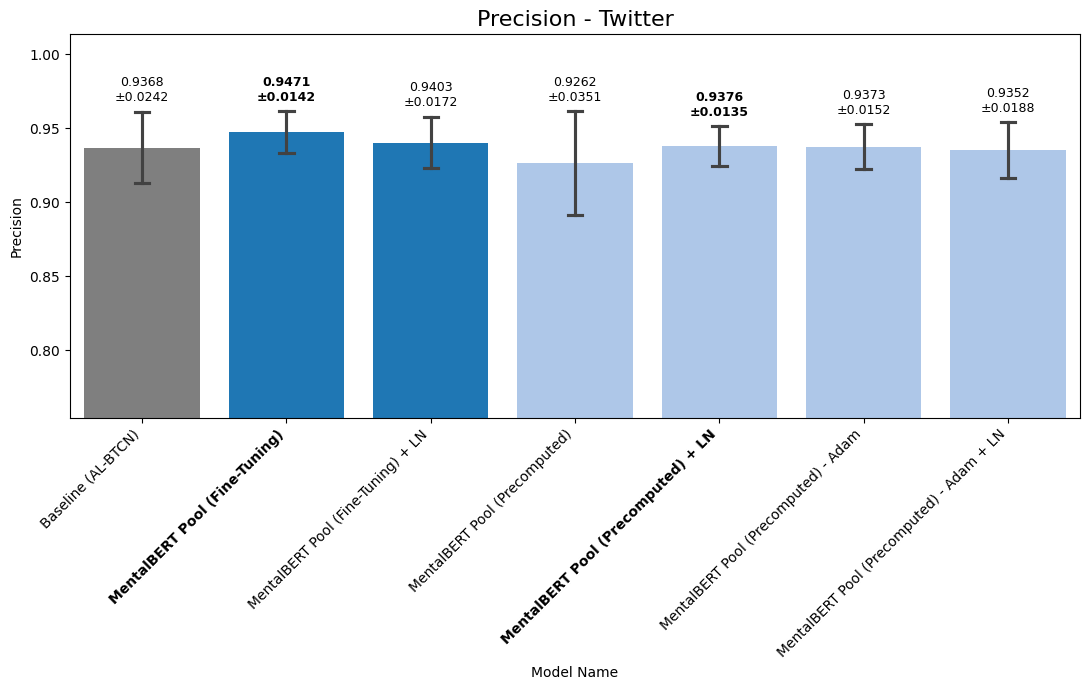

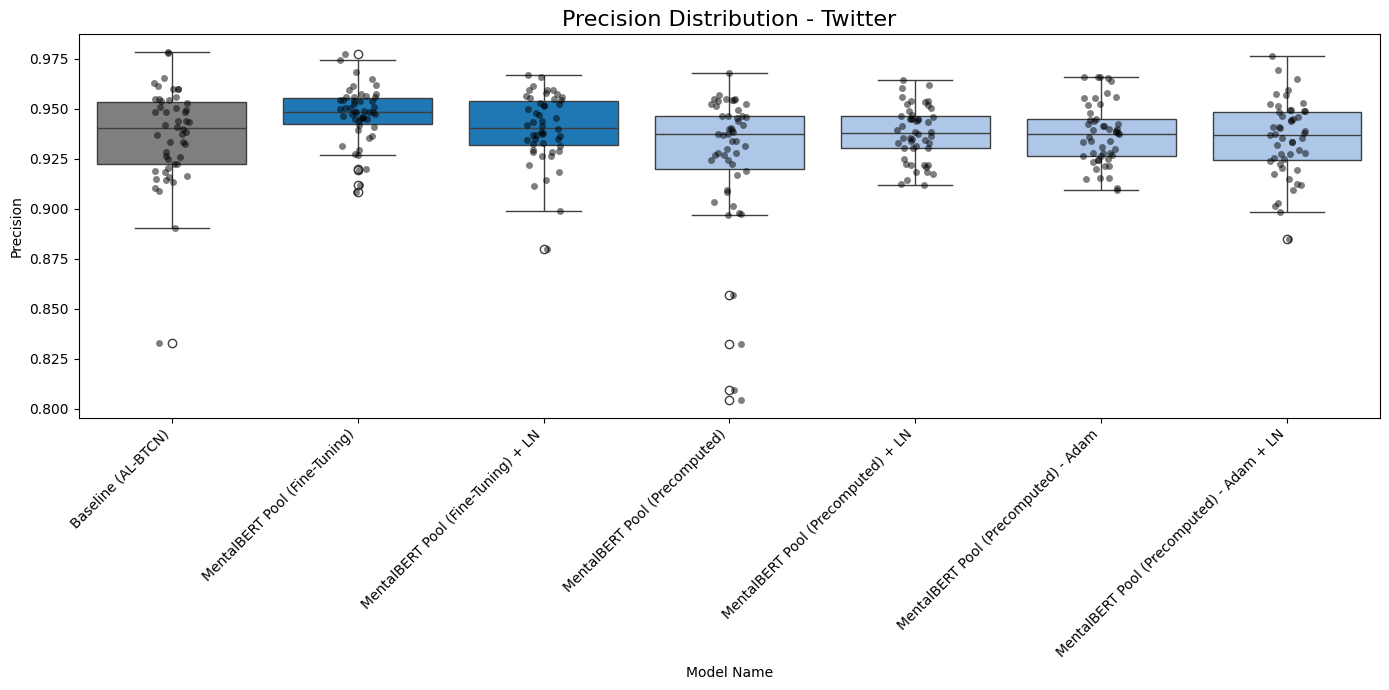

=== Recall ===
--- Reddit ---


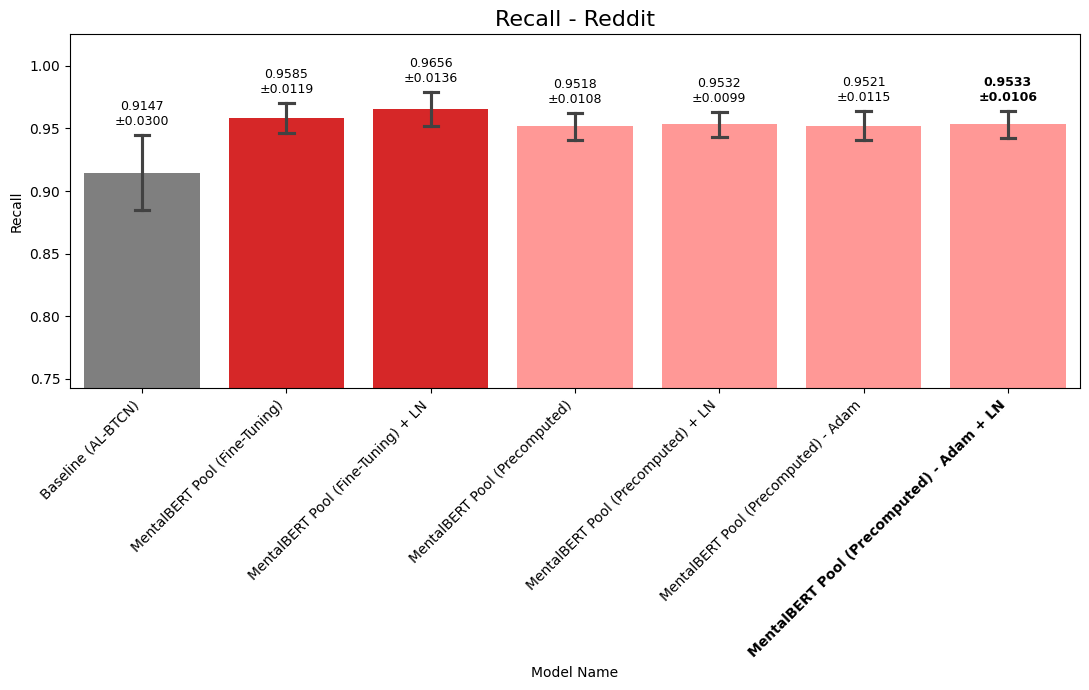

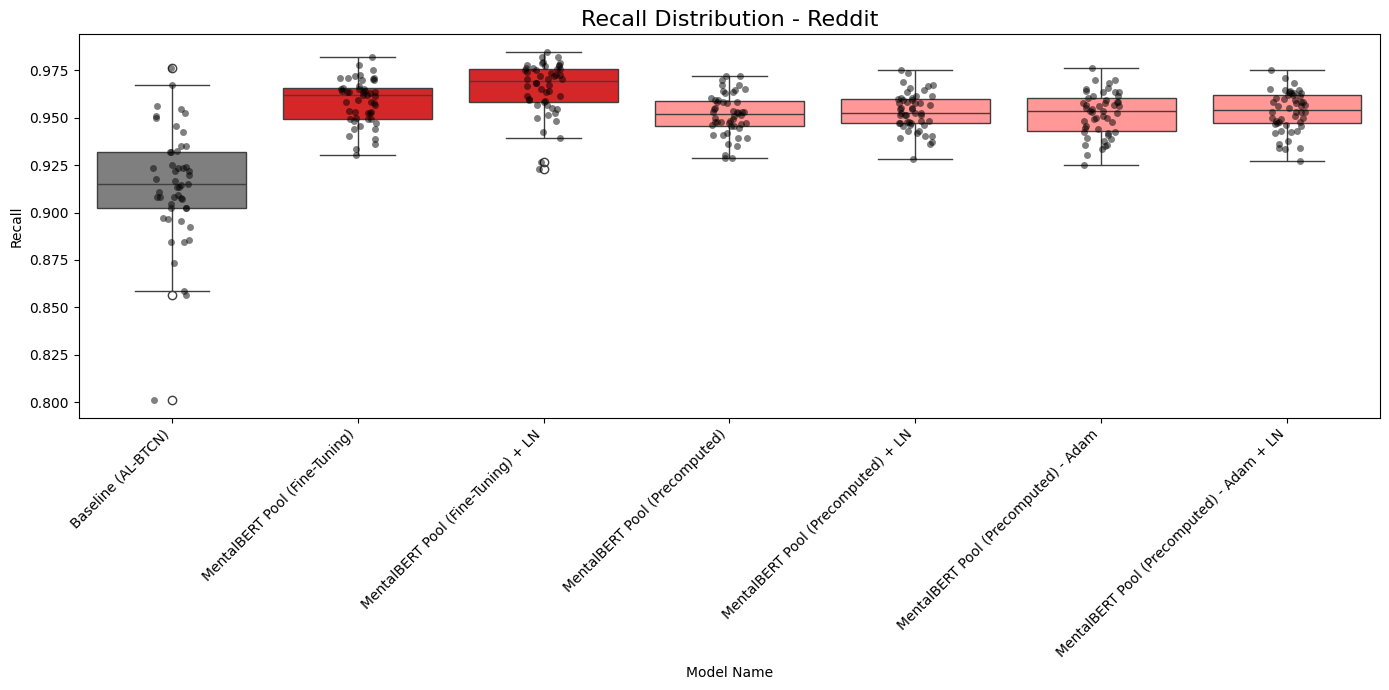

--- Twitter ---


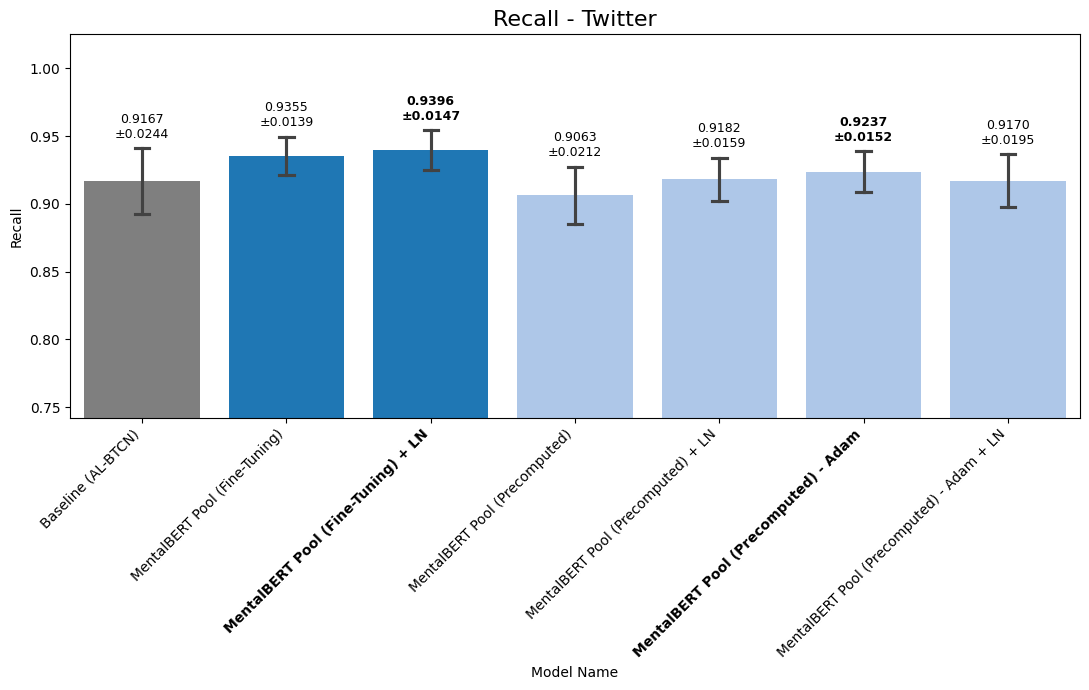

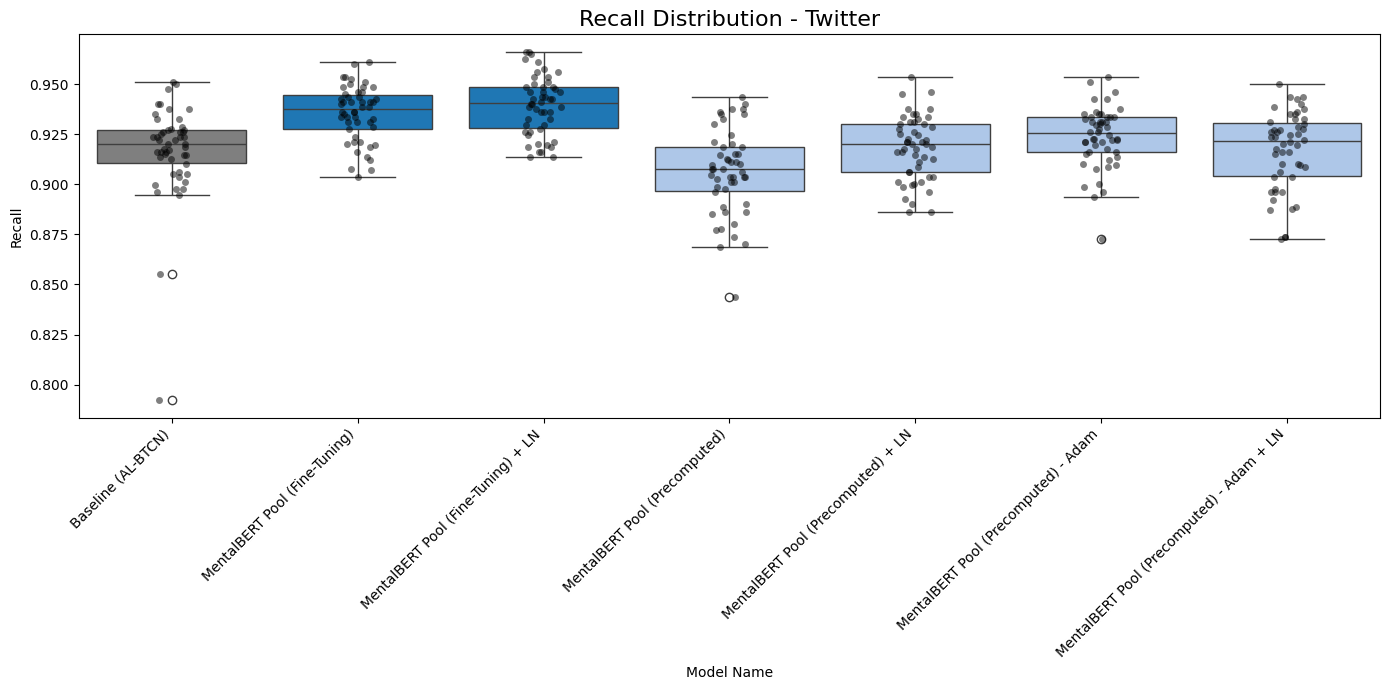

=== F1-Score ===
--- Reddit ---


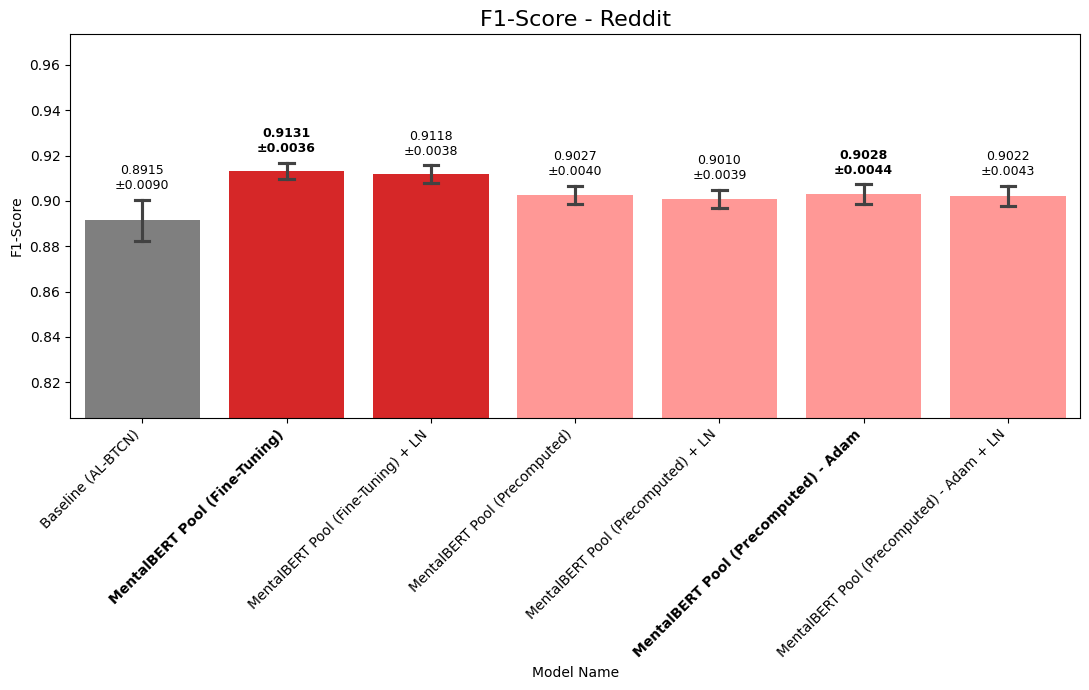

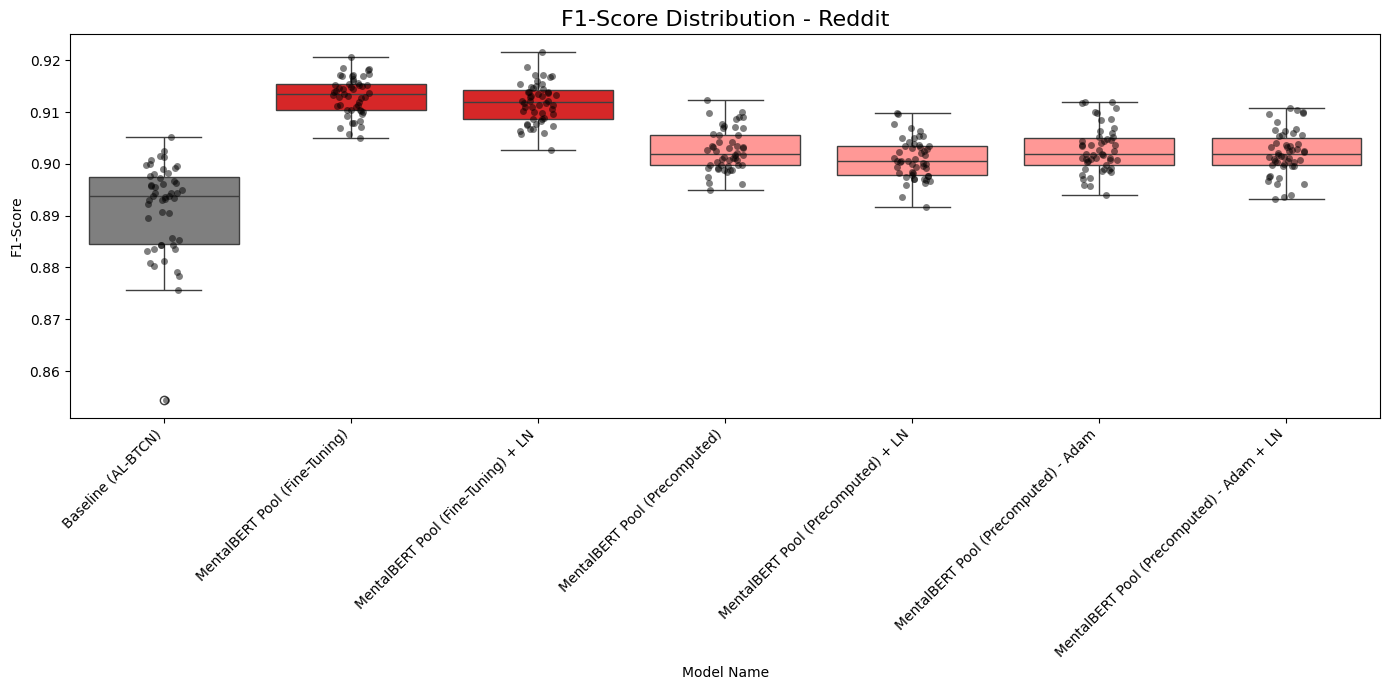

--- Twitter ---


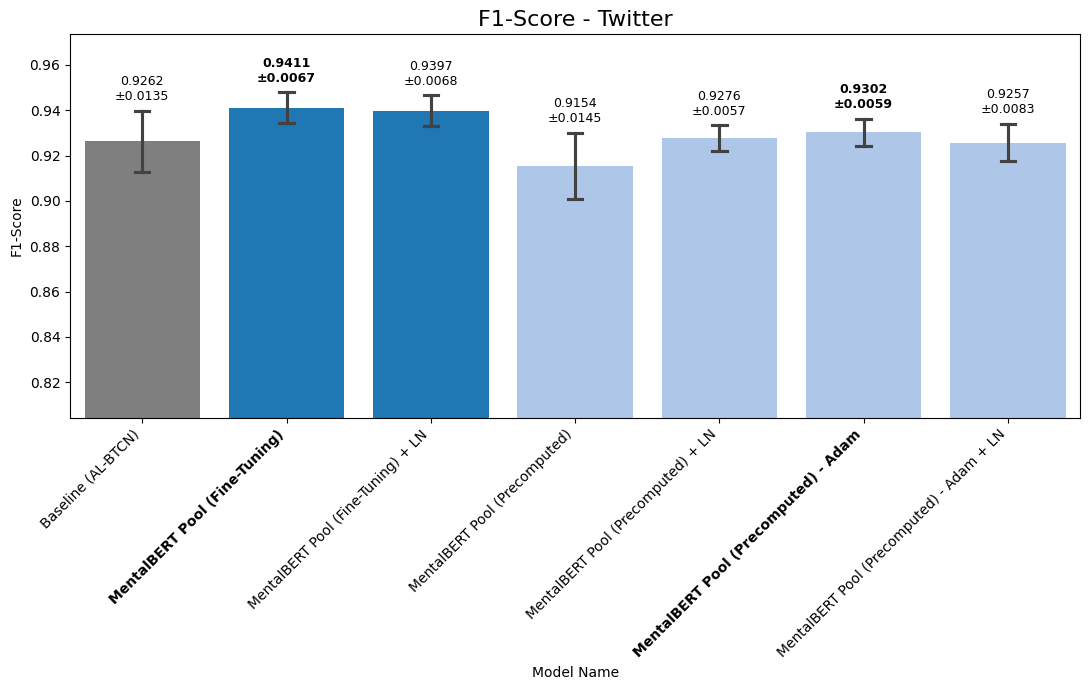

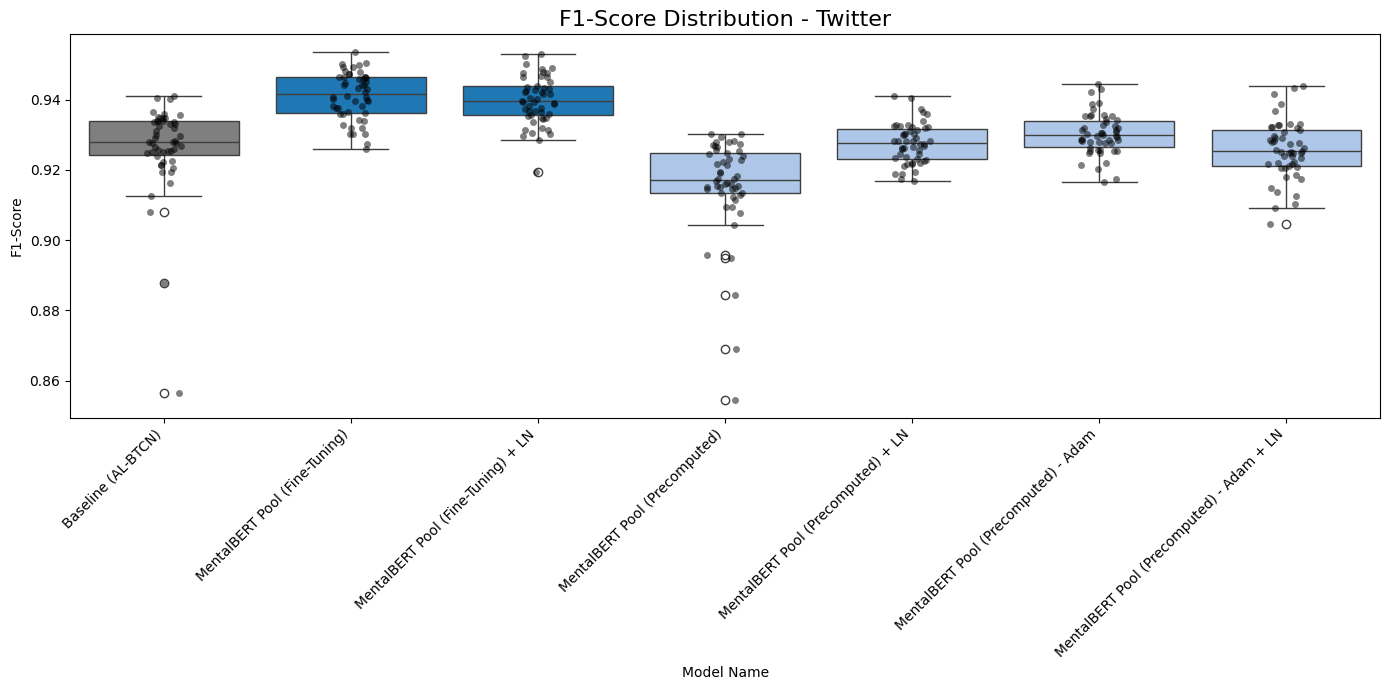

=== Training Time (s) ===
--- Reddit ---


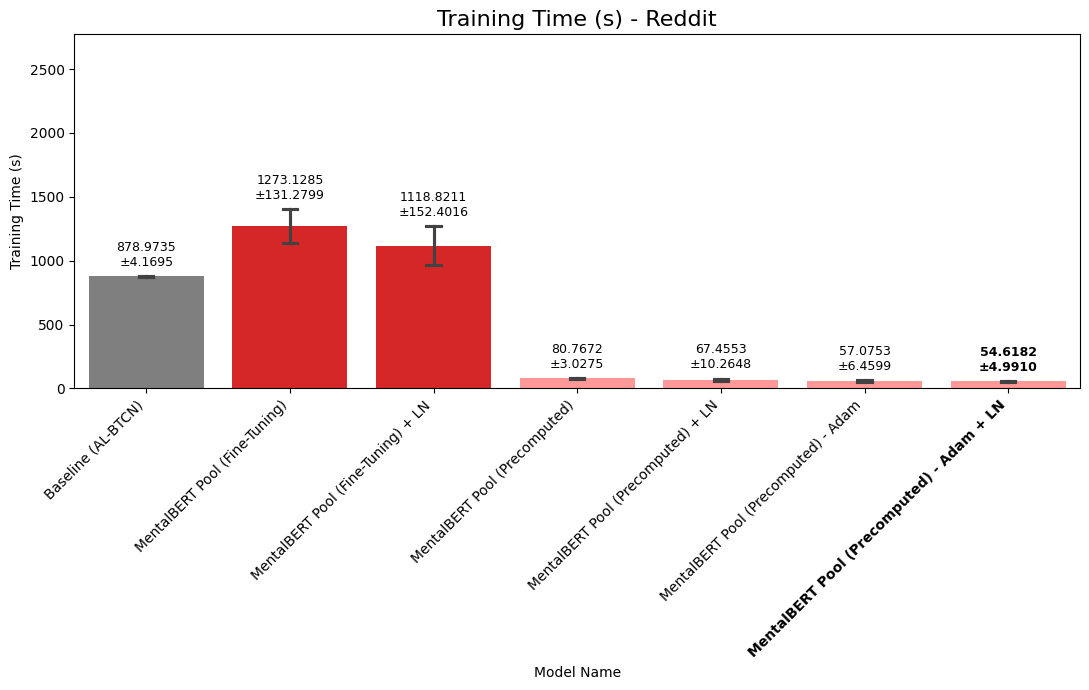

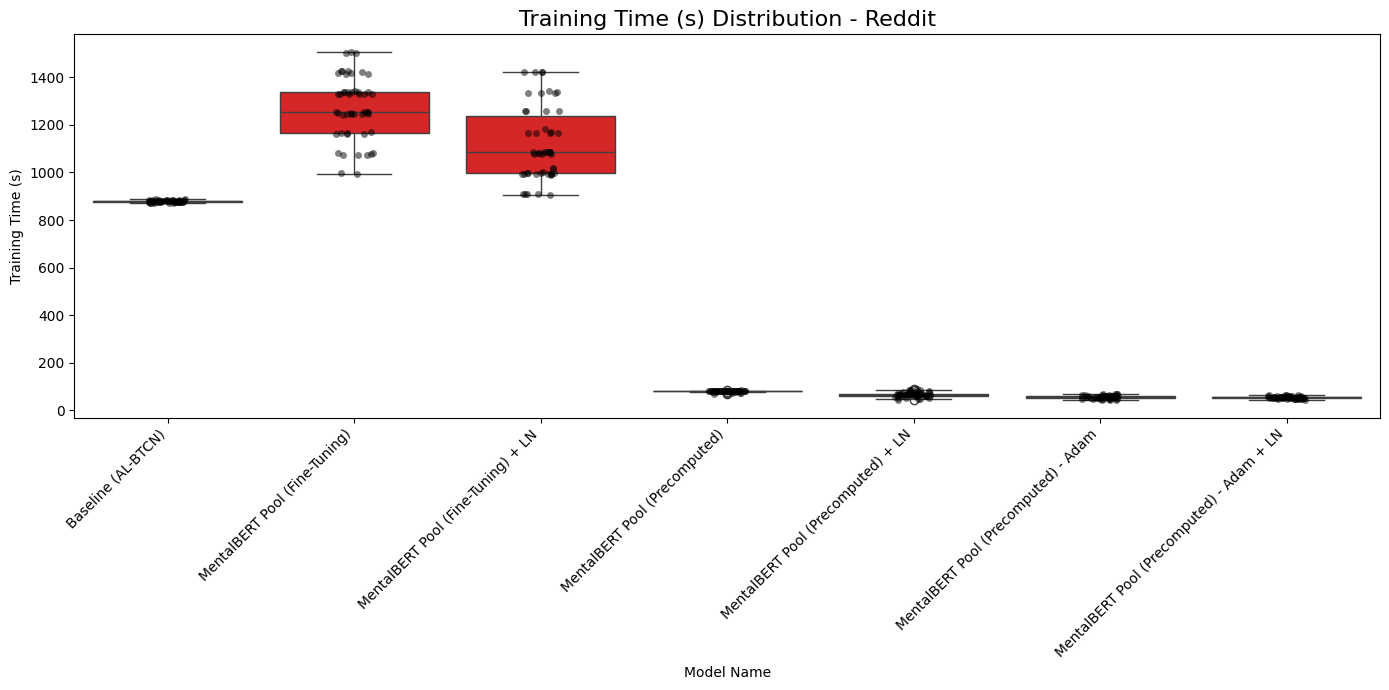

--- Twitter ---


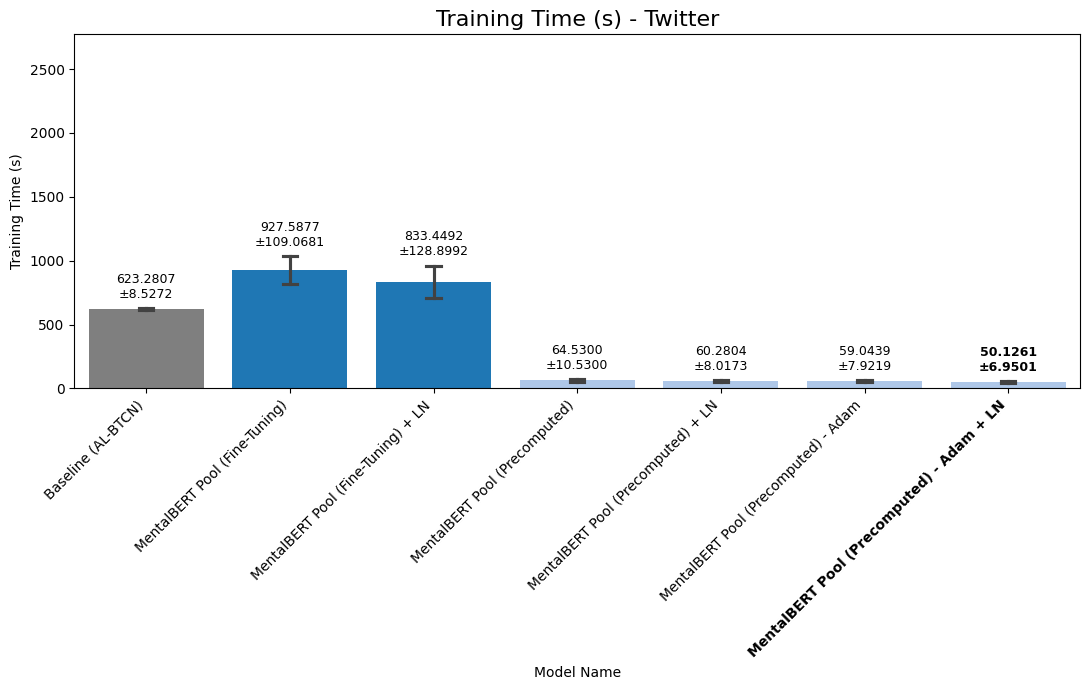

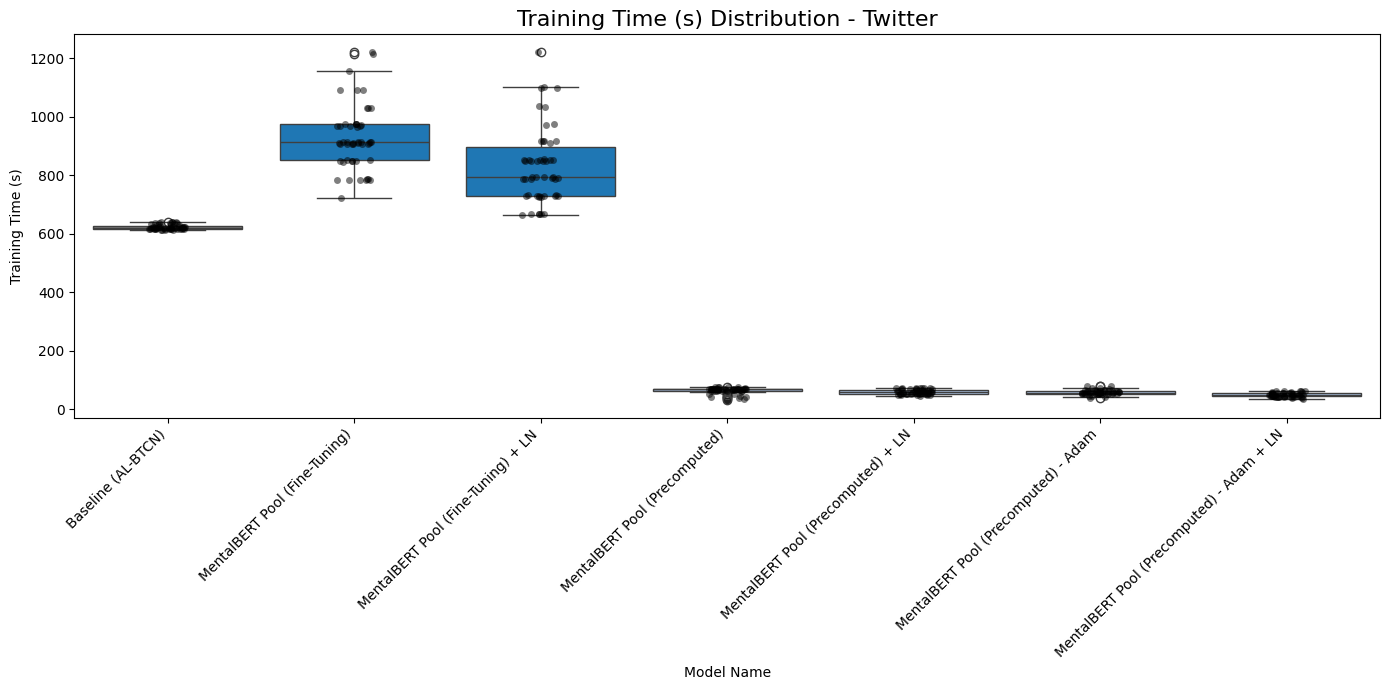

=== Max GPU Memory (MB) ===
--- Reddit ---


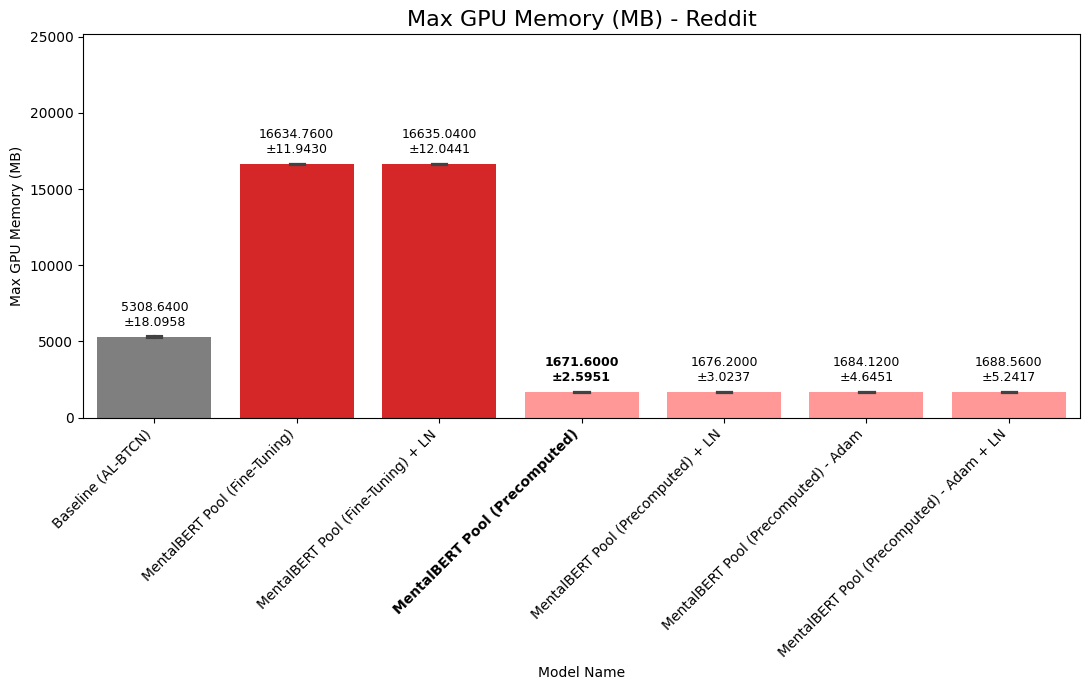

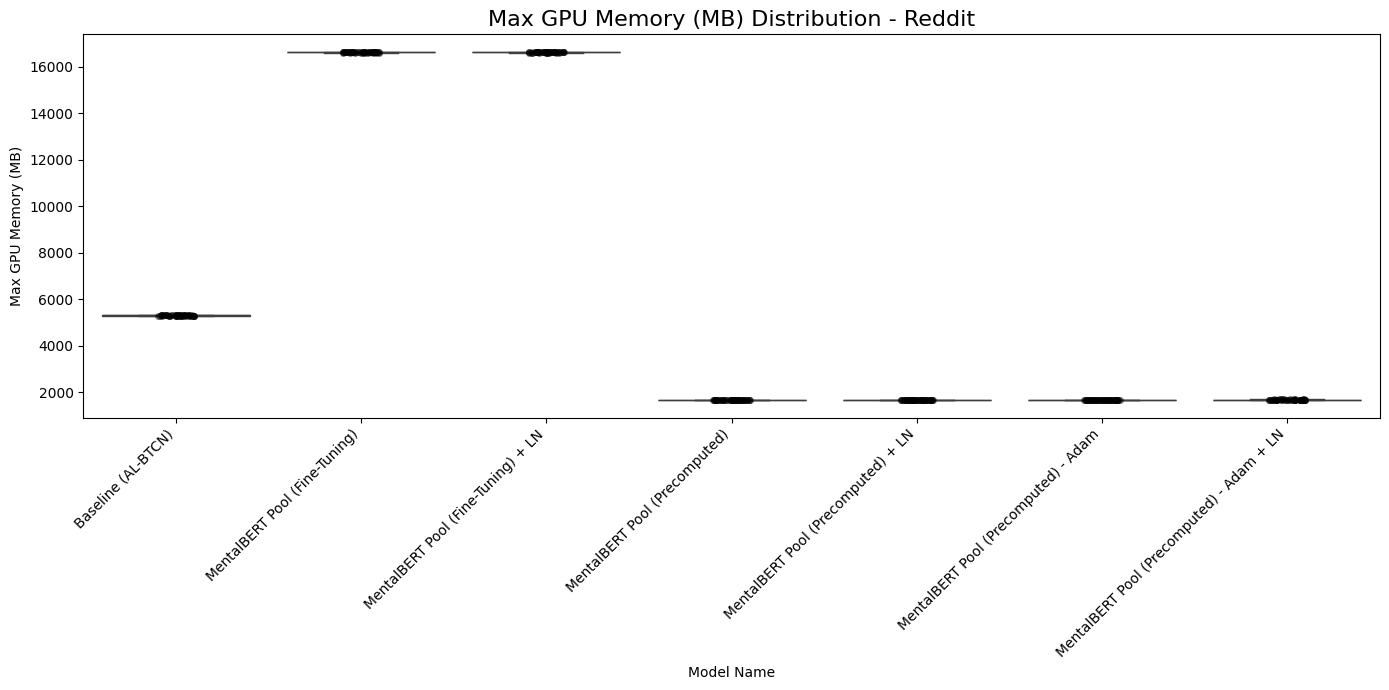

--- Twitter ---


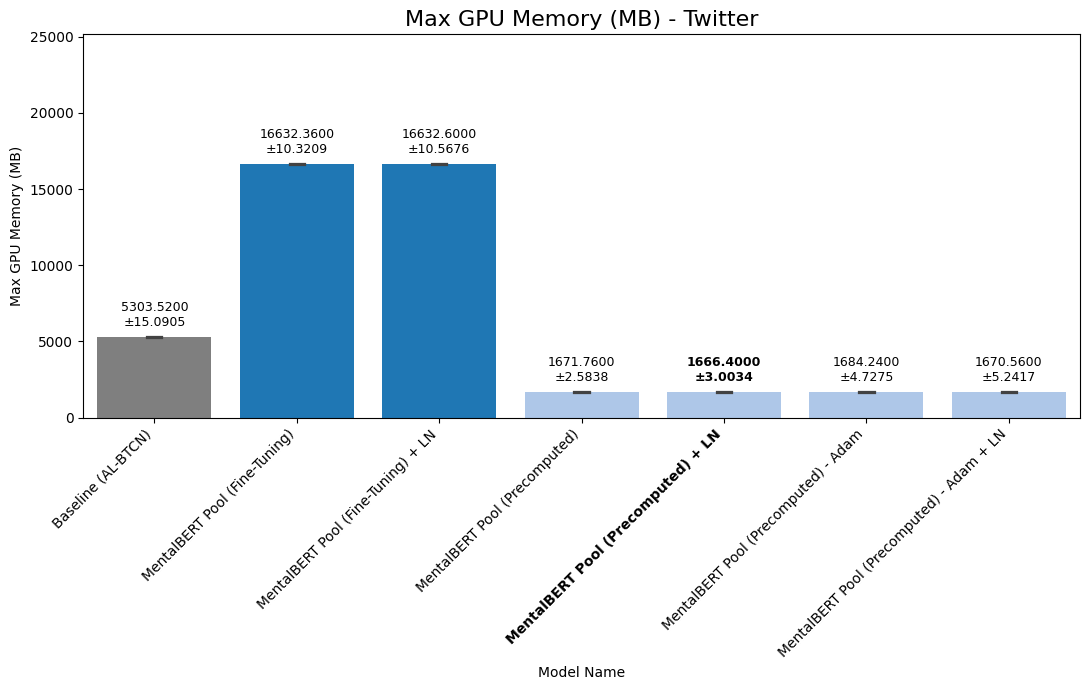

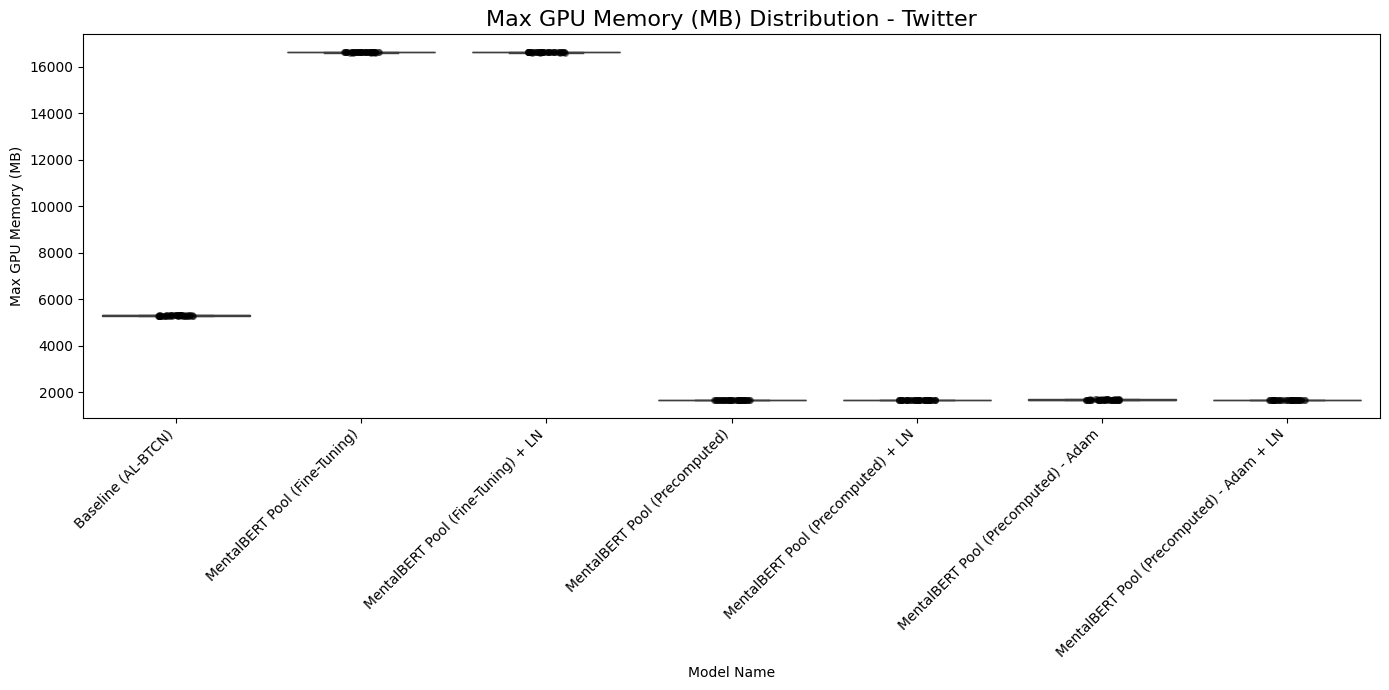

=== Avg GPU Memory (MB) ===
--- Reddit ---


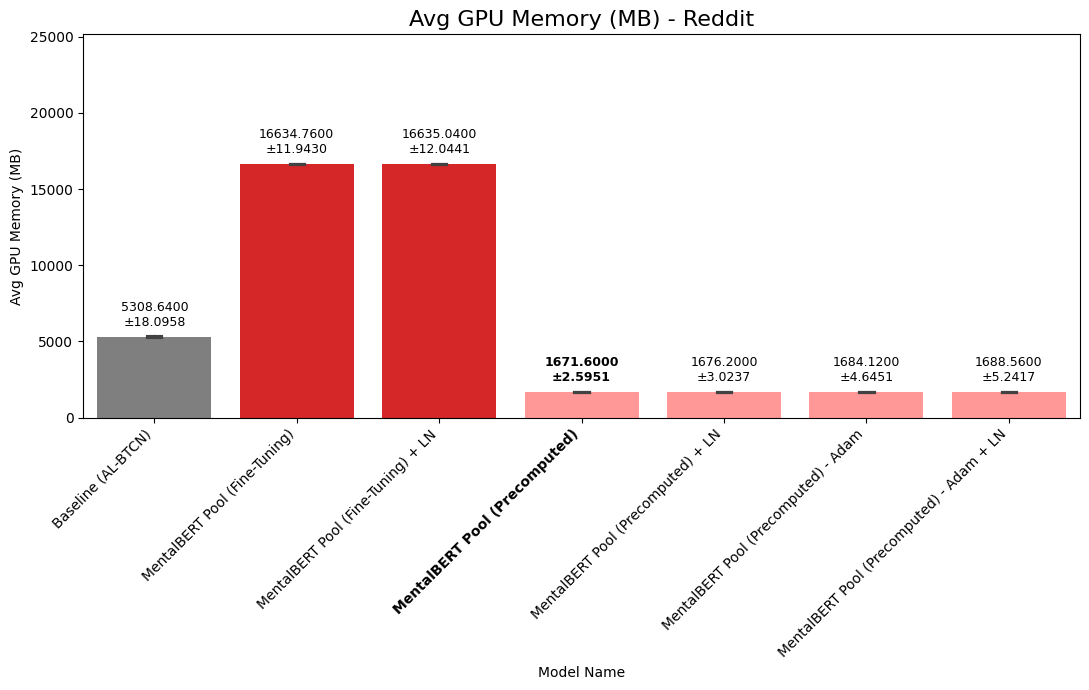

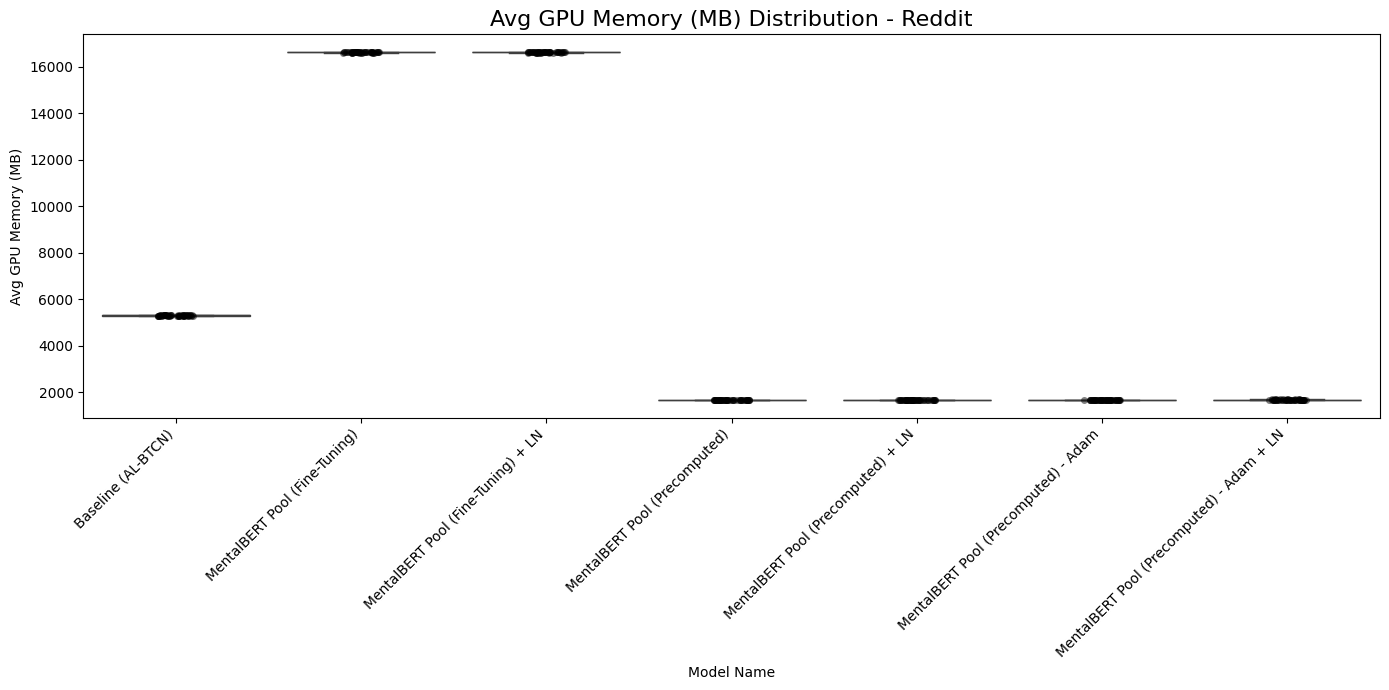

--- Twitter ---


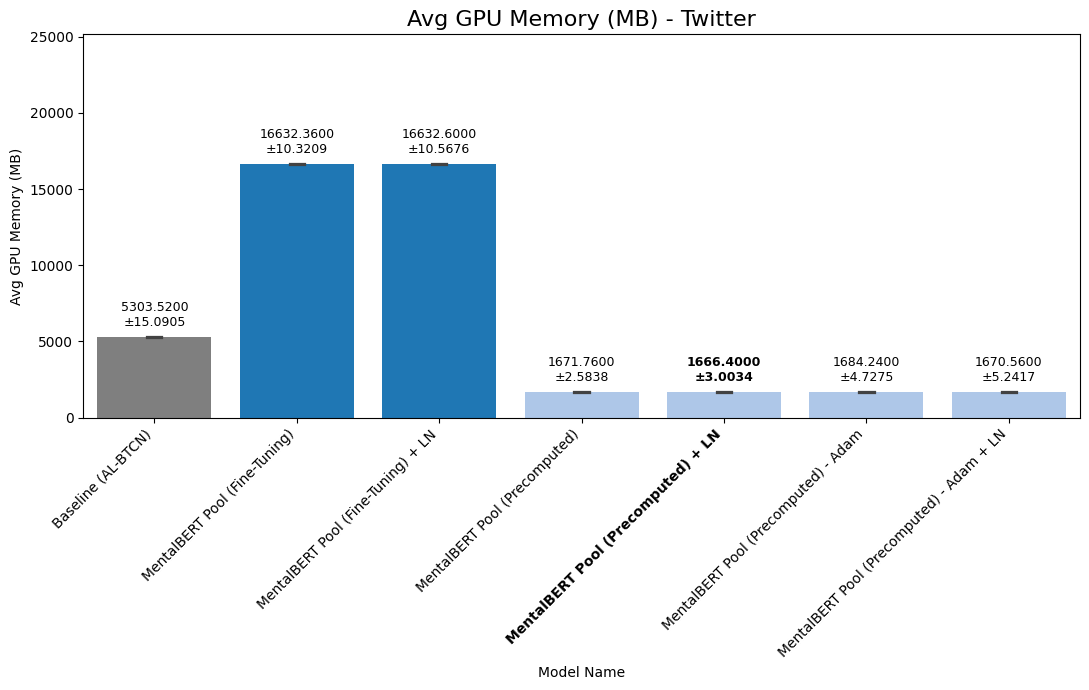

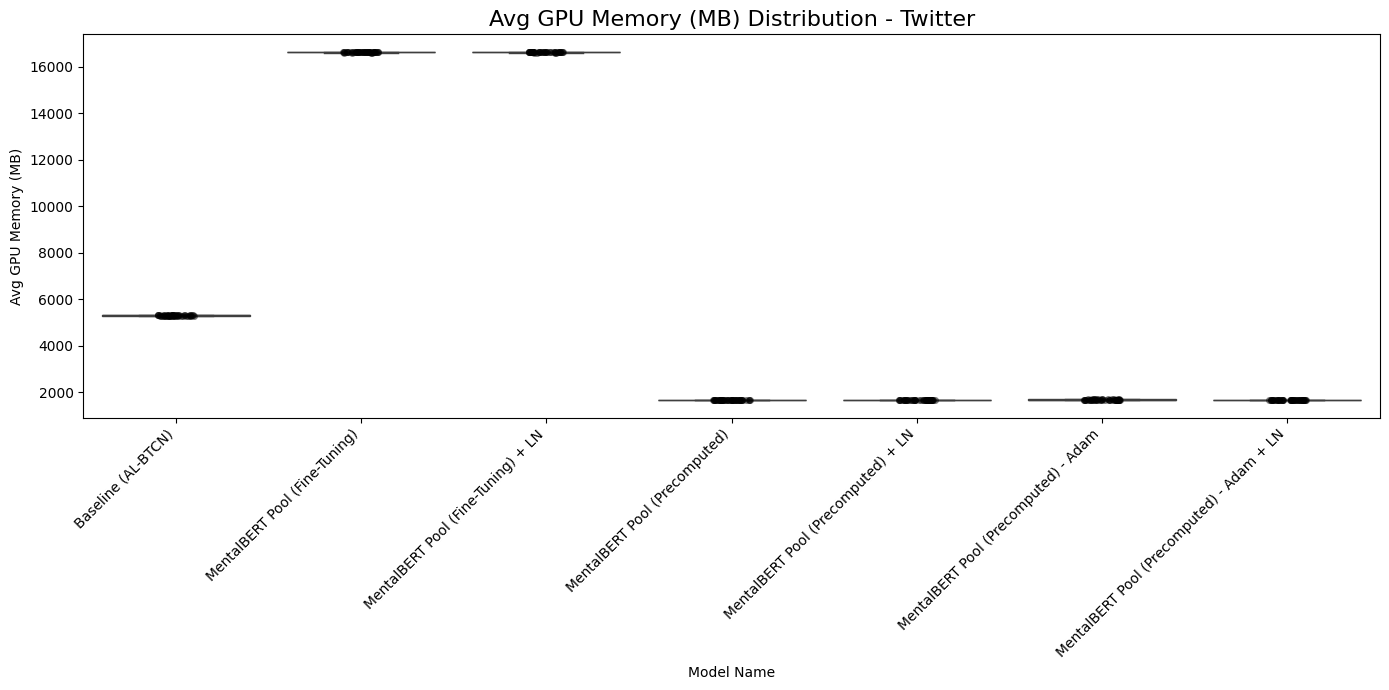

=== Epochs Run ===
--- Reddit ---


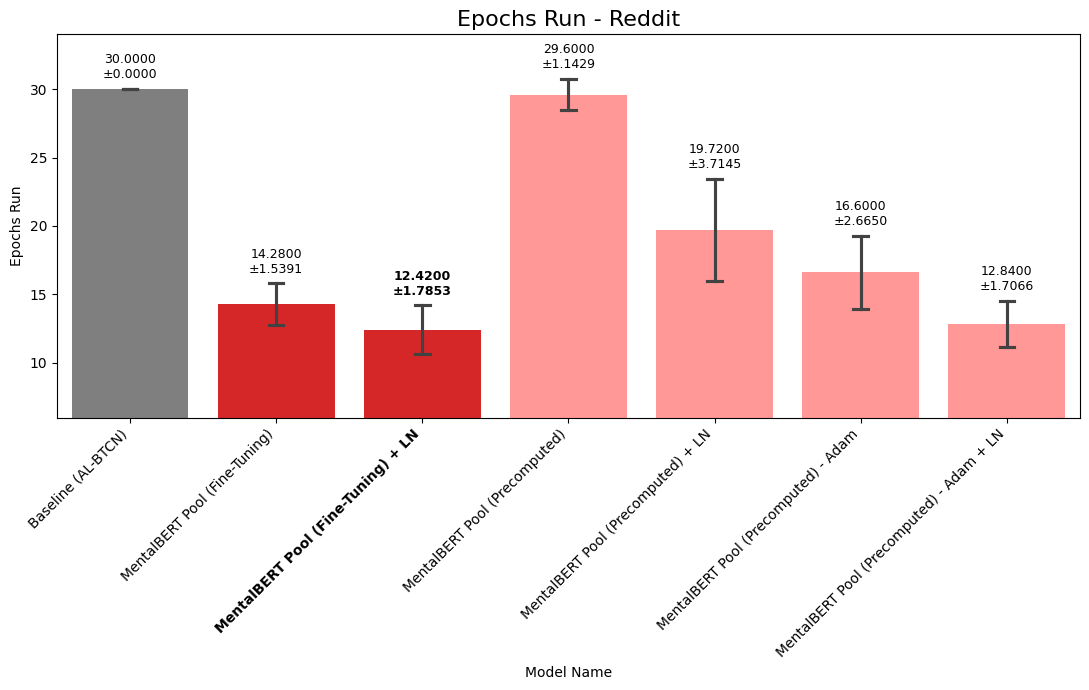

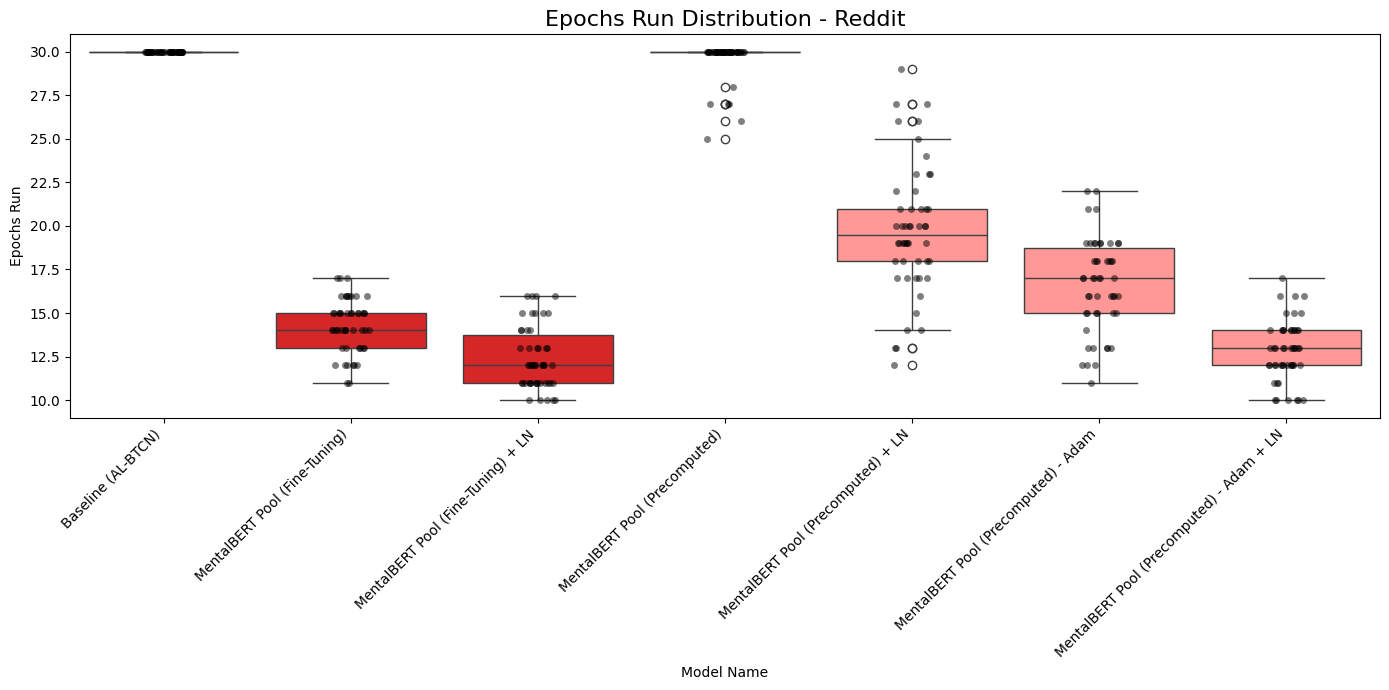

--- Twitter ---


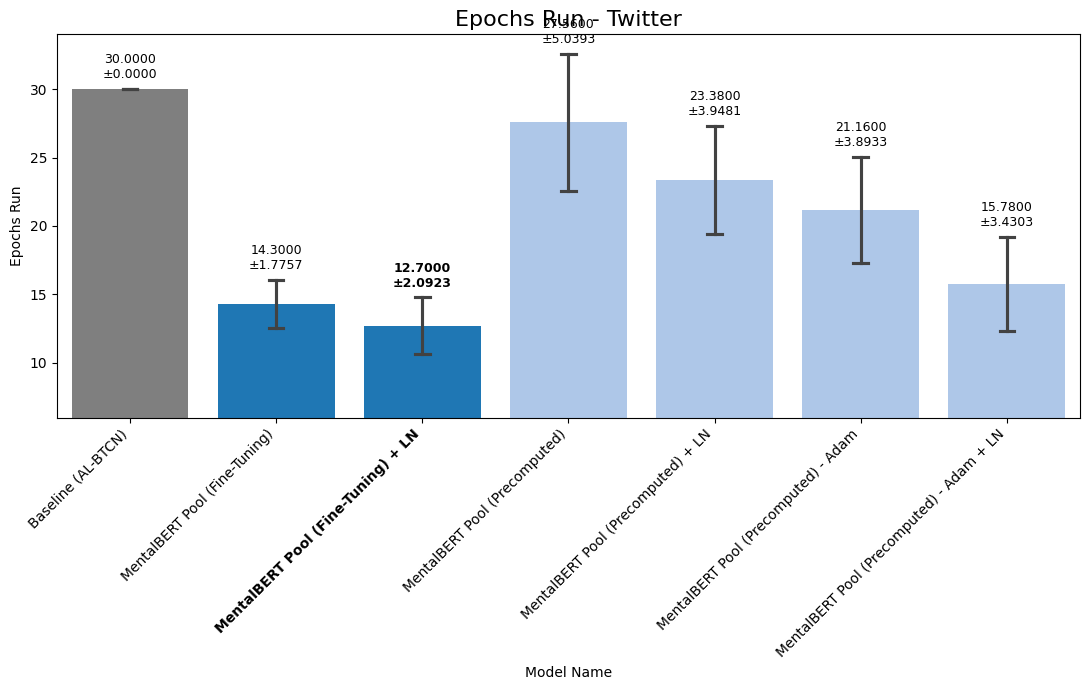

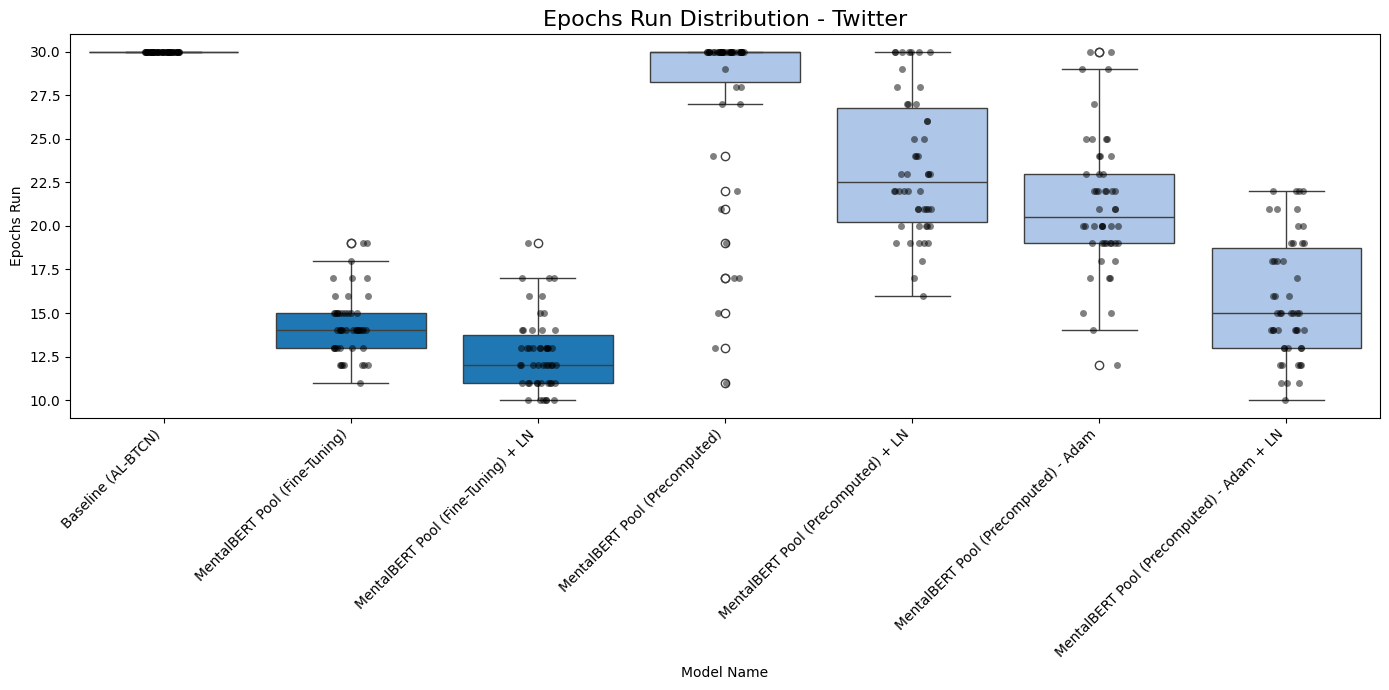

=== Avg Time/Epoch (s) ===
--- Reddit ---


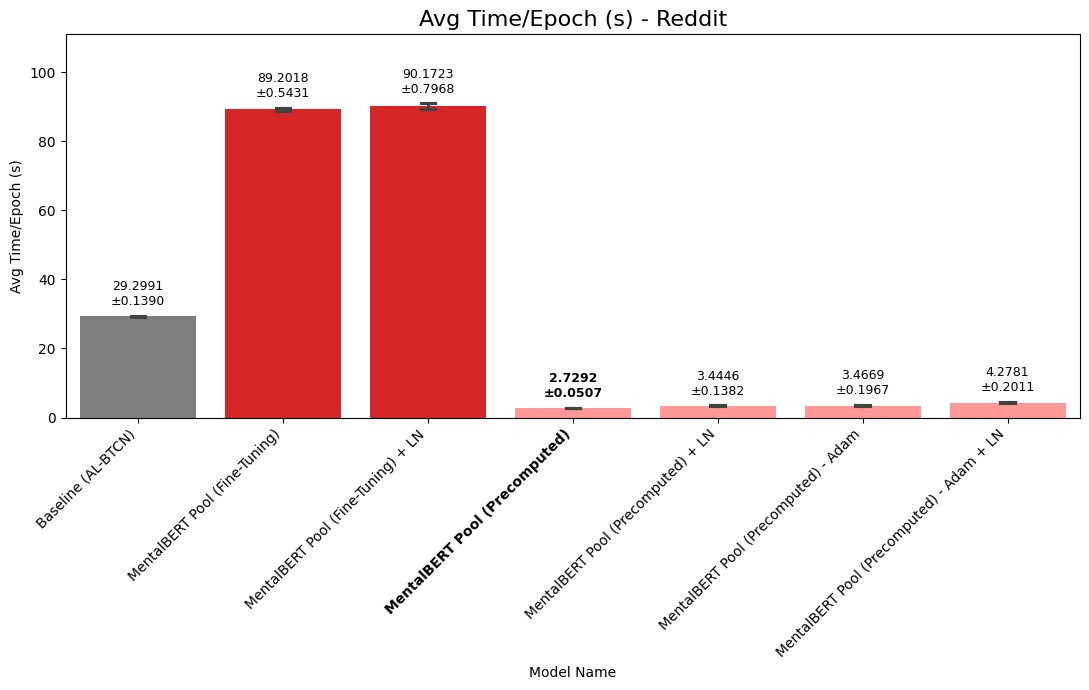

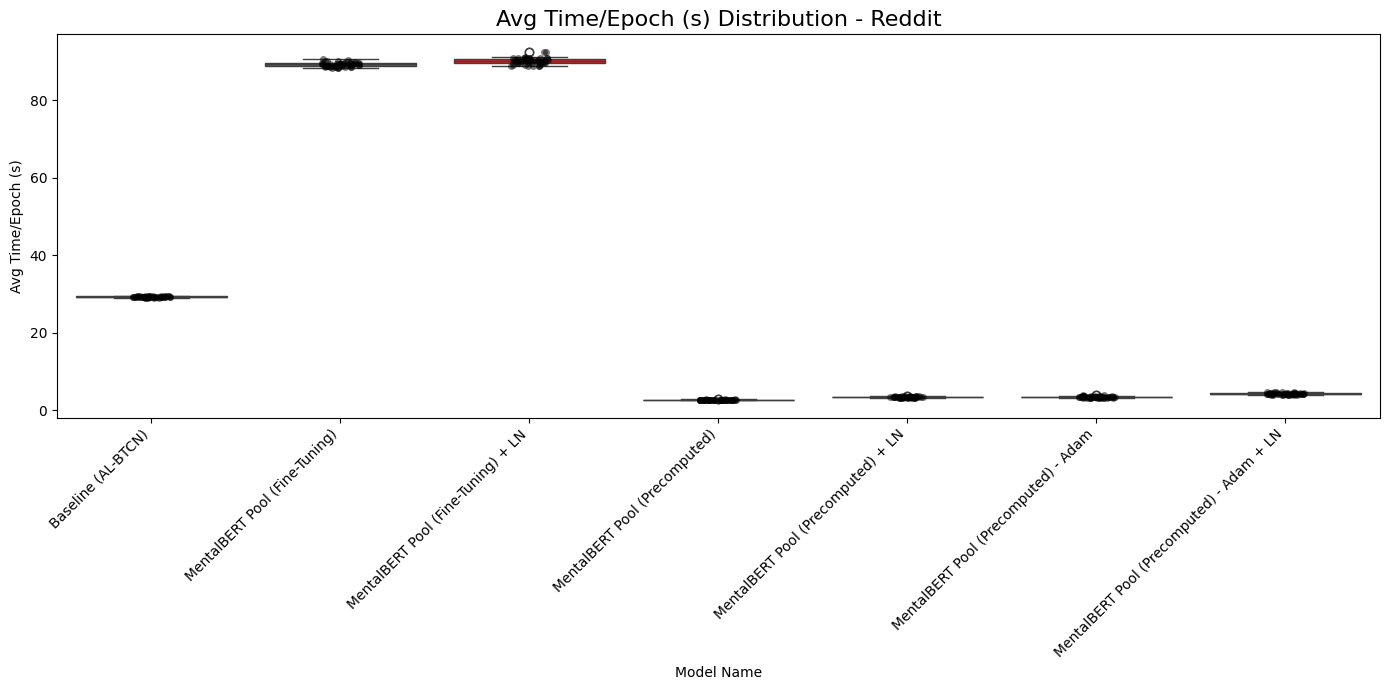

--- Twitter ---


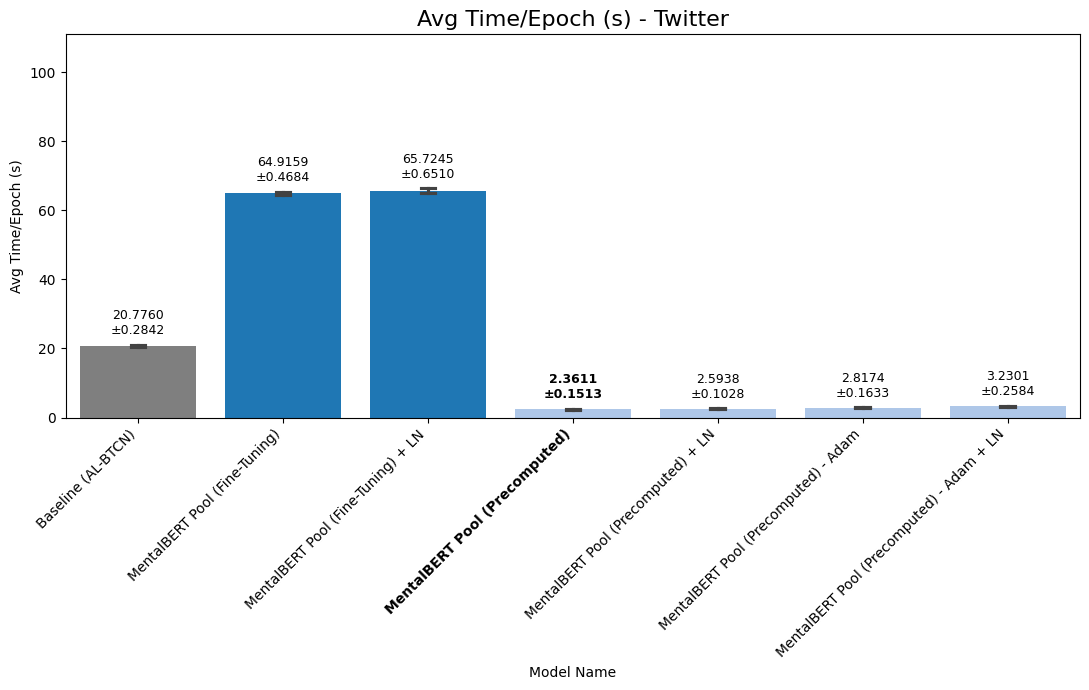

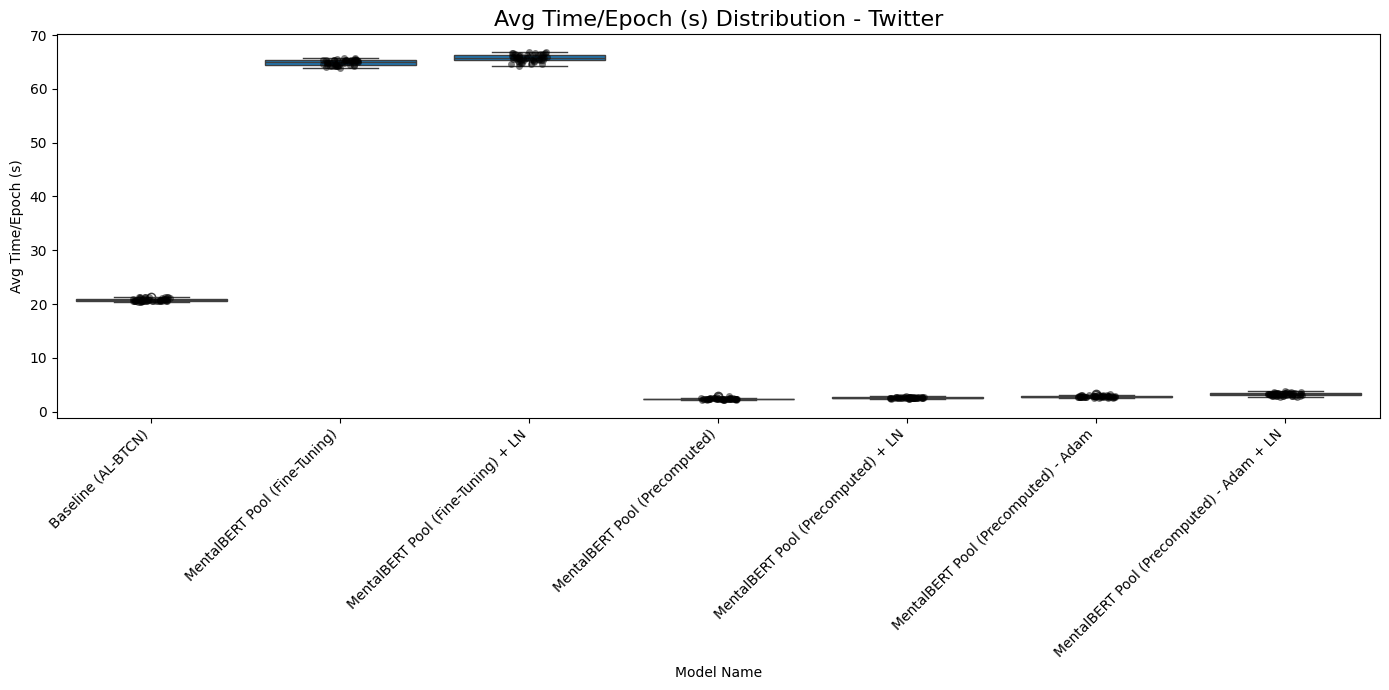

In [6]:
# Generate Plots
for metric in metrics_to_plot:
    print(f"=== {metric} ===")
    for dataset in datasets:
        print(f"--- {dataset} ---")
        # Bar Chart
        plot_barchart_dataset(full_df_v2, dataset, metric, order=model_order_v2)
        # Box Plot
        plot_boxplot_comparison(full_df_v2, dataset, metric, order=model_order_v2)

=== Trade-off Analysis for Reddit ===


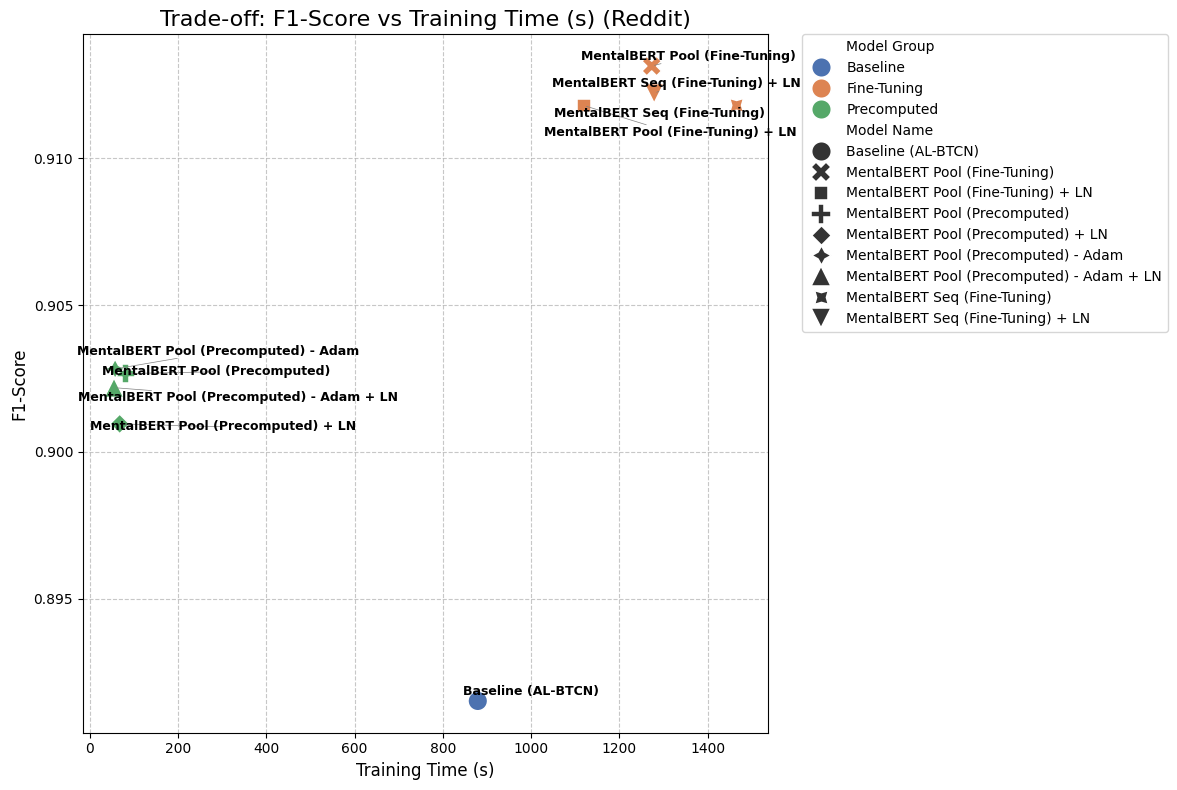

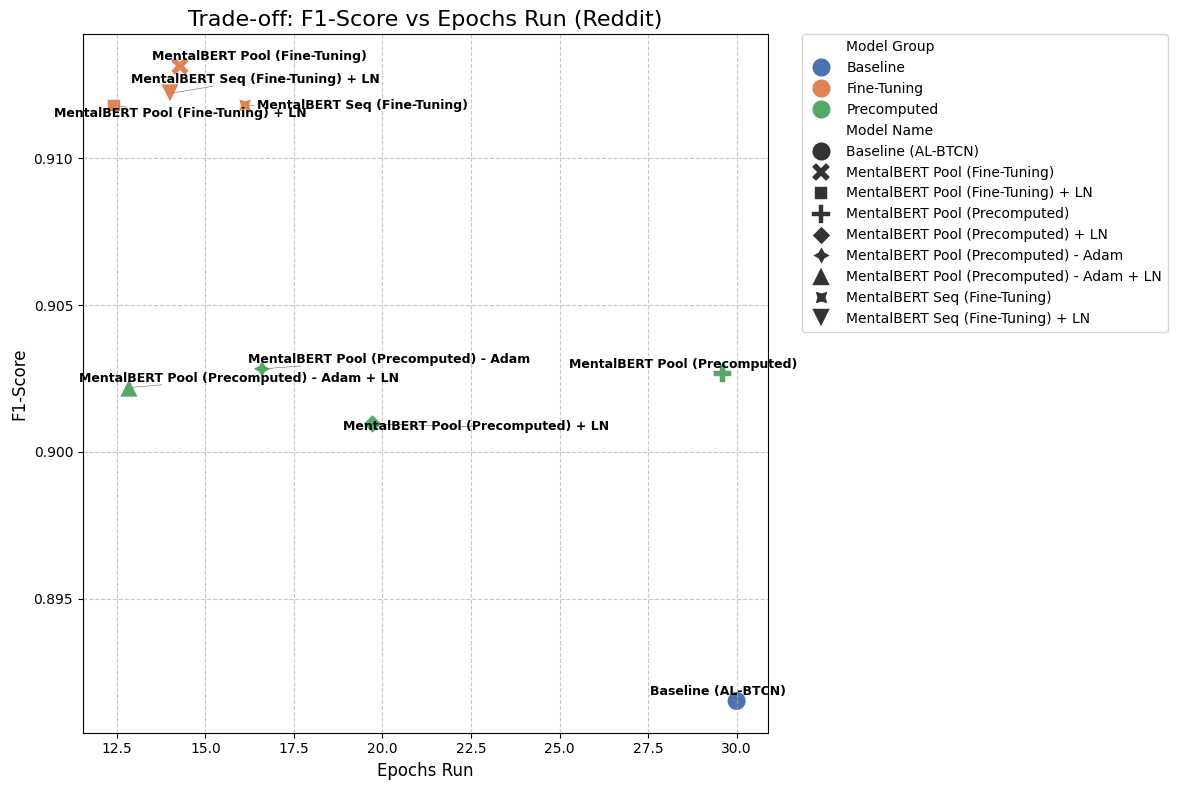

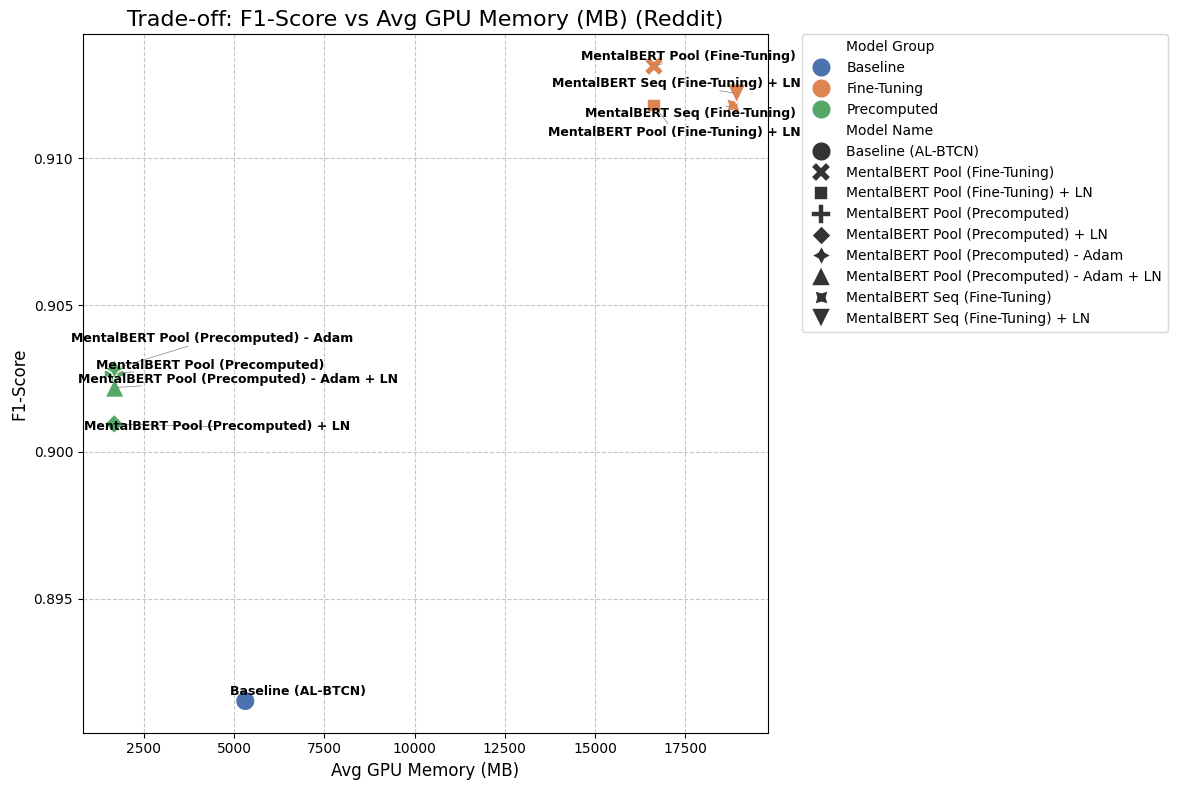

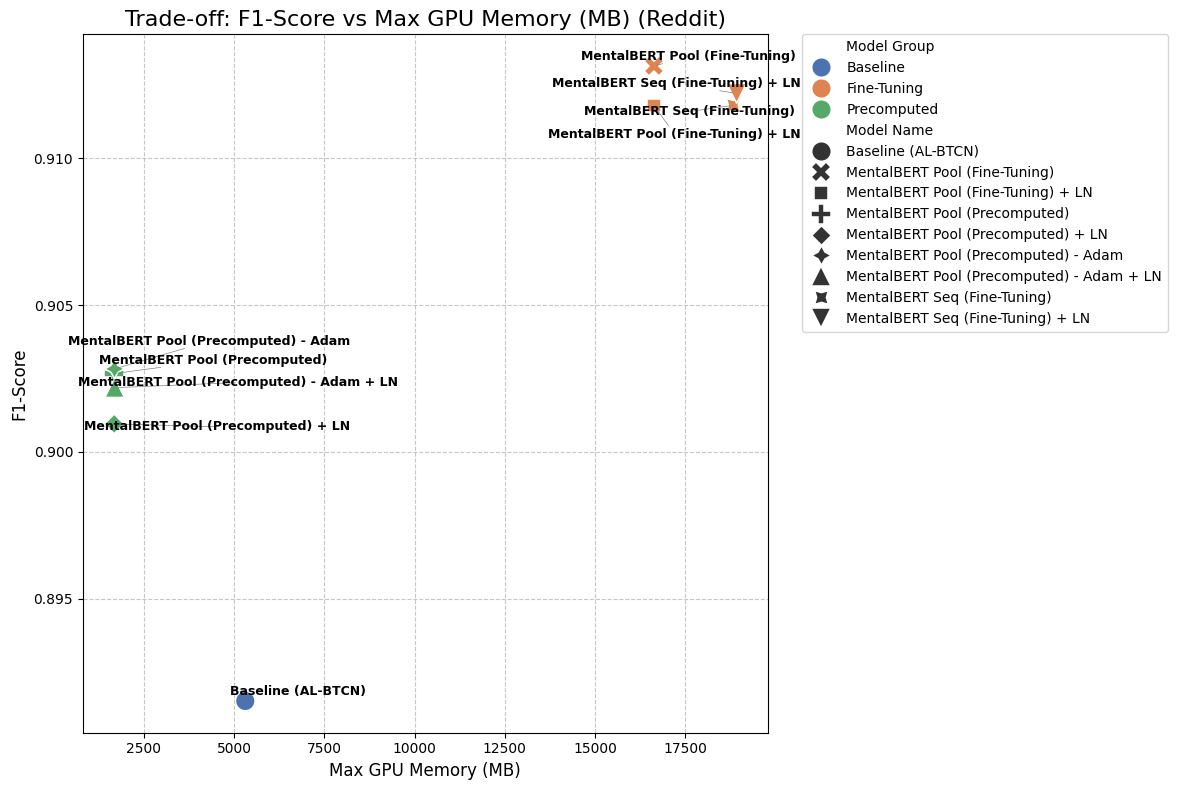

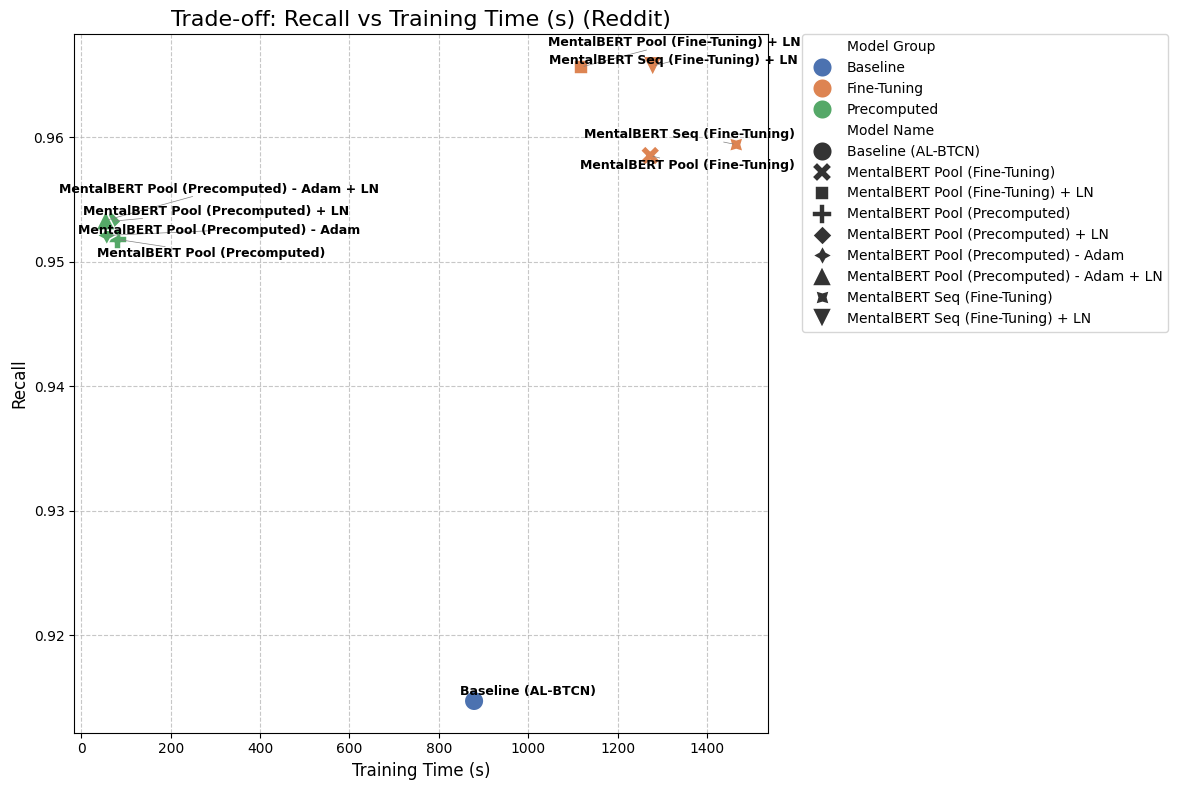

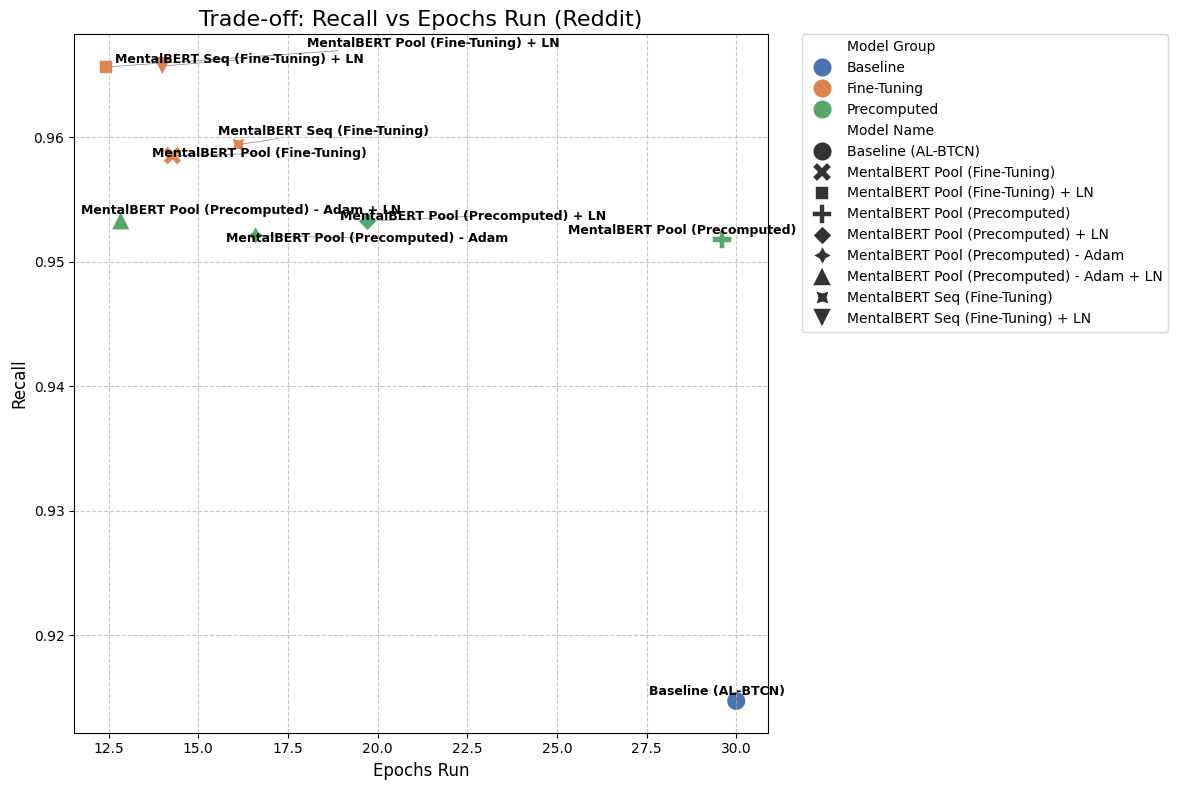

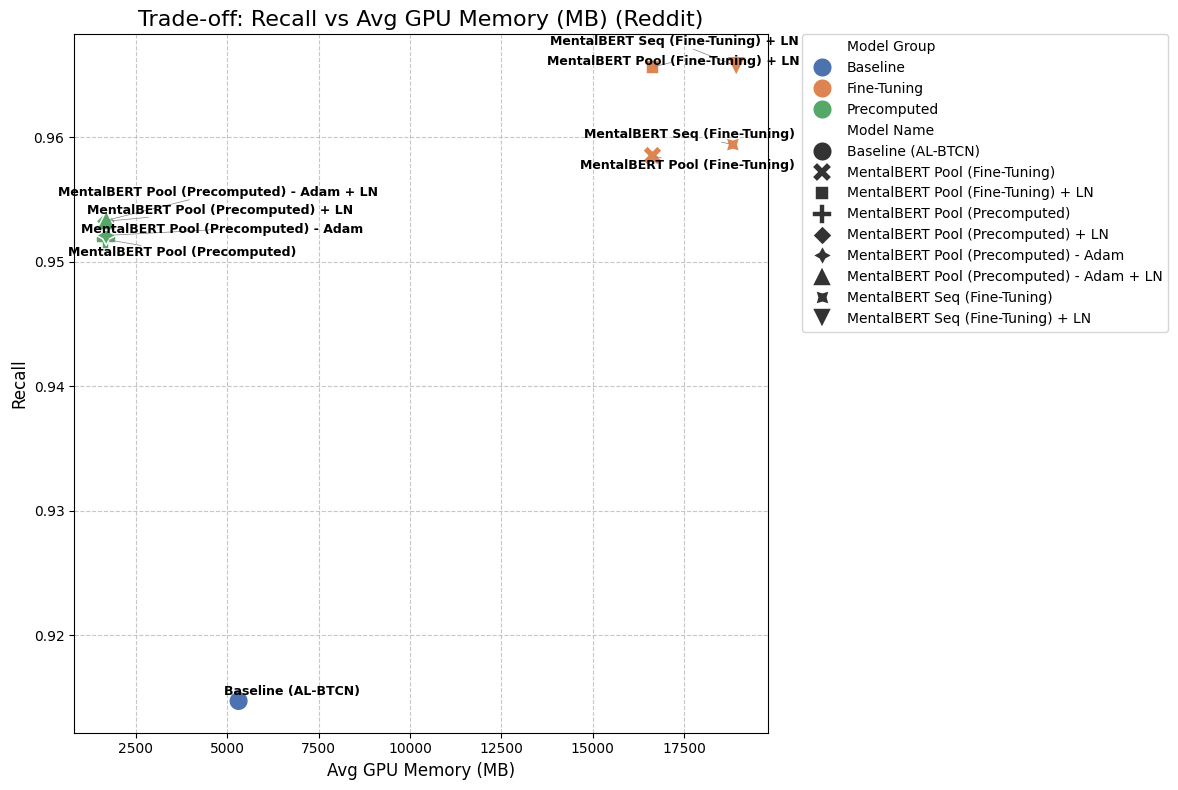

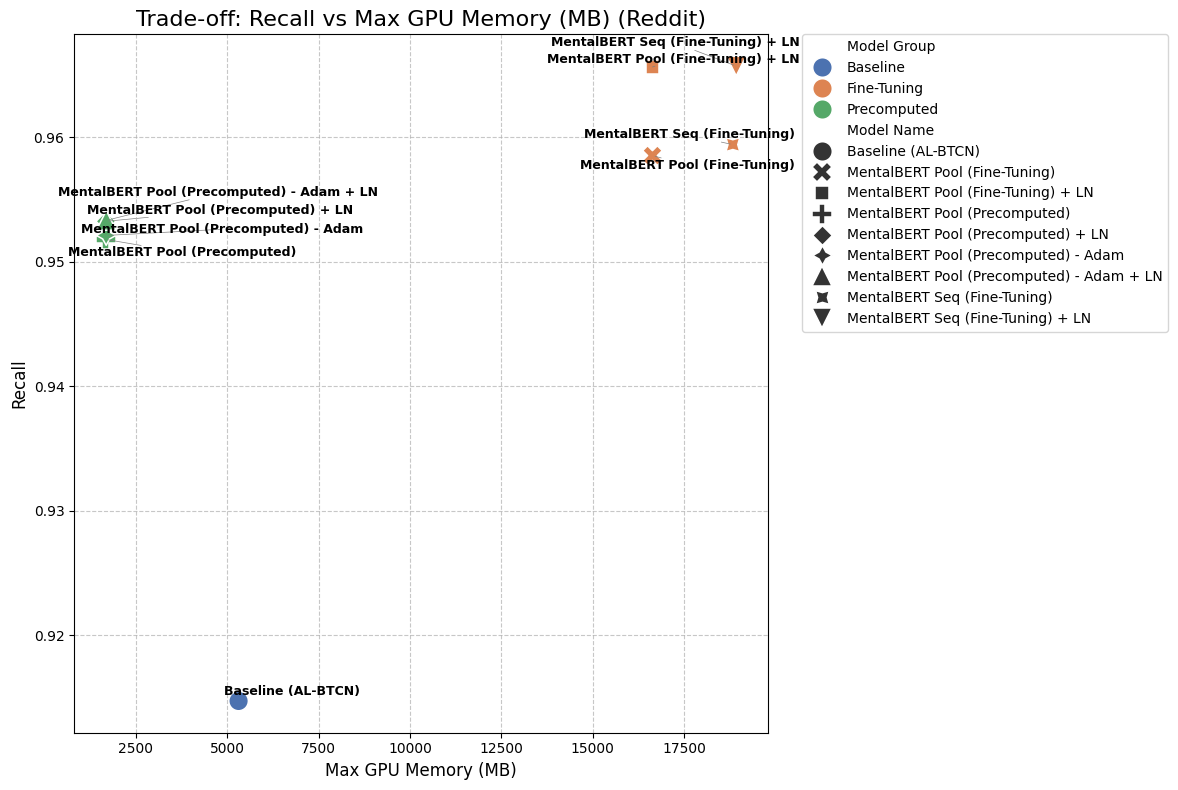

=== Trade-off Analysis for Twitter ===


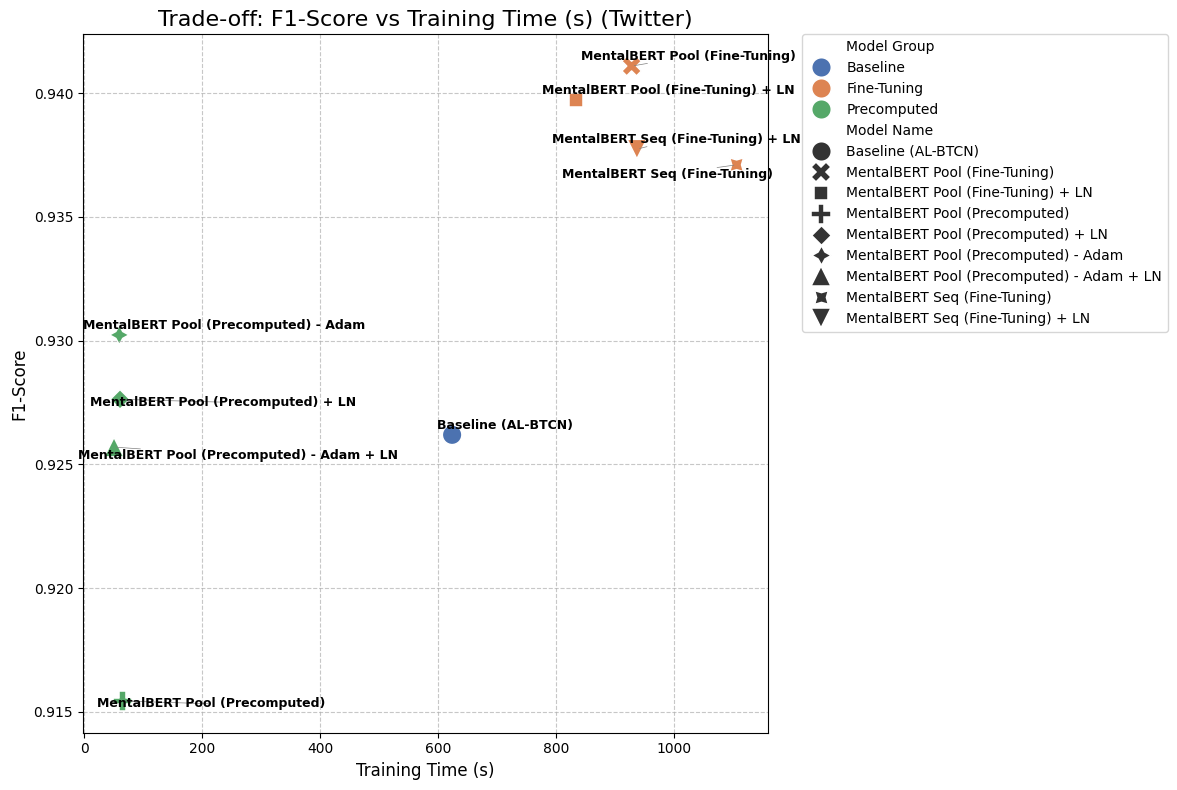

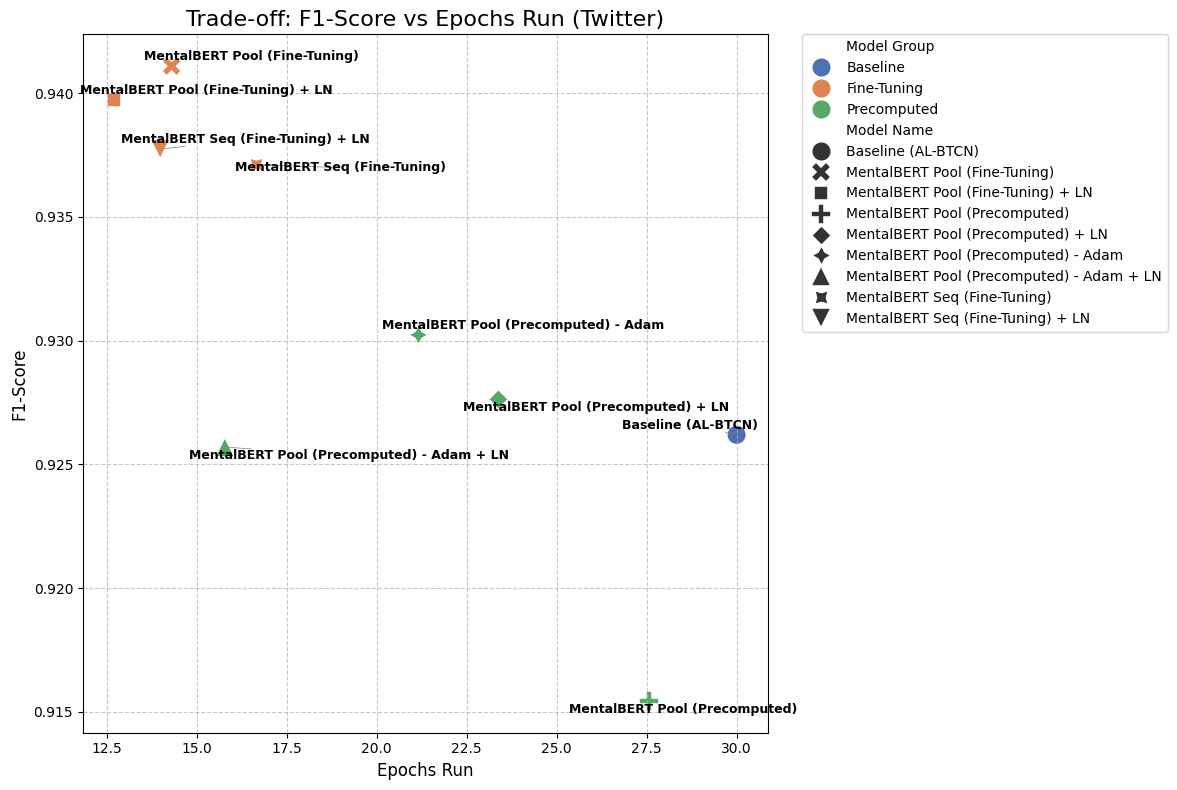

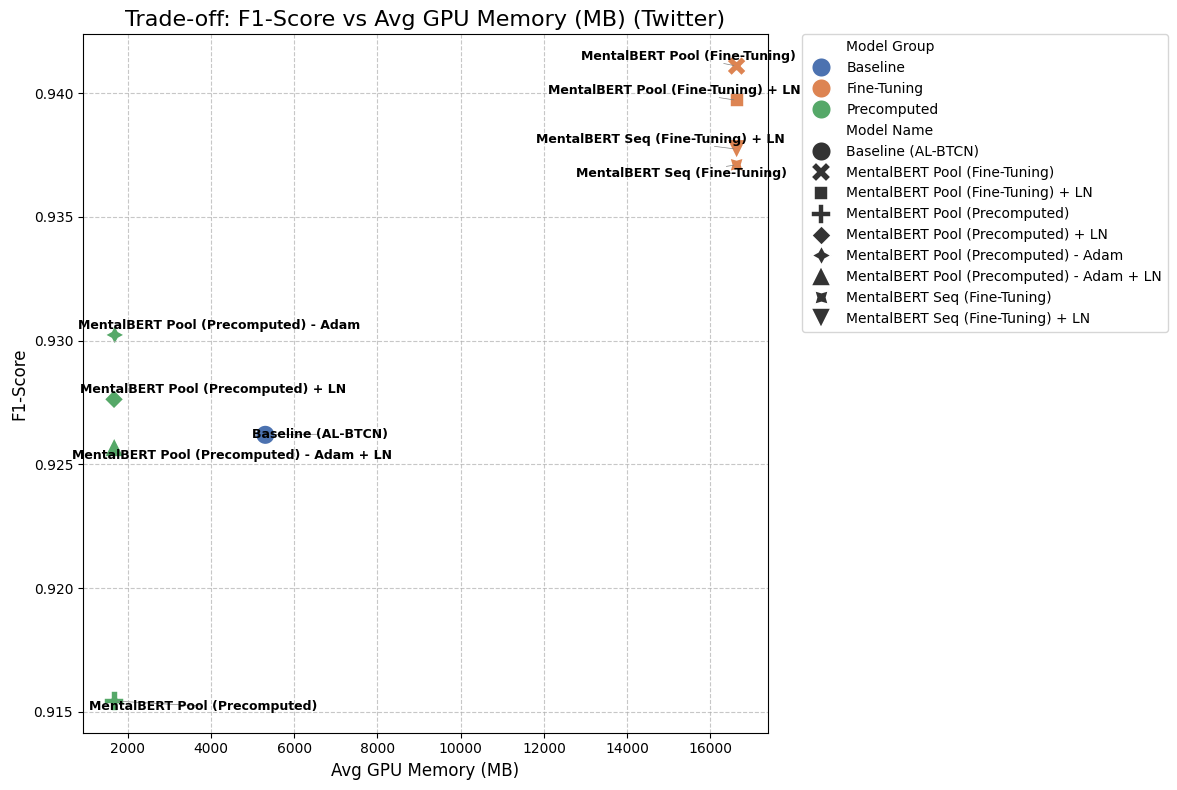

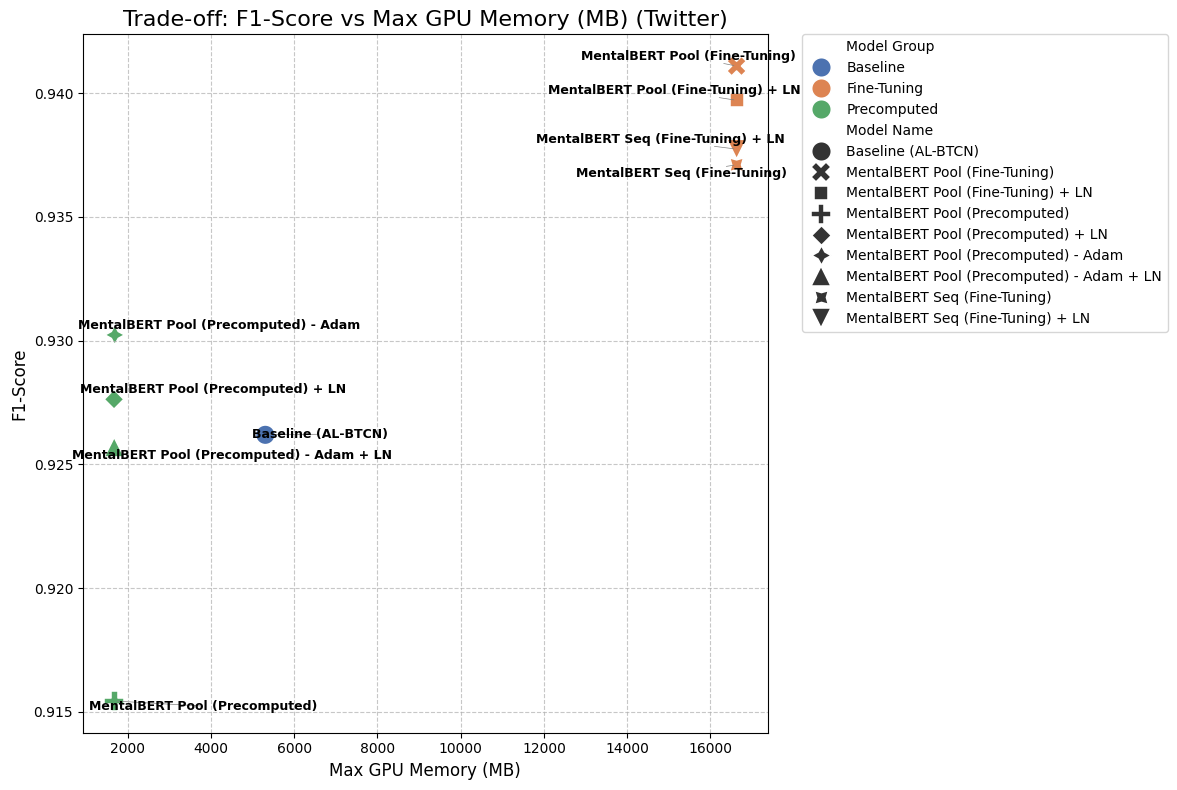

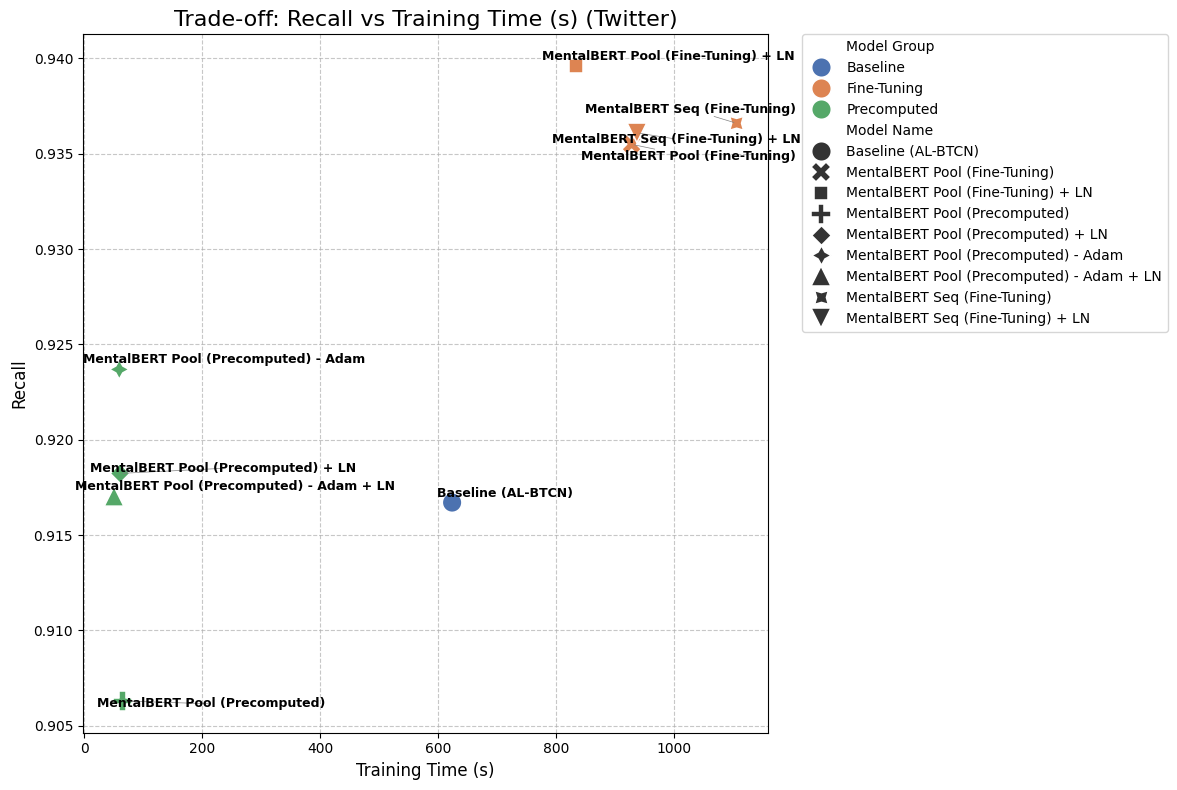

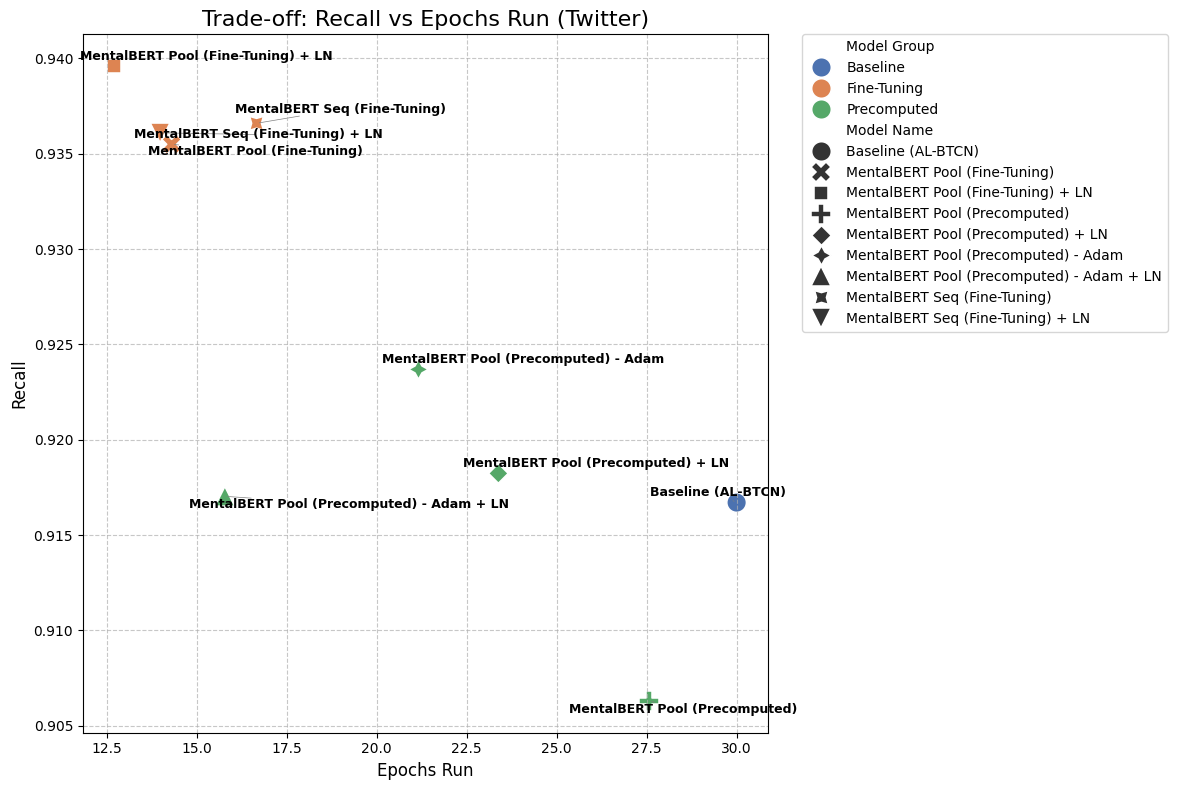

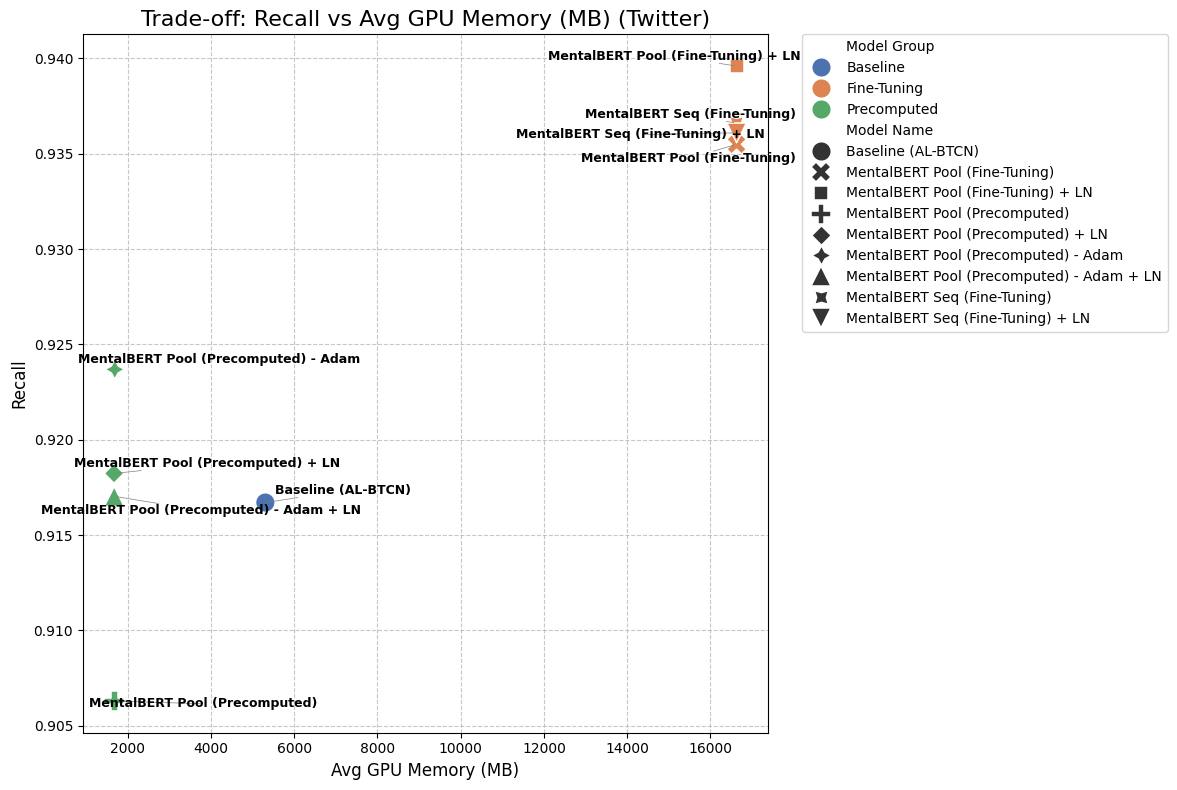

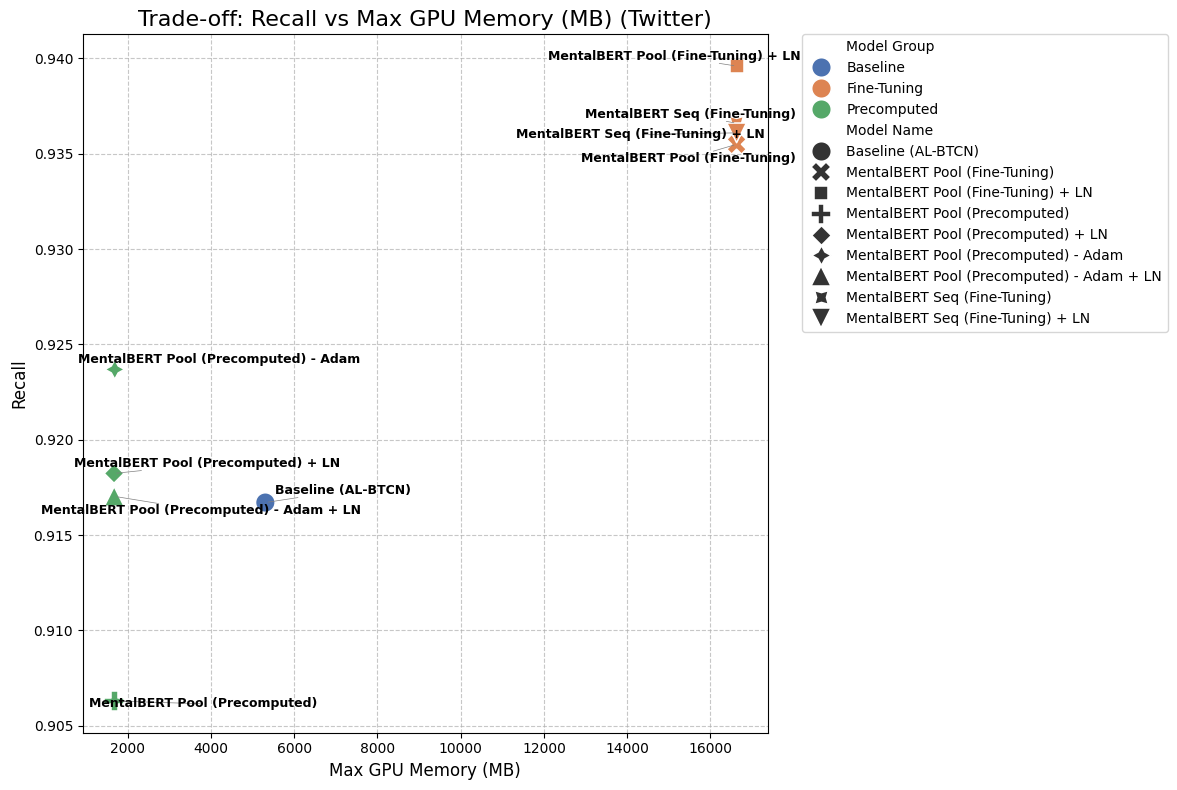

In [7]:
# Performance vs Efficiency Trade-off Analysis

# Define metrics for trade-off analysis
performance_metrics = ['F1-Score', 'Recall']
efficiency_metrics = ['Training Time (s)', 'Epochs Run', 'Avg GPU Memory (MB)', 'Max GPU Memory (MB)']

def plot_tradeoff(df, dataset_name, perf_metric, eff_metric):
    """
    Plots Performance vs Efficiency Trade-off using a scatter plot of means.
    """
    data = df[df['Dataset'] == dataset_name]
    if data.empty: return

    # Calculate means for each model
    summary = data.groupby('Model Name')[[perf_metric, eff_metric]].mean().reset_index()
    
    # Add Model Group info for coloring
    # We take the first occurrence of Model Group for each Model Name
    groups = data.groupby('Model Name')['Model Group'].first().reset_index()
    summary = pd.merge(summary, groups, on='Model Name')

    plt.figure(figsize=(12, 8))
    
    # Create scatter plot
    sns.scatterplot(
        data=summary,
        x=eff_metric,
        y=perf_metric,
        hue='Model Group',
        style='Model Name',
        s=200, # Marker size
        palette='deep'
    )
    
    # Annotate each point with Model Name
    texts = []
    for i, row in summary.iterrows():
        texts.append(plt.text(
            row[eff_metric], 
            row[perf_metric], 
            row['Model Name'], 
            fontsize=9,
            fontweight='bold'
        ))
    
    # Adjust text to avoid overlap
    try:
        from adjustText import adjust_text
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    except ImportError:
        print("Warning: adjustText not installed. Labels may overlap. Run `pip install adjustText`.")

    plt.title(f'Trade-off: {perf_metric} vs {eff_metric} ({dataset_name})', fontsize=16)
    plt.xlabel(eff_metric, fontsize=12)
    plt.ylabel(perf_metric, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.show()

# Generate Trade-off Plots
for dataset in datasets:
    print(f"=== Trade-off Analysis for {dataset} ===")
    for perf in performance_metrics:
        for eff in efficiency_metrics:
            plot_tradeoff(full_df_v2, dataset, perf, eff)

=== Reddit ===

Statistical Analysis: Reddit - Recall
Comparing Experiment: 'MentalBERT Seq (Fine-Tuning) + LN' vs Control: 'MentalBERT Seq (Fine-Tuning)'
Number of Seeds: 10
Mean Difference (Experiment - Control): 0.0063
95% Confidence Interval: (0.0019, 0.0107)
Cohen's d: 1.0341
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=3.2702, p-value=0.0048
Result (T-Test): Reject H0 (Significant Improvement) - greater
Wilcoxon Test: statistic=53.0000, p-value=0.0029
Result (Wilcoxon): Reject H0 (Significant Improvement) - greater
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=3.2702, p-value=0.0097
Result (T-Test Two-Sided): Reject H0 (Significant Difference)
Wilcoxon Test (Two-Sided): statistic=2.0000, p-value=0.0059
Result (Wilcoxon Two-Sided): Reject H0 (Significant Difference)


<Figure size 600x400 with 0 Axes>

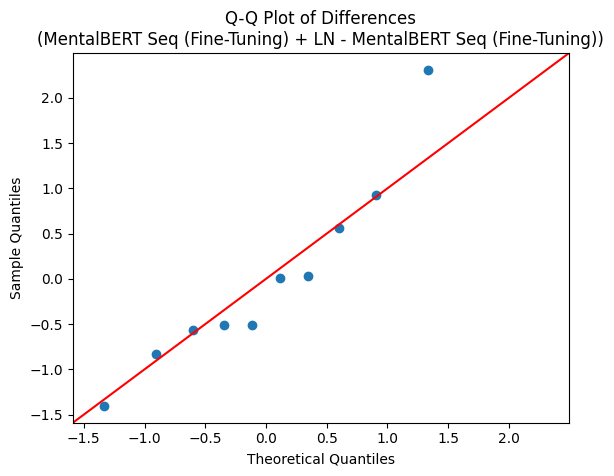


Statistical Analysis: Reddit - F1-Score
Comparing Experiment: 'MentalBERT Seq (Fine-Tuning) + LN' vs Control: 'MentalBERT Seq (Fine-Tuning)'
Number of Seeds: 10
Mean Difference (Experiment - Control): 0.0004
95% Confidence Interval: (-0.0005, 0.0013)
Cohen's d: 0.3232
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=1.0220, p-value=0.1667
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=39.0000, p-value=0.1377
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=1.0220, p-value=0.3335
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=16.0000, p-value=0.2754
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

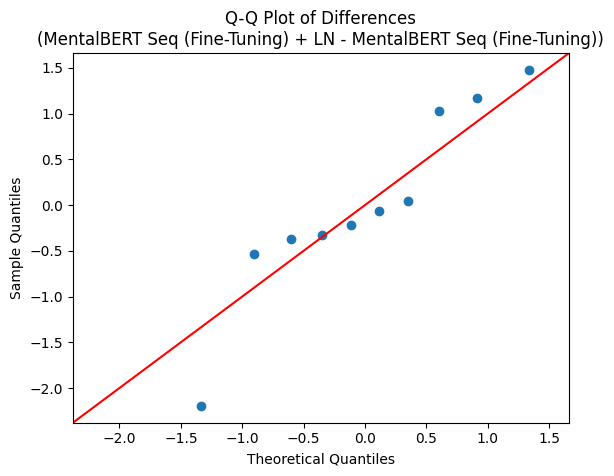


Statistical Analysis: Reddit - Recall
Comparing Experiment: 'MentalBERT Pool (Fine-Tuning) + LN' vs Control: 'MentalBERT Pool (Fine-Tuning)'
Number of Seeds: 10
Mean Difference (Experiment - Control): 0.0071
95% Confidence Interval: (0.0042, 0.0100)
Cohen's d: 1.7453
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=5.5192, p-value=0.0002
Result (T-Test): Reject H0 (Significant Improvement) - greater
Wilcoxon Test: statistic=55.0000, p-value=0.0010
Result (Wilcoxon): Reject H0 (Significant Improvement) - greater
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=5.5192, p-value=0.0004
Result (T-Test Two-Sided): Reject H0 (Significant Difference)
Wilcoxon Test (Two-Sided): statistic=0.0000, p-value=0.0020
Result (Wilcoxon Two-Sided): Reject H0 (Significant Difference)


<Figure size 600x400 with 0 Axes>

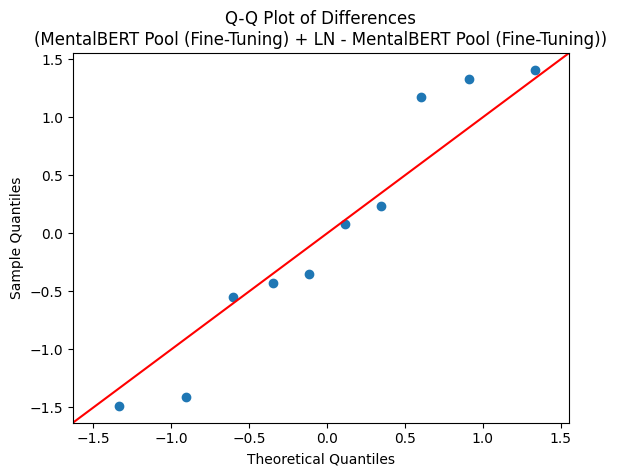


Statistical Analysis: Reddit - F1-Score
Comparing Experiment: 'MentalBERT Pool (Fine-Tuning) + LN' vs Control: 'MentalBERT Pool (Fine-Tuning)'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0013
95% Confidence Interval: (-0.0021, -0.0005)
Cohen's d: -1.1896
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-3.7617, p-value=0.9978
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=2.0000, p-value=0.9980
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-3.7617, p-value=0.0045
Result (T-Test Two-Sided): Reject H0 (Significant Difference)
Wilcoxon Test (Two-Sided): statistic=2.0000, p-value=0.0059
Result (Wilcoxon Two-Sided): Reject H0 (Significant Difference)


<Figure size 600x400 with 0 Axes>

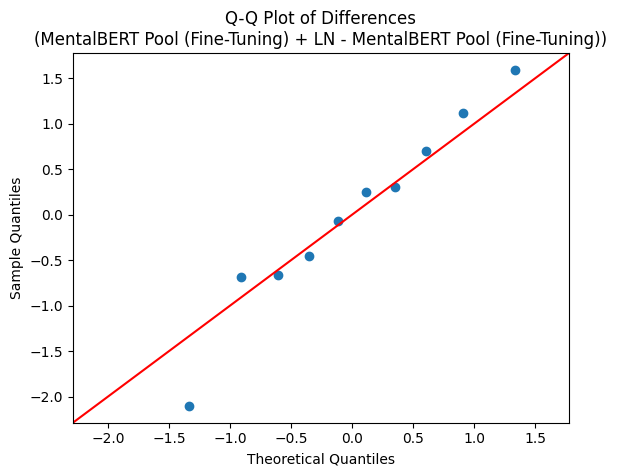


Statistical Analysis: Reddit - Recall
Comparing Experiment: 'MentalBERT Pool (Precomputed) + LN' vs Control: 'MentalBERT Pool (Precomputed) - Adam'
Number of Seeds: 10
Mean Difference (Experiment - Control): 0.0011
95% Confidence Interval: (-0.0038, 0.0061)
Cohen's d: 0.1640
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=0.5186, p-value=0.3083
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=36.0000, p-value=0.2158
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=0.5186, p-value=0.6165
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=19.0000, p-value=0.4316
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

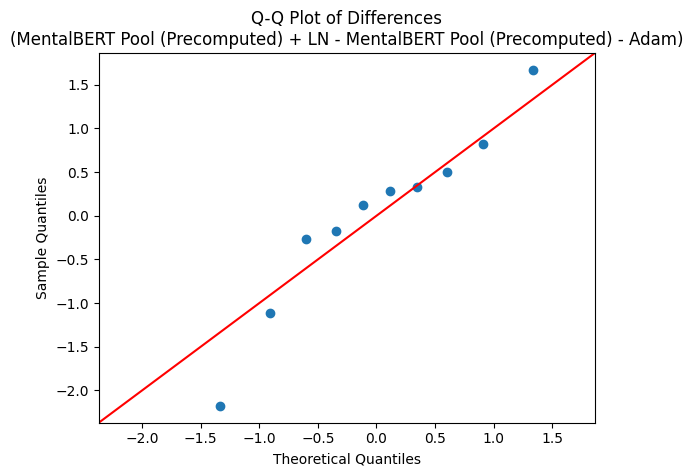


Statistical Analysis: Reddit - F1-Score
Comparing Experiment: 'MentalBERT Pool (Precomputed) + LN' vs Control: 'MentalBERT Pool (Precomputed) - Adam'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0019
95% Confidence Interval: (-0.0025, -0.0012)
Cohen's d: -2.0426
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-6.4594, p-value=0.9999
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=1.0000, p-value=0.9990
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-6.4594, p-value=0.0001
Result (T-Test Two-Sided): Reject H0 (Significant Difference)
Wilcoxon Test (Two-Sided): statistic=1.0000, p-value=0.0039
Result (Wilcoxon Two-Sided): Reject H0 (Significant Difference)


<Figure size 600x400 with 0 Axes>

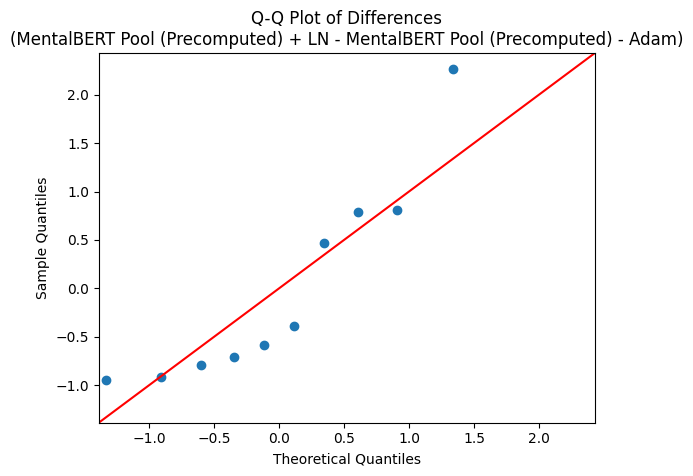


Statistical Analysis: Reddit - Recall
Comparing Experiment: 'MentalBERT Pool (Precomputed) - Adam + LN' vs Control: 'MentalBERT Pool (Precomputed) - Adam'
Number of Seeds: 10
Mean Difference (Experiment - Control): 0.0012
95% Confidence Interval: (-0.0012, 0.0036)
Cohen's d: 0.3666
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=1.1593, p-value=0.1381
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=40.0000, p-value=0.1162
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=1.1593, p-value=0.2761
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=15.0000, p-value=0.2324
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

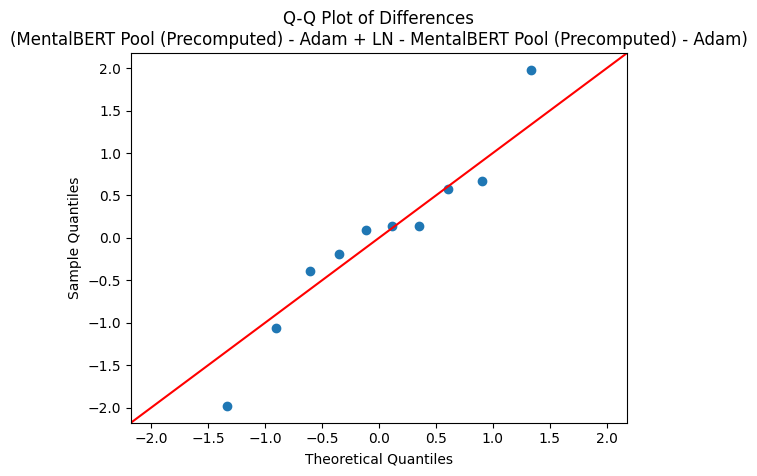


Statistical Analysis: Reddit - F1-Score
Comparing Experiment: 'MentalBERT Pool (Precomputed) - Adam + LN' vs Control: 'MentalBERT Pool (Precomputed) - Adam'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0006
95% Confidence Interval: (-0.0014, 0.0001)
Cohen's d: -0.6355
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-2.0096, p-value=0.9623
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=13.0000, p-value=0.9346
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-2.0096, p-value=0.0754
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=13.0000, p-value=0.1602
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

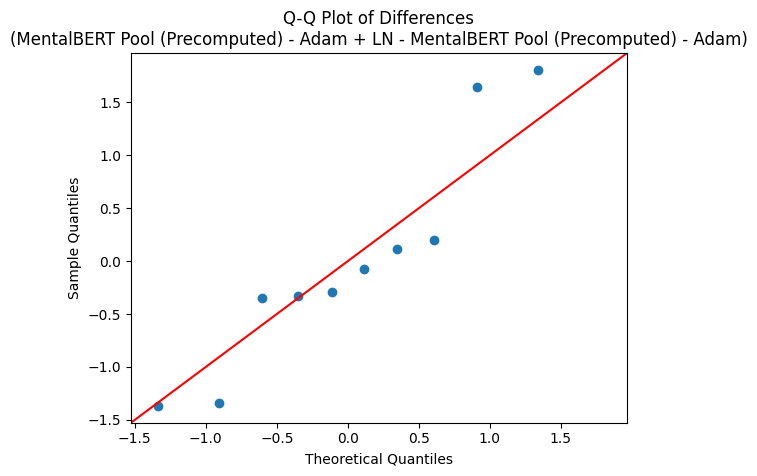

=== Twitter ===

Statistical Analysis: Twitter - Recall
Comparing Experiment: 'MentalBERT Seq (Fine-Tuning) + LN' vs Control: 'MentalBERT Seq (Fine-Tuning)'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0005
95% Confidence Interval: (-0.0047, 0.0037)
Cohen's d: -0.0857
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-0.2709, p-value=0.6037
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=17.0000, p-value=0.8623
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-0.2709, p-value=0.7926
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=17.0000, p-value=0.3223
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

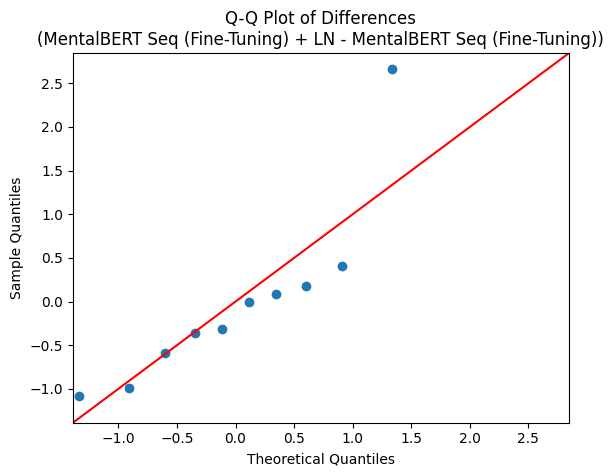


Statistical Analysis: Twitter - F1-Score
Comparing Experiment: 'MentalBERT Seq (Fine-Tuning) + LN' vs Control: 'MentalBERT Seq (Fine-Tuning)'
Number of Seeds: 10
Mean Difference (Experiment - Control): 0.0006
95% Confidence Interval: (-0.0013, 0.0025)
Cohen's d: 0.2400
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=0.7588, p-value=0.2337
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=34.0000, p-value=0.2783
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=0.7588, p-value=0.4674
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=21.0000, p-value=0.5566
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

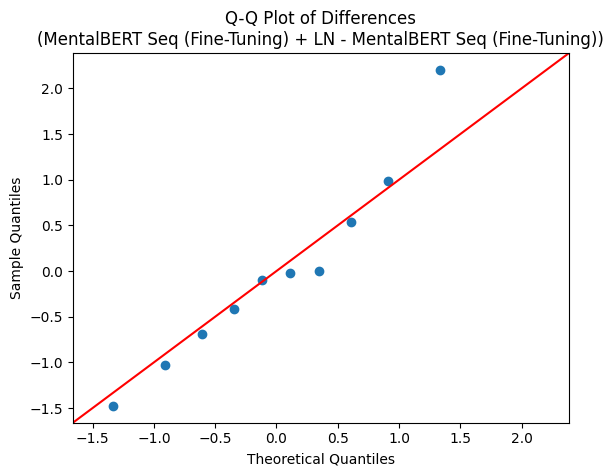


Statistical Analysis: Twitter - Recall
Comparing Experiment: 'MentalBERT Pool (Fine-Tuning) + LN' vs Control: 'MentalBERT Pool (Fine-Tuning)'
Number of Seeds: 10
Mean Difference (Experiment - Control): 0.0041
95% Confidence Interval: (-0.0009, 0.0091)
Cohen's d: 0.5920
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=1.8719, p-value=0.0470
Result (T-Test): Reject H0 (Significant Improvement) - greater
Wilcoxon Test: statistic=45.0000, p-value=0.0420
Result (Wilcoxon): Reject H0 (Significant Improvement) - greater
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=1.8719, p-value=0.0940
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=10.0000, p-value=0.0840
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

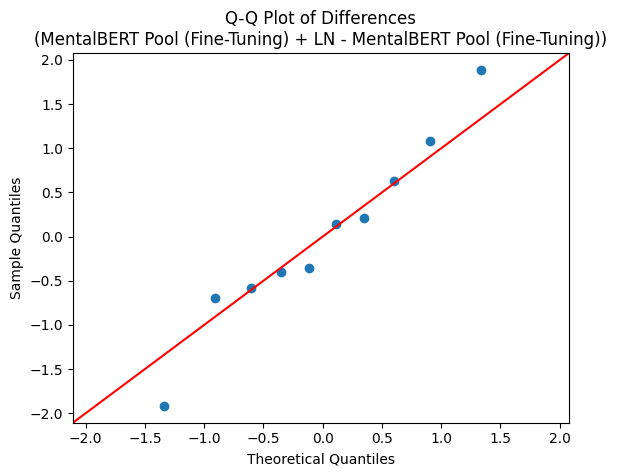


Statistical Analysis: Twitter - F1-Score
Comparing Experiment: 'MentalBERT Pool (Fine-Tuning) + LN' vs Control: 'MentalBERT Pool (Fine-Tuning)'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0014
95% Confidence Interval: (-0.0030, 0.0002)
Cohen's d: -0.6188
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-1.9568, p-value=0.9590
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=10.0000, p-value=0.9678
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-1.9568, p-value=0.0821
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=10.0000, p-value=0.0840
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

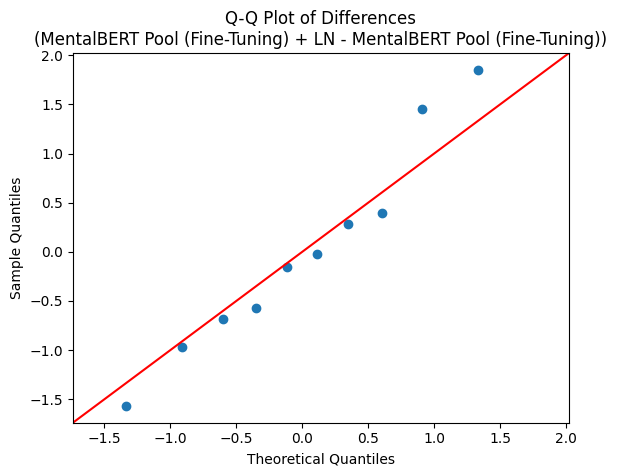


Statistical Analysis: Twitter - Recall
Comparing Experiment: 'MentalBERT Pool (Precomputed) + LN' vs Control: 'MentalBERT Pool (Precomputed) - Adam'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0055
95% Confidence Interval: (-0.0123, 0.0014)
Cohen's d: -0.5706
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-1.8045, p-value=0.9477
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=12.0000, p-value=0.9473
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-1.8045, p-value=0.1046
Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)
Wilcoxon Test (Two-Sided): statistic=12.0000, p-value=0.1309
Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)


<Figure size 600x400 with 0 Axes>

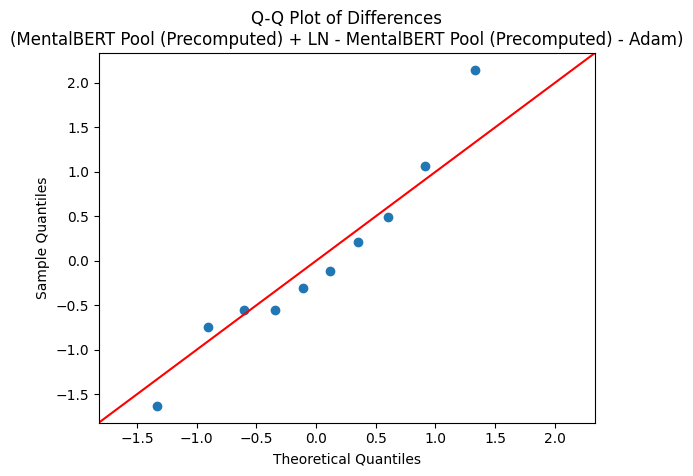


Statistical Analysis: Twitter - F1-Score
Comparing Experiment: 'MentalBERT Pool (Precomputed) + LN' vs Control: 'MentalBERT Pool (Precomputed) - Adam'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0026
95% Confidence Interval: (-0.0049, -0.0003)
Cohen's d: -0.8053
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-2.5465, p-value=0.9843
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=7.0000, p-value=0.9863
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-2.5465, p-value=0.0314
Result (T-Test Two-Sided): Reject H0 (Significant Difference)
Wilcoxon Test (Two-Sided): statistic=7.0000, p-value=0.0371
Result (Wilcoxon Two-Sided): Reject H0 (Significant Difference)


<Figure size 600x400 with 0 Axes>

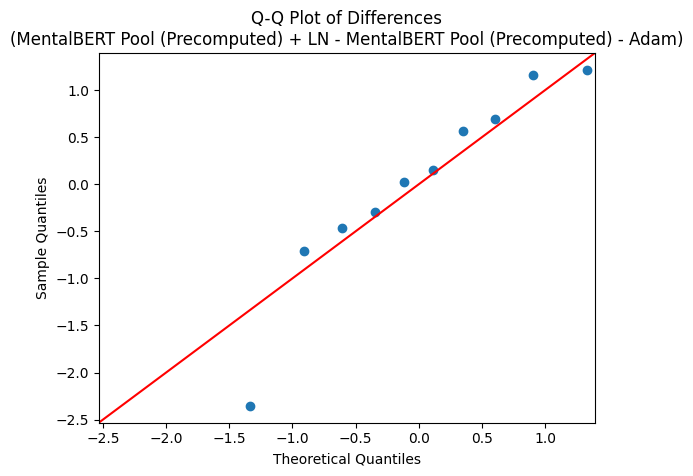


Statistical Analysis: Twitter - Recall
Comparing Experiment: 'MentalBERT Pool (Precomputed) - Adam + LN' vs Control: 'MentalBERT Pool (Precomputed) - Adam'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0067
95% Confidence Interval: (-0.0114, -0.0019)
Cohen's d: -1.0093
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-3.1916, p-value=0.9945
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=5.0000, p-value=0.9932
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-3.1916, p-value=0.0110
Result (T-Test Two-Sided): Reject H0 (Significant Difference)
Wilcoxon Test (Two-Sided): statistic=5.0000, p-value=0.0195
Result (Wilcoxon Two-Sided): Reject H0 (Significant Difference)


<Figure size 600x400 with 0 Axes>

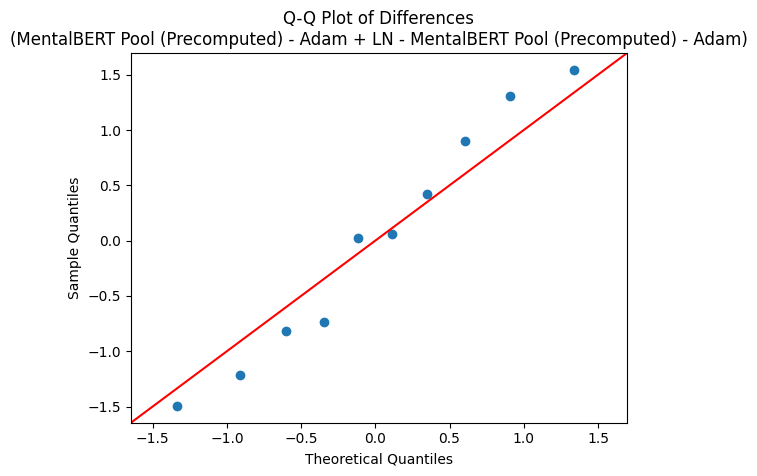


Statistical Analysis: Twitter - F1-Score
Comparing Experiment: 'MentalBERT Pool (Precomputed) - Adam + LN' vs Control: 'MentalBERT Pool (Precomputed) - Adam'
Number of Seeds: 10
Mean Difference (Experiment - Control): -0.0045
95% Confidence Interval: (-0.0058, -0.0033)
Cohen's d: -2.5611
Alternative Hypothesis: Experiment greater than Control
Paired T-Test: t-statistic=-8.0990, p-value=1.0000
Result (T-Test): Fail to reject H0
Wilcoxon Test: statistic=0.0000, p-value=1.0000
Result (Wilcoxon): Fail to reject H0
--------------------
Alternative Hypothesis: Experiment != Control (Two-Sided)
Paired T-Test (Two-Sided): t-statistic=-8.0990, p-value=0.0000
Result (T-Test Two-Sided): Reject H0 (Significant Difference)
Wilcoxon Test (Two-Sided): statistic=0.0000, p-value=0.0020
Result (Wilcoxon Two-Sided): Reject H0 (Significant Difference)


<Figure size 600x400 with 0 Axes>

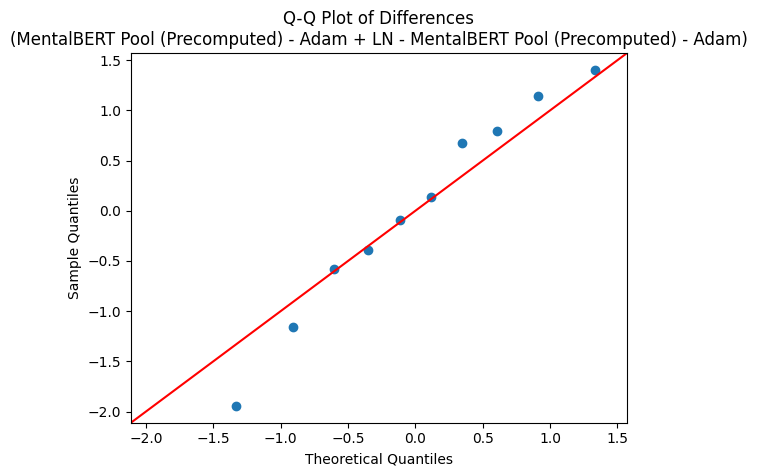

Results saved to c:\Files\Degree\FYP\FYP_ver5\Results\10seeds_cv5_runs\2_Test_Add_LayerNorm\statistical_analysis_results_ln.xlsx
  Dataset    Metric                    Experiment Model  \
0  Reddit    Recall   MentalBERT Seq (Fine-Tuning) + LN   
1  Reddit  F1-Score   MentalBERT Seq (Fine-Tuning) + LN   
2  Reddit    Recall  MentalBERT Pool (Fine-Tuning) + LN   
3  Reddit  F1-Score  MentalBERT Pool (Fine-Tuning) + LN   
4  Reddit    Recall  MentalBERT Pool (Precomputed) + LN   

                          Control Model  Num Seeds  Mean Difference  \
0          MentalBERT Seq (Fine-Tuning)         10         0.006309   
1          MentalBERT Seq (Fine-Tuning)         10         0.000406   
2         MentalBERT Pool (Fine-Tuning)         10         0.007112   
3         MentalBERT Pool (Fine-Tuning)         10        -0.001341   
4  MentalBERT Pool (Precomputed) - Adam         10         0.001136   

   T-Test (1-sided) p-val              T-Test (1-sided) Result  \
0                0.0048

In [8]:
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import os

def perform_detailed_statistical_analysis(df, dataset_name, metric, model_experiment, model_control, results_list=None):
    print(f"\n{'='*20}\nStatistical Analysis: {dataset_name} - {metric}\n{'='*20}")
    print(f"Comparing Experiment: '{model_experiment}' vs Control: '{model_control}'")
    
    # Filter data
    data = df[df['Dataset'] == dataset_name]
    if data.empty:
        print(f"No data for {dataset_name}")
        return

    # 1. Average for each seed first
    # Group by Model and Seed to get the mean of the metric for that seed (across folds)
    seed_avg = data.groupby(['Model Name', 'Seed'])[metric].mean().reset_index()
    
    # Pivot to get models as columns, seeds as index
    pivot_df = seed_avg.pivot(index='Seed', columns='Model Name', values=metric)
    
    if model_experiment not in pivot_df.columns or model_control not in pivot_df.columns:
        print(f"One or both models not found in data: {model_experiment}, {model_control}")
        return
    
    # Ensure we have paired data (same seeds)
    # Drop NA if any seed is missing for one of the pair
    pair_df = pd.concat([pivot_df[model_control], pivot_df[model_experiment]], axis=1).dropna()
    if len(pair_df) < 2:
        print(f"Not enough data points for comparison.")
        return
        
    diff = pair_df[model_experiment] - pair_df[model_control]
    n = len(diff)
    mean_diff = diff.mean()
    std_diff = diff.std(ddof=1)
    
    print(f"Number of Seeds: {n}")
    print(f"Mean Difference (Experiment - Control): {mean_diff:.4f}")
    
    alpha = 0.05
    
    # Confidence Interval (95%)
    se = std_diff / np.sqrt(n)
    ci = stats.t.interval(1 - alpha, df=n-1, loc=mean_diff, scale=se)
    print(f"95% Confidence Interval: ({ci[0]:.4f}, {ci[1]:.4f})")
    
    # Cohen's d (for paired samples)
    if std_diff != 0:
        cohens_d = mean_diff / std_diff
    else:
        cohens_d = 0
    print(f"Cohen's d: {cohens_d:.4f}")
    
    # Determine direction
    higher_is_better = 'Time' not in metric and 'Memory' not in metric and 'Epochs' not in metric
    alt_hyp = 'greater' if higher_is_better else 'less'
    
    # --- One-Sided Test (Improvement) ---
    print(f"Alternative Hypothesis: Experiment {alt_hyp} than Control")

    # Paired T-Test
    t_stat, p_val_t = stats.ttest_rel(pair_df[model_experiment], pair_df[model_control], alternative=alt_hyp)
    print(f"Paired T-Test: t-statistic={t_stat:.4f}, p-value={p_val_t:.4f}")
    
    t_test_result = "Reject H0 (Significant Improvement)" if p_val_t < alpha else "Fail to reject H0"
    if p_val_t < alpha:
        print(f"Result (T-Test): {t_test_result} - {alt_hyp}")
    else:
        print(f"Result (T-Test): {t_test_result}")
    
    # Wilcoxon Signed-Rank Test
    w_stat, p_val_w = np.nan, np.nan
    wilcoxon_result = "N/A"
    try:
        w_stat, p_val_w = stats.wilcoxon(pair_df[model_experiment], pair_df[model_control], alternative=alt_hyp)
        print(f"Wilcoxon Test: statistic={w_stat:.4f}, p-value={p_val_w:.4f}")
        wilcoxon_result = "Reject H0 (Significant Improvement)" if p_val_w < alpha else "Fail to reject H0"
        if p_val_w < alpha:
            print(f"Result (Wilcoxon): {wilcoxon_result} - {alt_hyp}")
        else:
            print(f"Result (Wilcoxon): {wilcoxon_result}")
    except Exception as e:
        print(f"Wilcoxon Test Failed: {e}")

    # --- Two-Sided Test (Any Difference) ---
    print("-" * 20)
    print(f"Alternative Hypothesis: Experiment != Control (Two-Sided)")

    # Paired T-Test (Two-Sided)
    t_stat_2, p_val_t_2 = stats.ttest_rel(pair_df[model_experiment], pair_df[model_control], alternative='two-sided')
    print(f"Paired T-Test (Two-Sided): t-statistic={t_stat_2:.4f}, p-value={p_val_t_2:.4f}")
    
    t_test_result_2 = "Reject H0" if p_val_t_2 < alpha else "Fail to reject H0"
    if p_val_t_2 < alpha:
        print("Result (T-Test Two-Sided): Reject H0 (Significant Difference)")
    else:
        print("Result (T-Test Two-Sided): Fail to reject H0 (No Significant Difference)")

    # Wilcoxon Signed-Rank Test (Two-Sided)
    w_stat_2, p_val_w_2 = np.nan, np.nan
    wilcoxon_result_2 = "N/A"
    try:
        w_stat_2, p_val_w_2 = stats.wilcoxon(pair_df[model_experiment], pair_df[model_control], alternative='two-sided')
        print(f"Wilcoxon Test (Two-Sided): statistic={w_stat_2:.4f}, p-value={p_val_w_2:.4f}")
        wilcoxon_result_2 = "Reject H0" if p_val_w_2 < alpha else "Fail to reject H0"
        if p_val_w_2 < alpha:
            print("Result (Wilcoxon Two-Sided): Reject H0 (Significant Difference)")
        else:
            print("Result (Wilcoxon Two-Sided): Fail to reject H0 (No Significant Difference)")
    except Exception as e:
        print(f"Wilcoxon Test (Two-Sided) Failed: {e}")

    # Q-Q Plot
    plt.figure(figsize=(6, 4))
    sm.qqplot(diff, line='45', fit=True)
    plt.title(f'Q-Q Plot of Differences\n({model_experiment} - {model_control})')
    plt.show()

    if results_list is not None:
        results_list.append({
            'Dataset': dataset_name,
            'Metric': metric,
            'Experiment Model': model_experiment,
            'Control Model': model_control,
            'Num Seeds': n,
            'Mean Difference': mean_diff,
            'T-Test (1-sided) p-val': p_val_t,
            'T-Test (1-sided) Result': t_test_result,
            'Wilcoxon (1-sided) p-val': p_val_w,
            'Wilcoxon (1-sided) Result': wilcoxon_result,
            'T-Test (2-sided) p-val': p_val_t_2,
            'T-Test (2-sided) Result': t_test_result_2,
            'Wilcoxon (2-sided) p-val': p_val_w_2,
            'Wilcoxon (2-sided) Result': wilcoxon_result_2,
            'CI Lower': ci[0],
            'CI Upper': ci[1],
            'Cohens d': cohens_d
        })

# Define Pairs (Experiment, Control)
# We hypothesize Experiment > Control (for metrics like F1, Recall)
pairs_to_test = [
    ('MentalBERT Seq (Fine-Tuning) + LN', 'MentalBERT Seq (Fine-Tuning)'),
    ('MentalBERT Pool (Fine-Tuning) + LN', 'MentalBERT Pool (Fine-Tuning)'),
    ('MentalBERT Pool (Precomputed) + LN', 'MentalBERT Pool (Precomputed) - Adam'),
    ('MentalBERT Pool (Precomputed) - Adam + LN', 'MentalBERT Pool (Precomputed) - Adam')
]

metrics_for_test = ['Recall','F1-Score']
all_stats_results = []

for dataset in datasets:
    print(f"=== {dataset} ===")
    for model_exp, model_ctrl in pairs_to_test:
        for metric in metrics_for_test:
            perform_detailed_statistical_analysis(full_df_v2, dataset, metric, model_exp, model_ctrl, all_stats_results)

# Save to Excel
if all_stats_results:
    results_df = pd.DataFrame(all_stats_results)
    # path_ln is defined in the first cell of the notebook
    output_file = os.path.join(path_ln, 'statistical_analysis_results_ln.xlsx')
    results_df.to_excel(output_file, index=False)
    print(f"Results saved to {output_file}")
    print(results_df.head())